### Patients sub-group detection by PILOT



<div class="alert alert-block alert-info">
<b>PILOT</b>

In this tutorial, we are using single-cell data from pancreatic ductal adenocarcinomas to find sub-groups of patients using clustering of W distances. And then we rank the cells/genes based on clustering results.

* You can download the Anndata (h5ad) file for this tutorial from [here](https://costalab.ukaachen.de/open_data/PILOT/PDAC.h5ad) and place it in the _Datasets_ folder.

</div>

In [28]:
import pilotpy as pl
import scanpy as sc
import os
import pandas as pd
import numpy as np

##### Reading Anndata

In [29]:
# dict for samples for easier use
samples = {
    'pdac_peng_raw': {
        'f': 'Peng_PDAC_processed_raw.h5ad',    # filename
        'sample_col': 'accSample',              # column with sample name 
        'emb_matrix': 'X_pca',                  # column for embeddings
        'status': 'accLabel',                   # control vs dieseased
        'clusters_col': 'accAnnot'              # cell types
    },
    'pdac_peng_processed': {
        'f': 'Peng_PDAC_processed.h5ad',        # filename
        'sample_col': 'accSample',              # column with sample name 
        'emb_matrix': 'X_pca',                  # column for embeddings
        'status': 'accLabel',                   # control vs dieseased
        'clusters_col': 'accAnnot'              # cell types
    },
    'pdac': {
        'f': 'PDAC.h5ad',                       # filename
        'sample_col': 'sampleID',               # column with sample name 
        'emb_matrix': 'X_pca',                  # column for embeddings
        'status': 'status',                     # control vs dieseased
        'clusters_col': 'cell_types'             # cell types
    },
    'myocard': {
        'f': 'myocardial_infarction.h5ad',      # filename
        'sample_col': 'sampleID',               # column with sample name 
        'emb_matrix': 'PCA',                    # column for embeddings
        'status': 'Status',                     # control vs dieseased
        'clusters_col': 'cell_subtype'          # cell types
    },
}

In [30]:
# set sample name
sample = 'pdac_peng_raw'
sample_info = samples[sample]

In [31]:
adata = sc.read_h5ad(f"Datasets/{samples[sample]['f']}")

##### Loading the required information and computing the Wasserstein distance:
<div class="alert alert-block alert-info"> In order to work with PILOT, ensure that your Anndata object is loaded and contains the required information.
    
Use the following parameters to configure PILOT for your analysis (Setting Parameters):
    
- adata: Pass your loaded Anndata object to PILOT.
    
- emb_matrix: Provide the name of the variable in the obsm level that holds the dimension reduction (PCA representation).
    
- clusters_col: Specify the name of the column in the observation level of your Anndata that corresponds to cell types or clusters.
    
- sample_col: Indicate the column name in the observation level of your Anndata that contains information about samples or patients.
    
- status: Provide the column name that represents the status or disease (e.g., "control" or "case").
       
</div>

In [32]:
pl.tl.wasserstein_distance(
    adata,
    emb_matrix=sample_info['emb_matrix'],
    clusters_col=sample_info['clusters_col'],
    sample_col=sample_info['sample_col'],
    status=sample_info['status']
    )

##### Ploting the Cost matrix and the Wasserstein distance:
<div class="alert alert-block alert-info"> 
 Here we show the heatmaps of the Cost matrix (cells) and Wasserstein distance (samples). At this point, you should have a 'Results_PILOT' folder inside the folder where you are running your analysis, which includes all the plots created by PILOT.
</div>

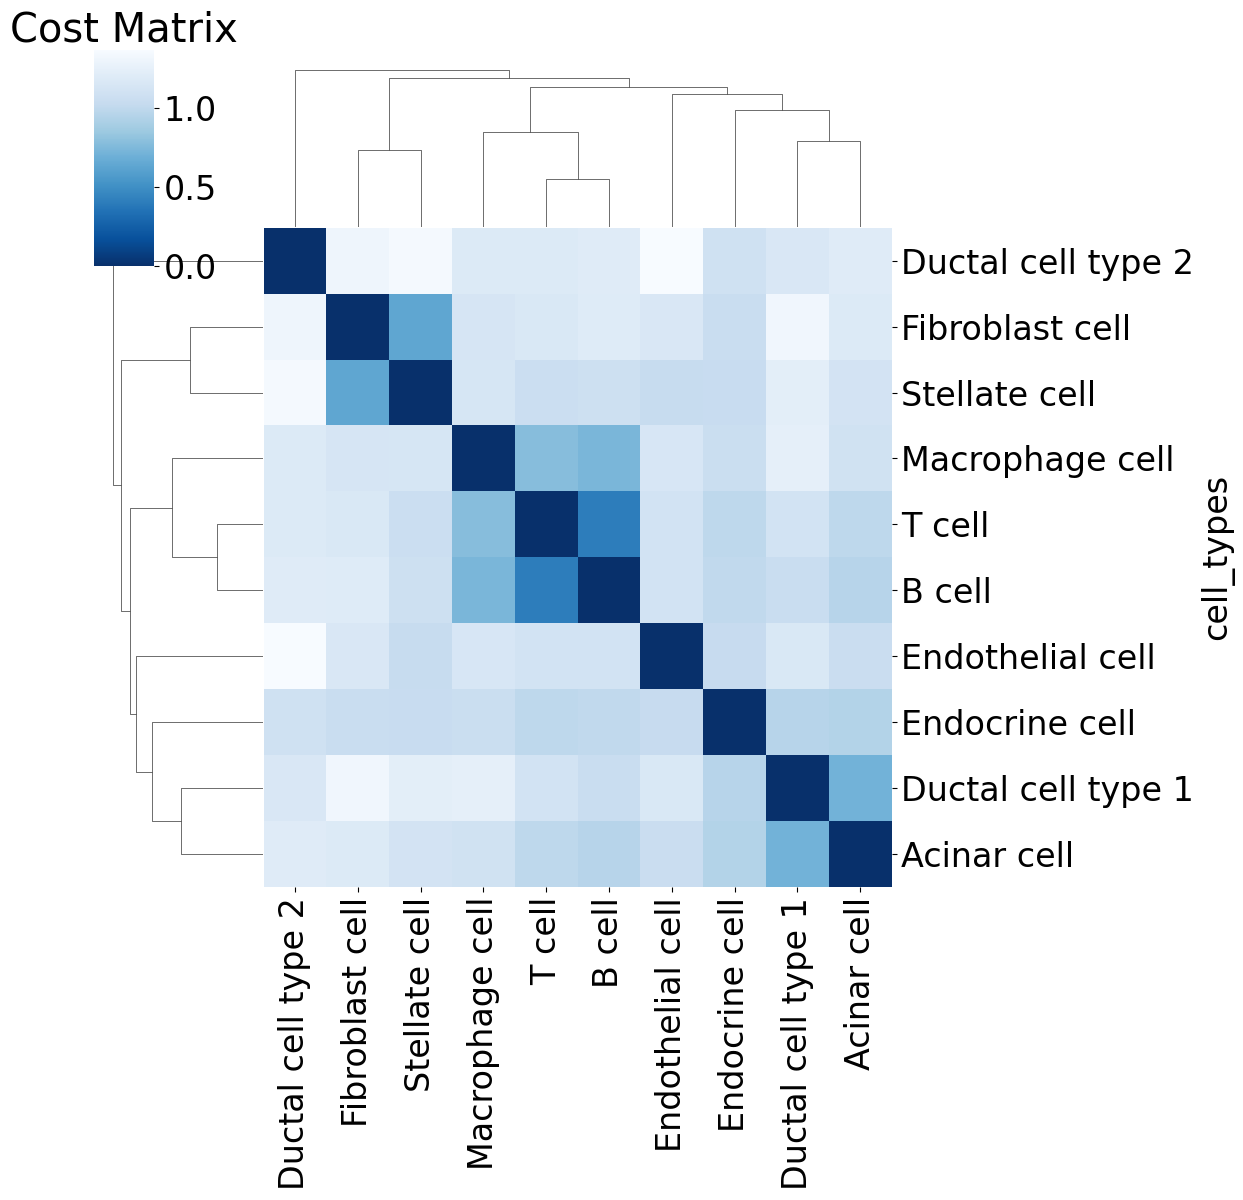

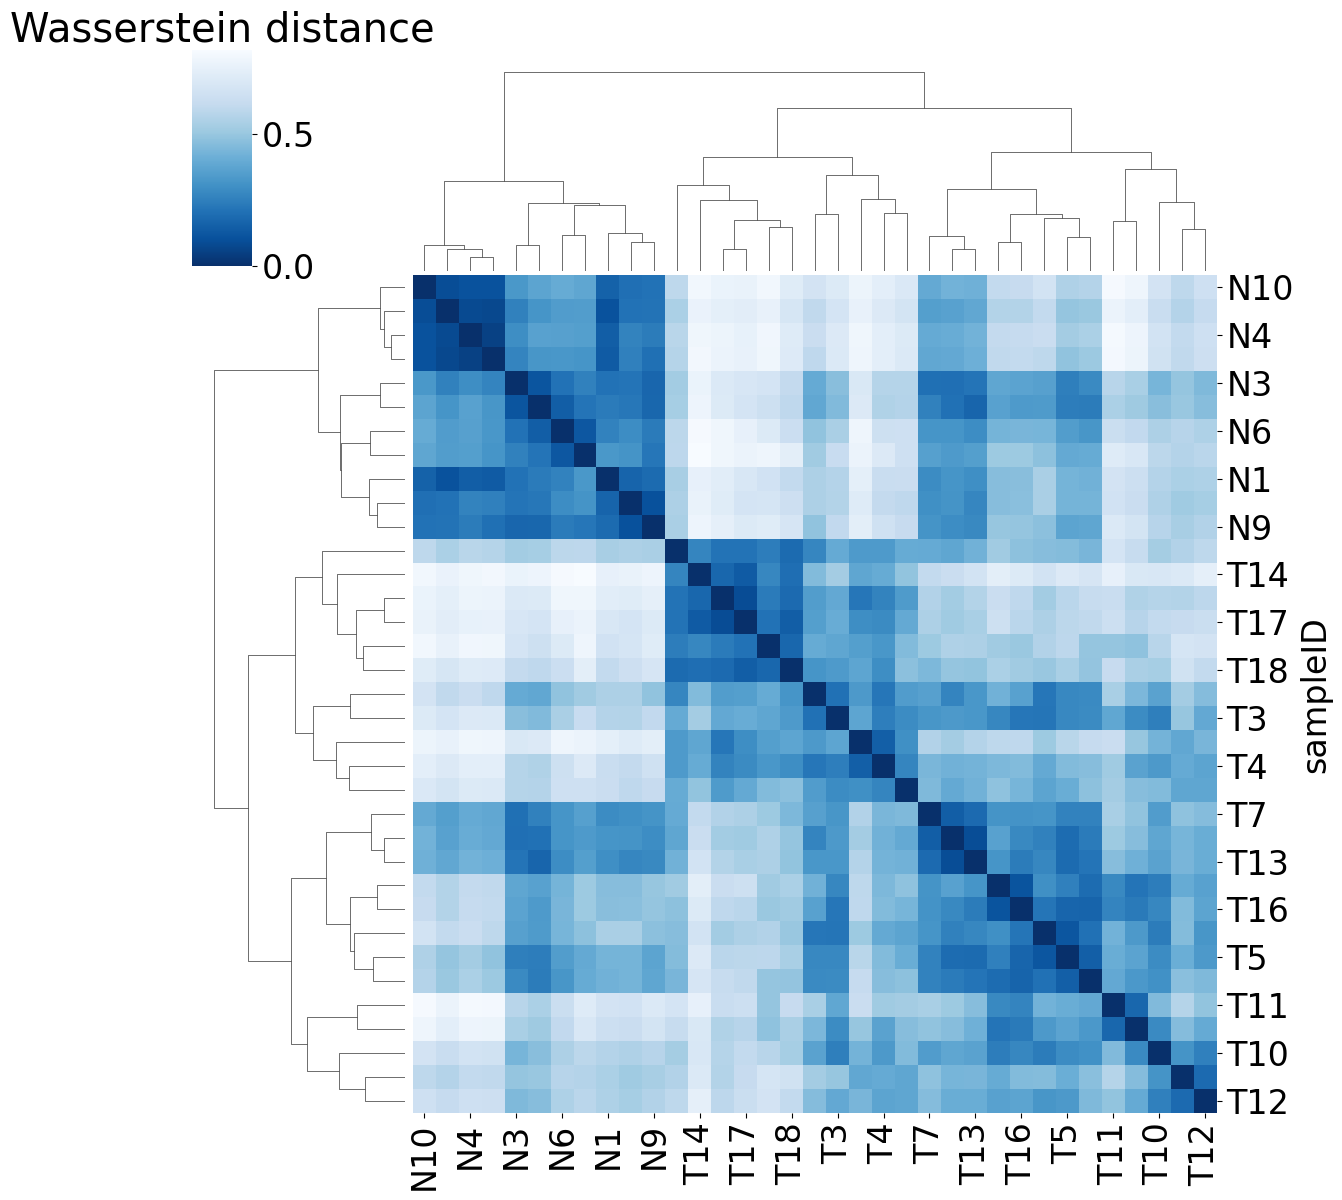

In [33]:
pl.pl.heatmaps(adata)

##### Trajectory:
<div class="alert alert-block alert-info"> 
 Here we show the Diffusion map of Wasserstein distance. In the upcoming trajectory analysis, the labels "T" stands for Tumor and "N" stands for the Normal.
</div>

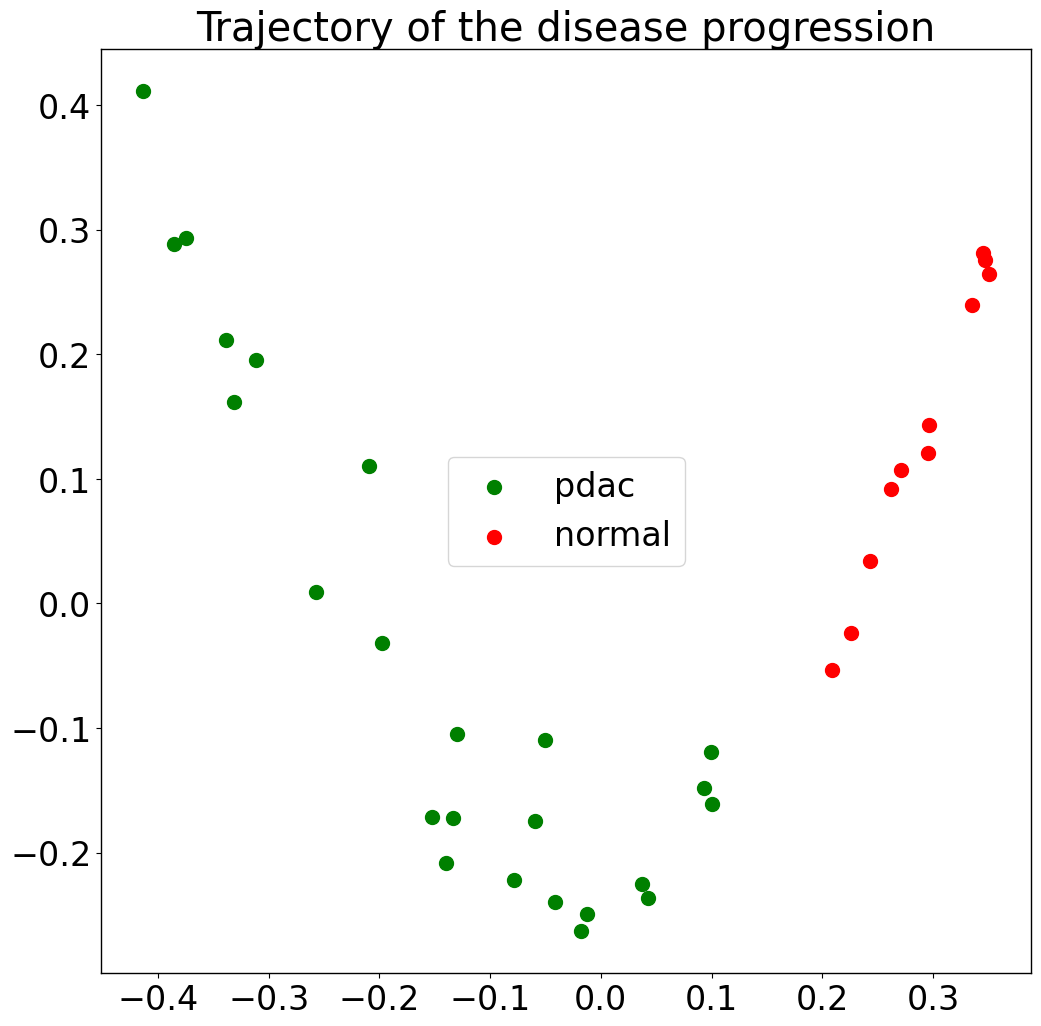

In [34]:
pl.pl.trajectory(adata, colors = ['green','red'])

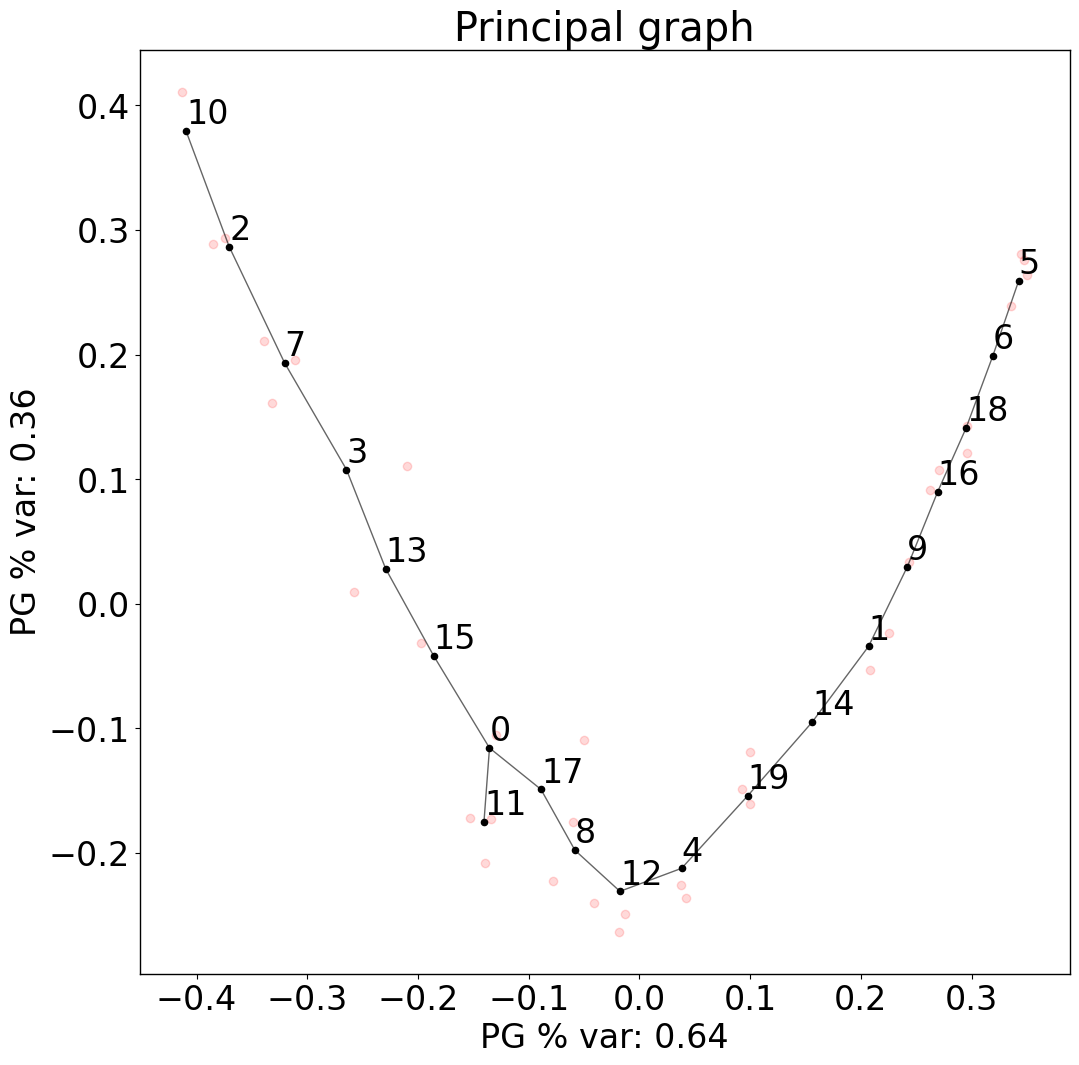

In [35]:
pl.pl.fit_pricipla_graph(adata, source_node = 7)

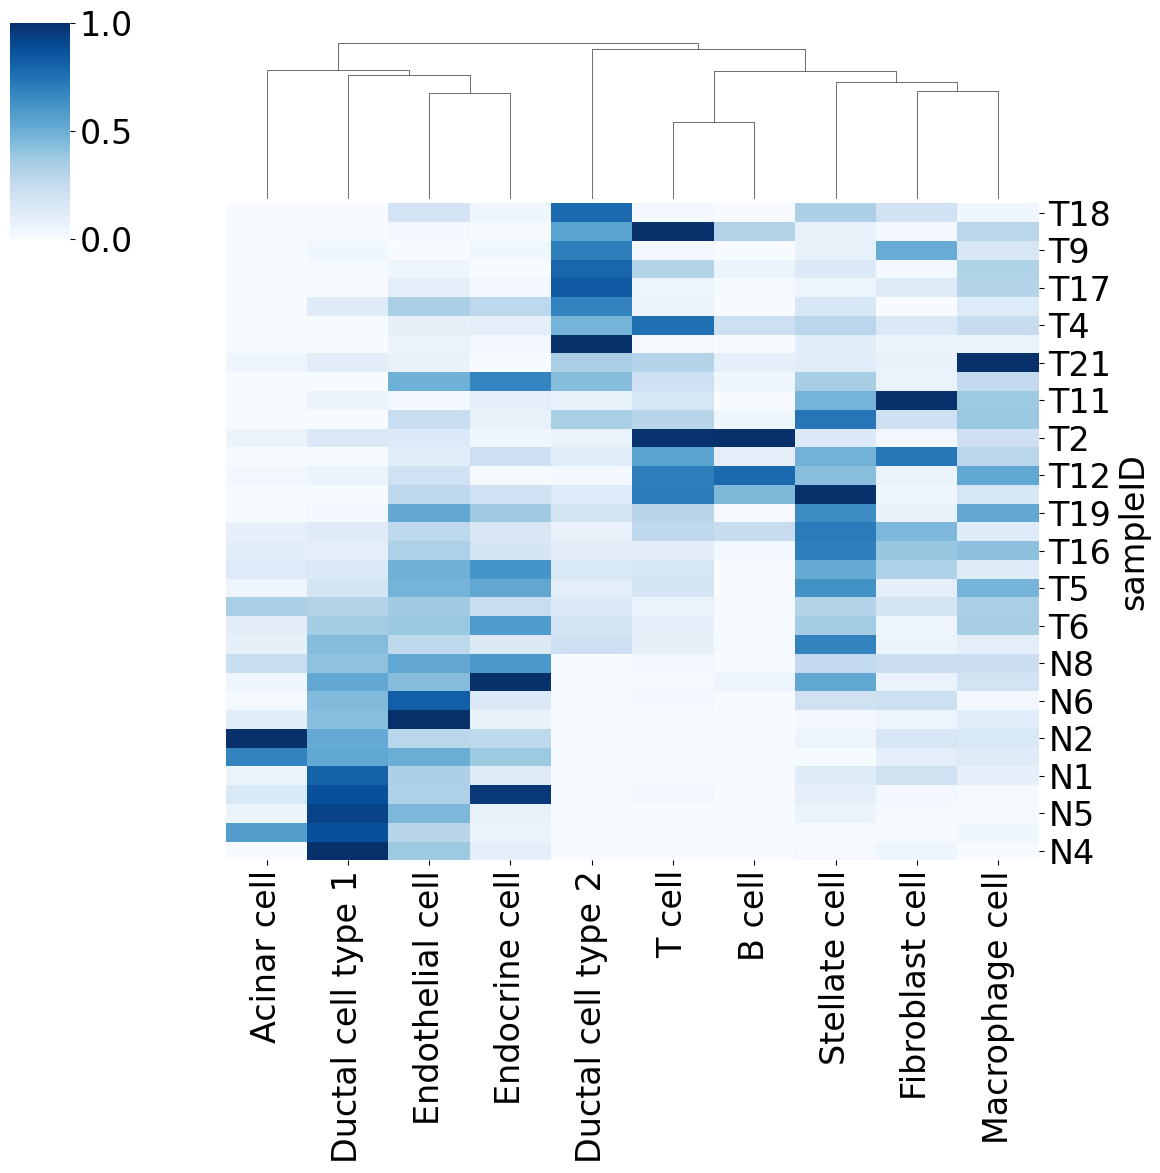

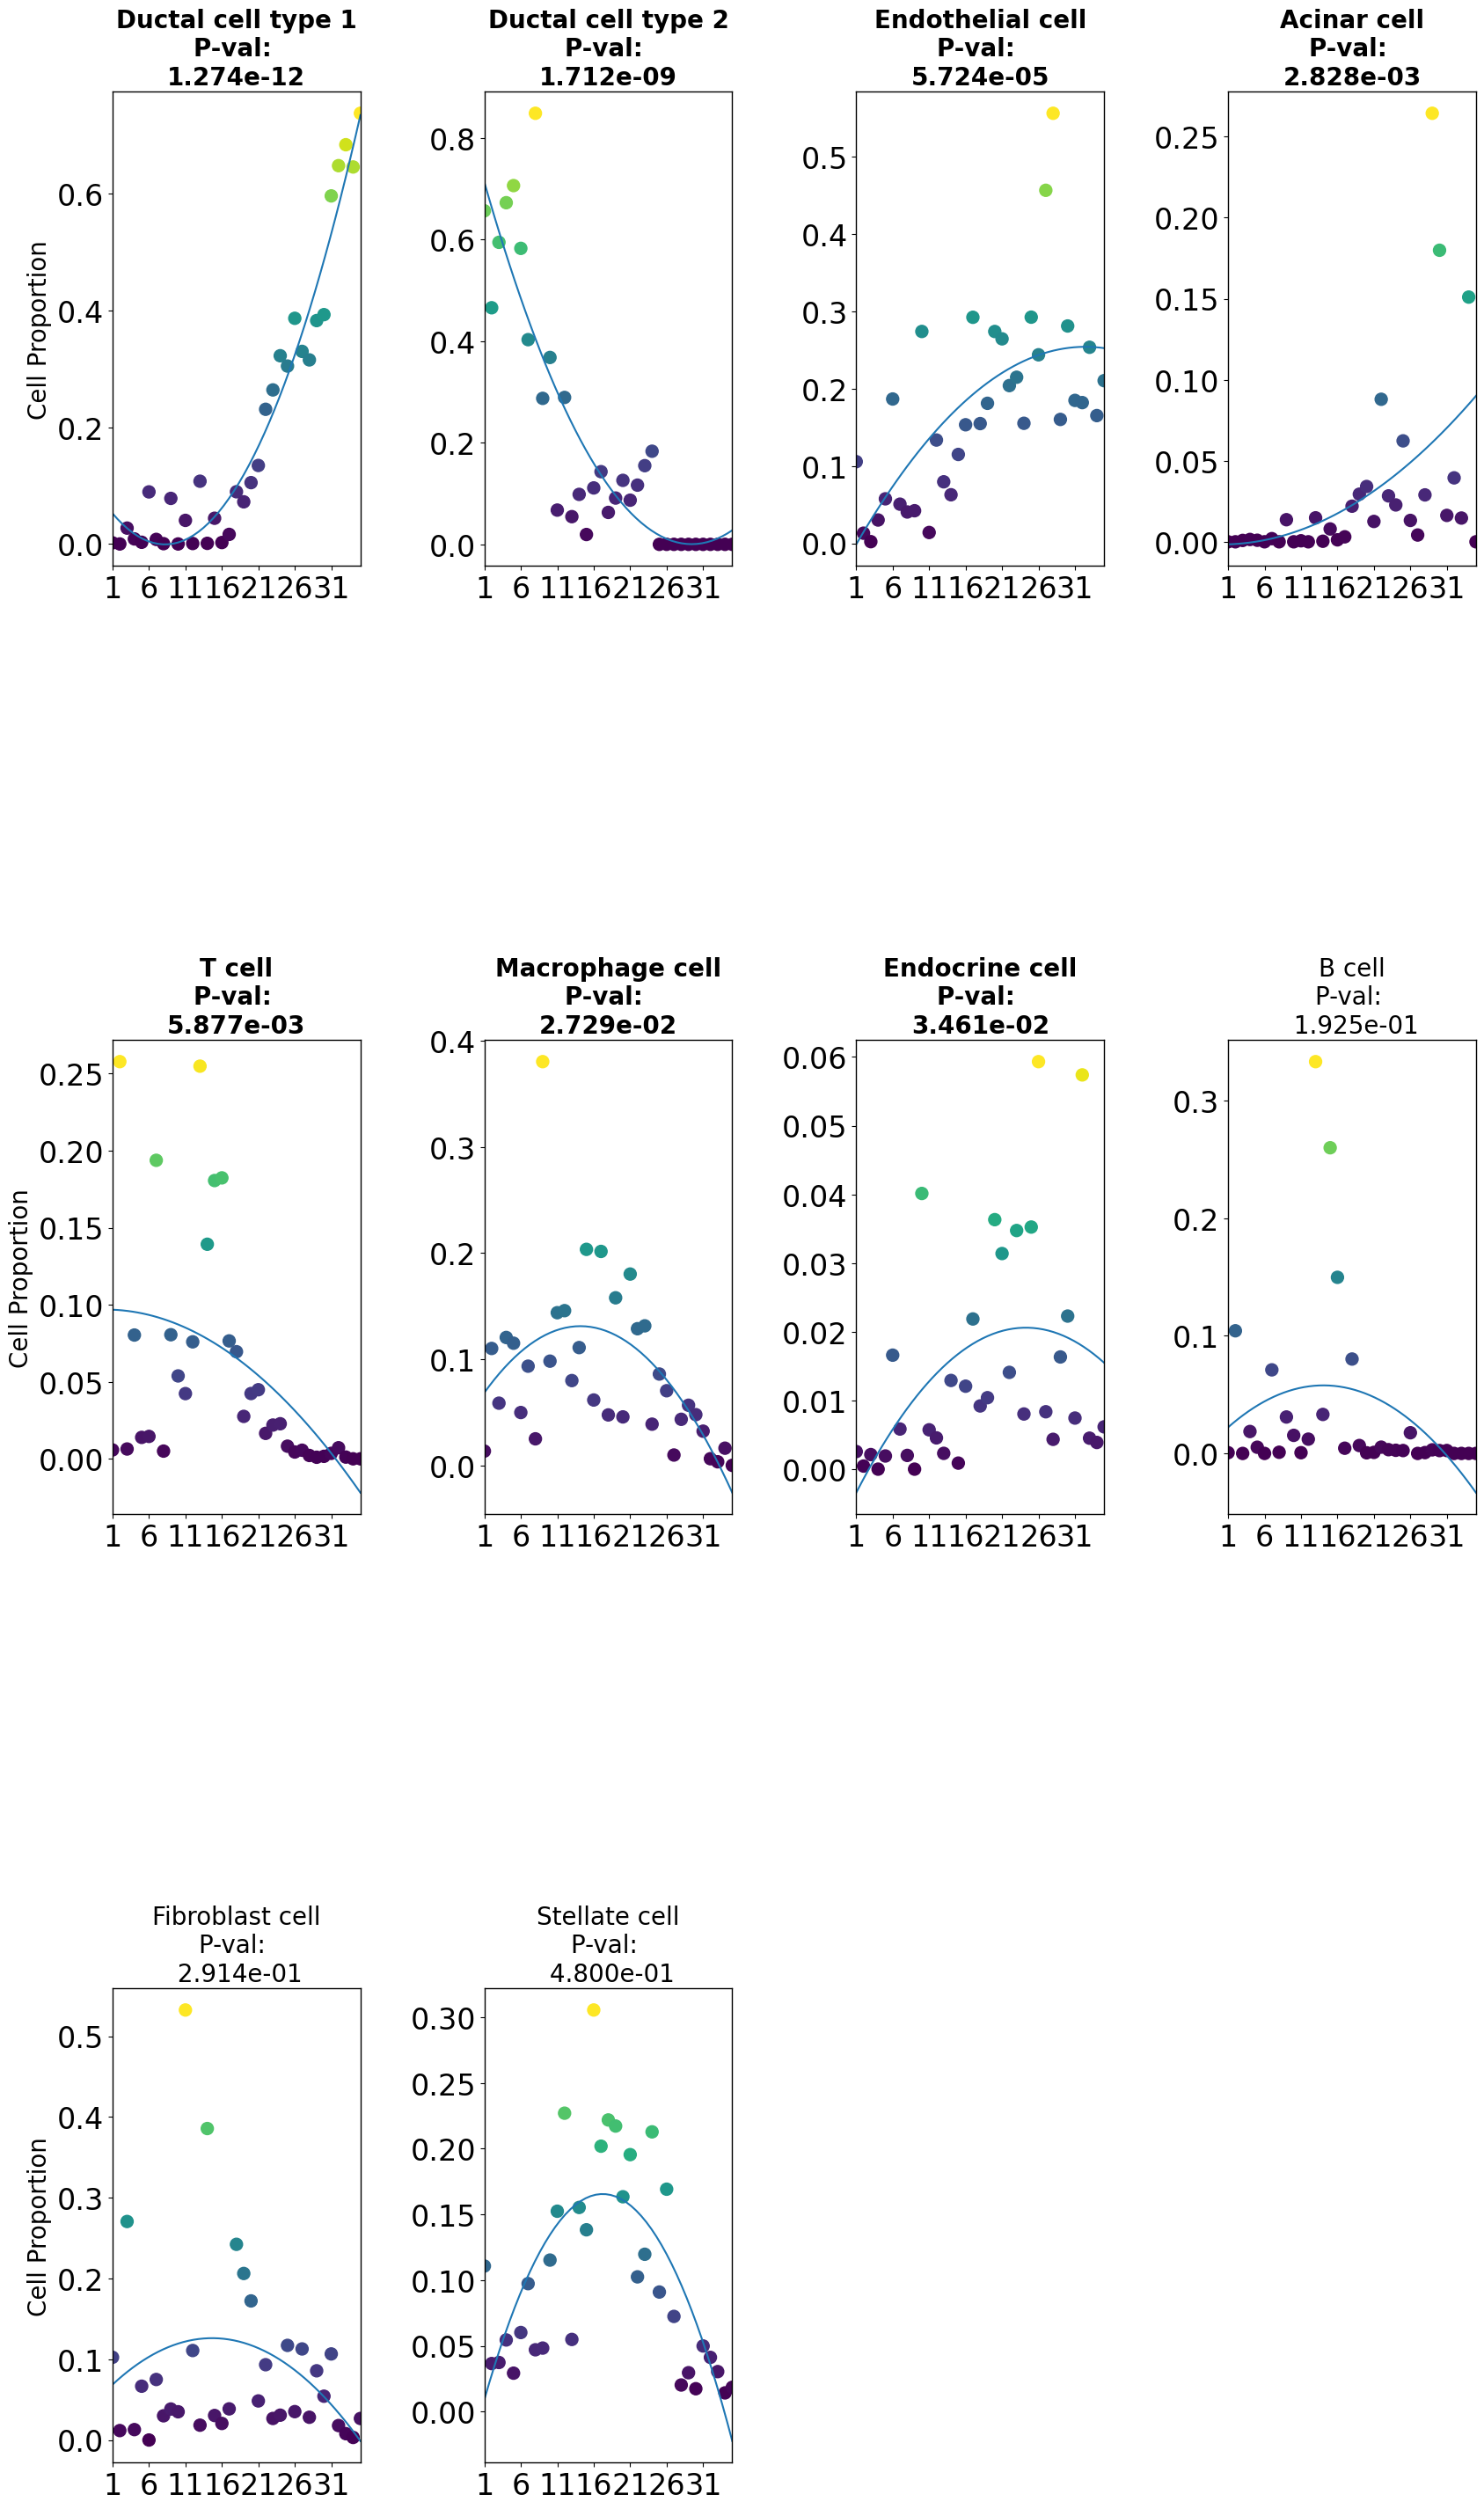

In [36]:
pl.tl.cell_importance(adata)

##### In this section, we should find the optimal number of clusters. 
<div class="alert alert-block alert-info"> 
The Silhouette Score Curve is used to find the optimal number of clusters by plotting the average Silhouette Score for different numbers of clusters. The number of clusters corresponding to the highest average Silhouette Score is considered the optimal number of clusters.
</div>


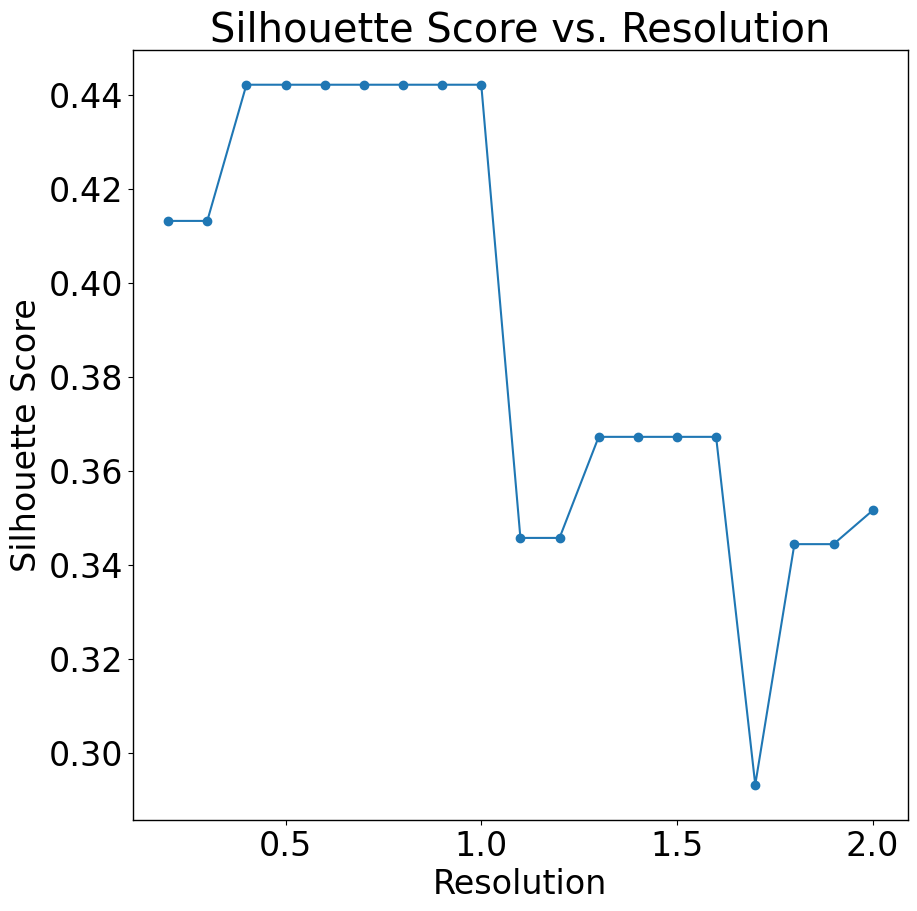

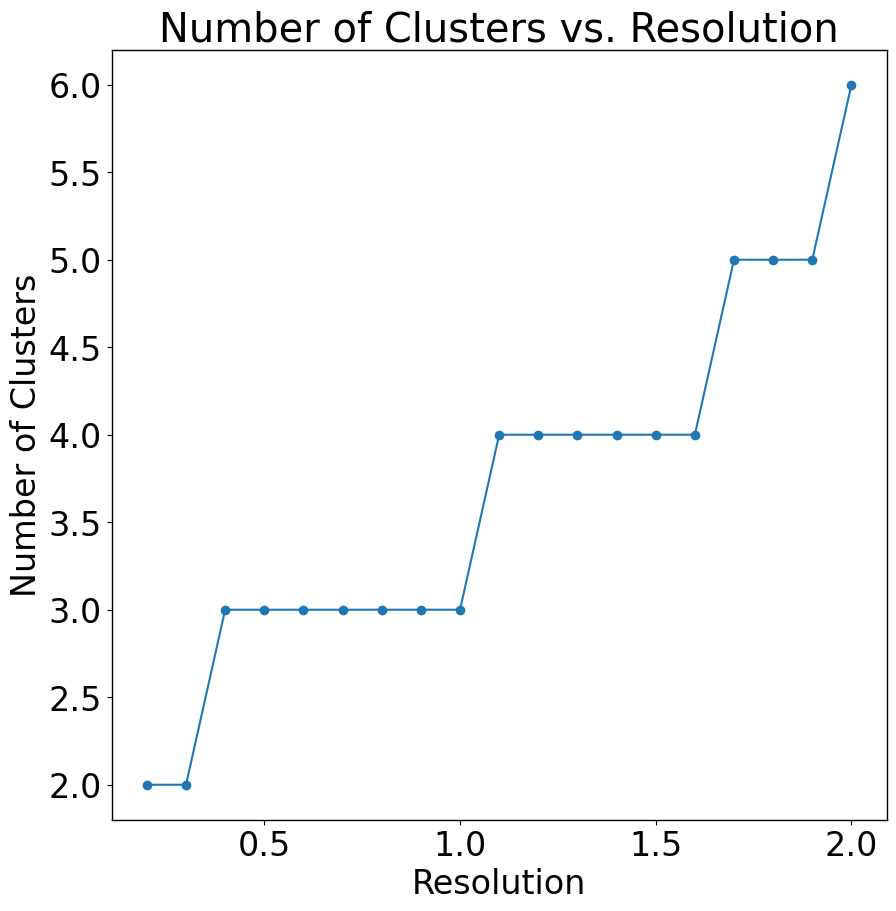

In [37]:
pl.pl.select_best_sil(adata, metric="euclidean")

##### Patients sub-group detection by clustering EMD. 
<div class="alert alert-block alert-info"> 
Using the Silhouette scores of the previous step, we can find the optimal number of cluster of patients to detect different stage of disease. 
</div>

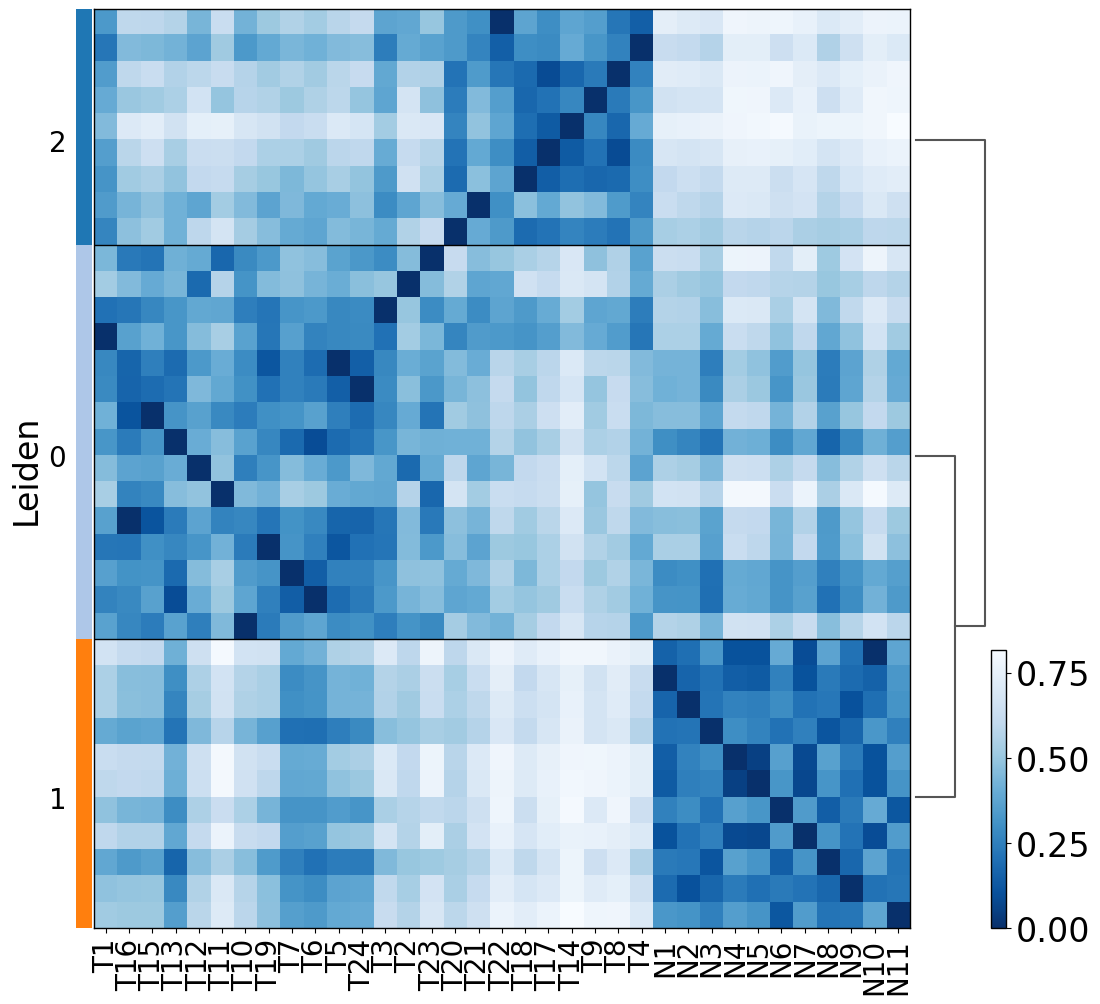

In [38]:
proportion_df=pl.pl.clustering_emd(adata, res = adata.uns['best_res'],metric="euclidean")
#proportion_df=pl.pl.clustering_emd(adata, res = adata.uns['best_res'])

<div class="alert alert-block alert-info"> 
Here we can see that all of the Normal samples are in cluster 1, so we can rename the name of clusters for future analysis. Although this step is optional, we chose to do it in this tutorial.
 </div>

In [40]:
proportion_df = proportion_df[
    ~proportion_df['sampleID'].isin(["T13", "T6", "T7"])
]

In [39]:
proportion_df

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell,Predicted_Labels,sampleID
T1,0.035027,0.115284,0.098206,0.274105,0.053802,0.015376,0.368032,0.040132,0.000031,0.000006,0,T1
T2,0.018421,0.054919,0.079909,0.079584,0.254838,0.333095,0.054597,0.002303,0.107535,0.014799,0,T2
T3,0.110859,0.227012,0.145778,0.133641,0.075928,0.012153,0.289280,0.004557,0.000786,0.000005,0,T3
T4,0.074984,0.097372,0.093476,0.050654,0.193743,0.071075,0.403076,0.005844,0.007823,0.001954,2,T4
T5,0.048443,0.195499,0.180253,0.264555,0.044846,0.000904,0.087015,0.031387,0.134537,0.012560,0,T5
T6,0.026733,0.119720,0.131476,0.214852,0.021918,0.003211,0.155002,0.034738,0.264021,0.028328,0,T6
T7,0.030813,0.212822,0.038837,0.155289,0.022769,0.002688,0.183404,0.008033,0.322585,0.022761,0,T7
T8,0.012942,0.054533,0.120509,0.030166,0.080340,0.018658,0.672747,0.000004,0.008657,0.001444,2,T8
T9,0.270590,0.037389,0.058627,0.002137,0.006377,0.000004,0.594699,0.002125,0.027201,0.000852,2,T9
T10,0.020555,0.305507,0.061602,0.153383,0.182338,0.149733,0.111132,0.012077,0.002458,0.001216,0,T10


In [40]:
proportion_df.loc[proportion_df['Predicted_Labels'] == '1', 'Predicted_Labels'] = 'Normal'
proportion_df.loc[proportion_df['Predicted_Labels'] == '2', 'Predicted_Labels'] = 'Tumor 1' 
proportion_df.loc[proportion_df['Predicted_Labels'] == '0', 'Predicted_Labels'] = 'Tumor 2'

##### Cell-type selection. 
<div class="alert alert-block alert-info"> 
Importantly, we determine which cell type derives the disease from the first stage to the second stage by detecting cell types have statistically significant changes between two sub-groups. This is done using Welch’s t-test, which is appropriate for unequal variances in two groups of samples.

Based on the adjusted p-value threshold you consider, you can choose how statistically significant the cell types you want to have.
  
</div>

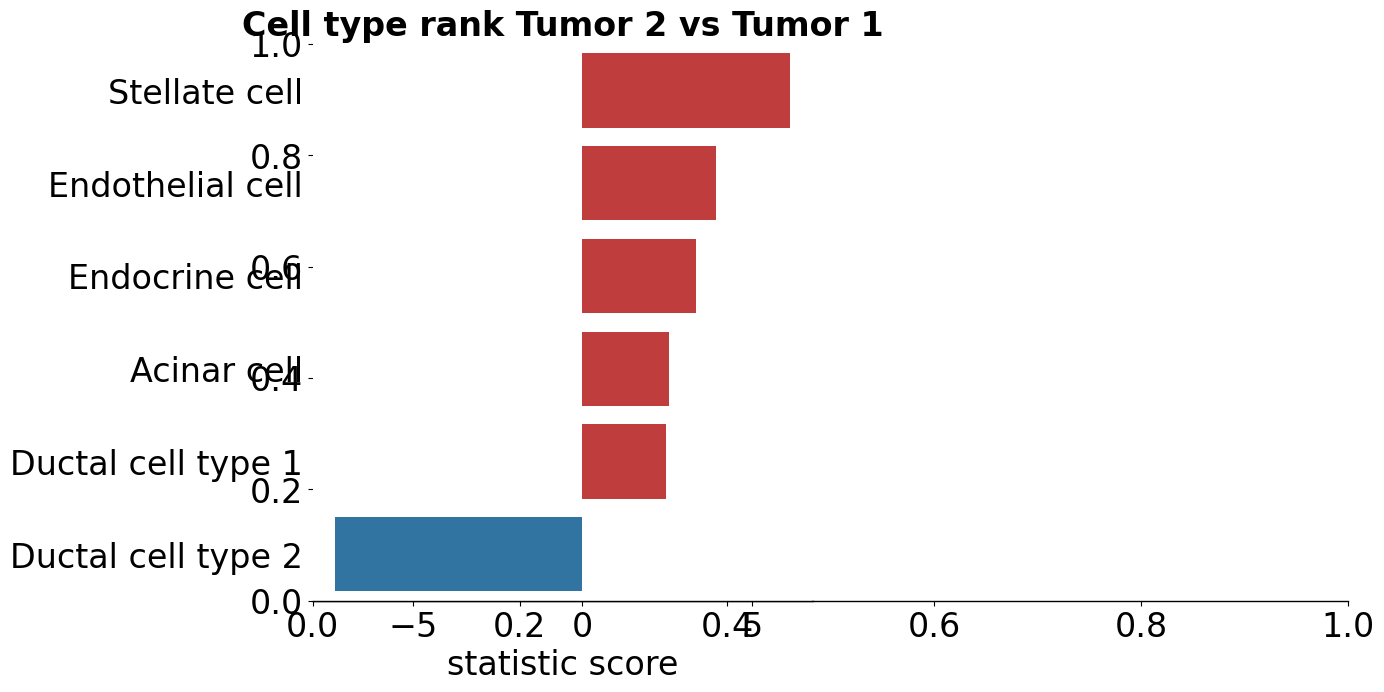

In [41]:
# For heart data
pl.pl.cell_type_diff_two_sub_patient_groups(
    proportion_df,
    proportion_df.columns[0:-2],
    group1 = 'Tumor 2',
    group2 = 'Tumor 1', 
    pval_thr = 0.05, 
    figsize = (15, 8)
    )

<div class="alert alert-block alert-info"> 
Next, we can check the distribution of each patient sub-group in each cell type (the three above ones).
</div>

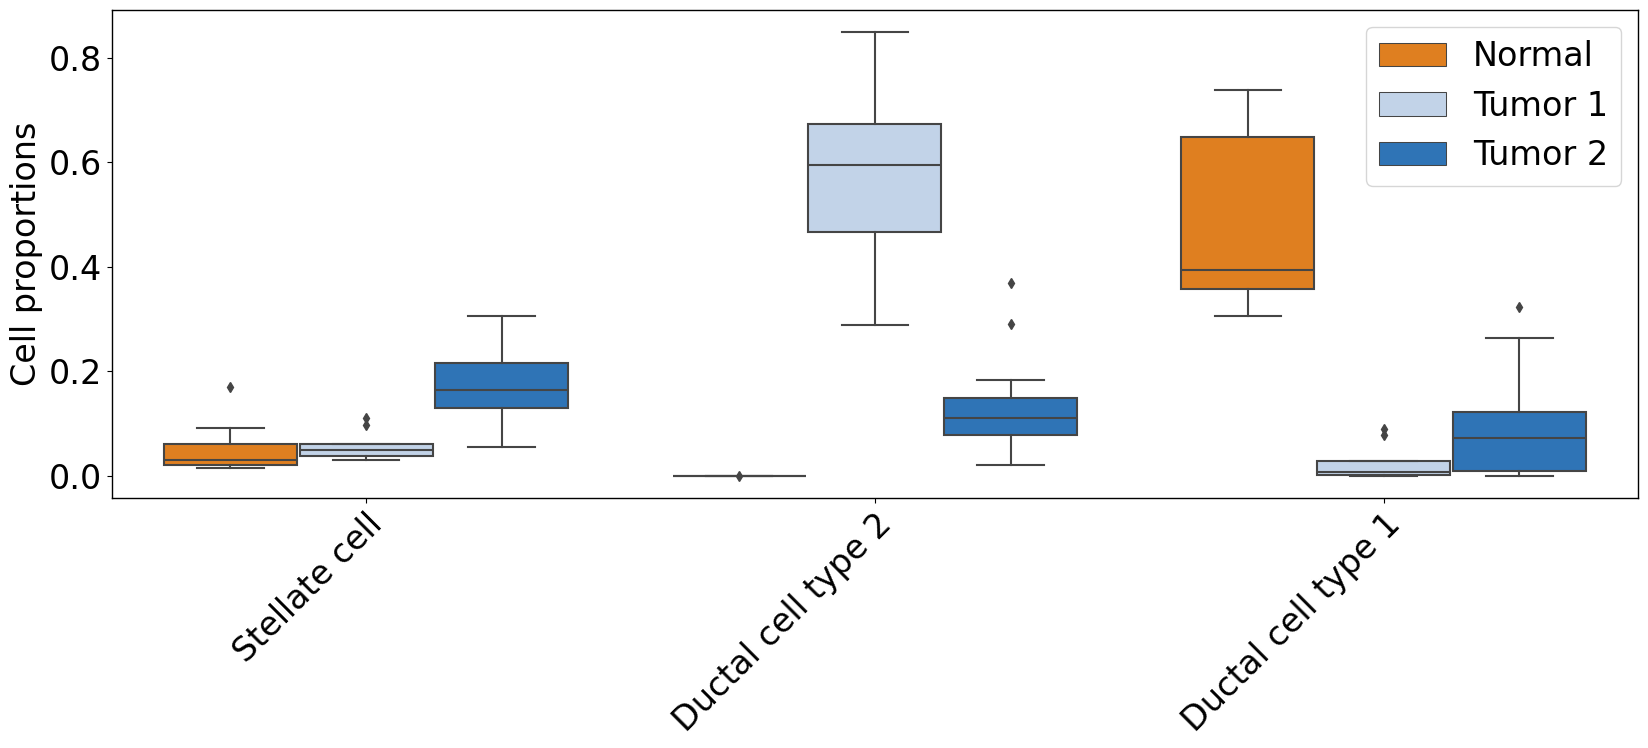

In [42]:
cell_types = ['Ductal cell type 2','Ductal cell type 1','Stellate cell'] # pdac
#cell_types = ['Pericyte 2','intermediate_CM','healthy_CM'] # myocard


pl.pl.plot_cell_types_distributions(
    proportion_df,
    cell_types = cell_types,
    figsize = (17,8),
    label_order = ['Normal', 'Tumor 1', 'Tumor 2'],
    label_colors = ['#FF7F00','#BCD2EE', '#1874CD']
    )



<div class="alert alert-block alert-info"> 
 We also can check the distribution of each patient sub-group in the whole cell types.
</div>

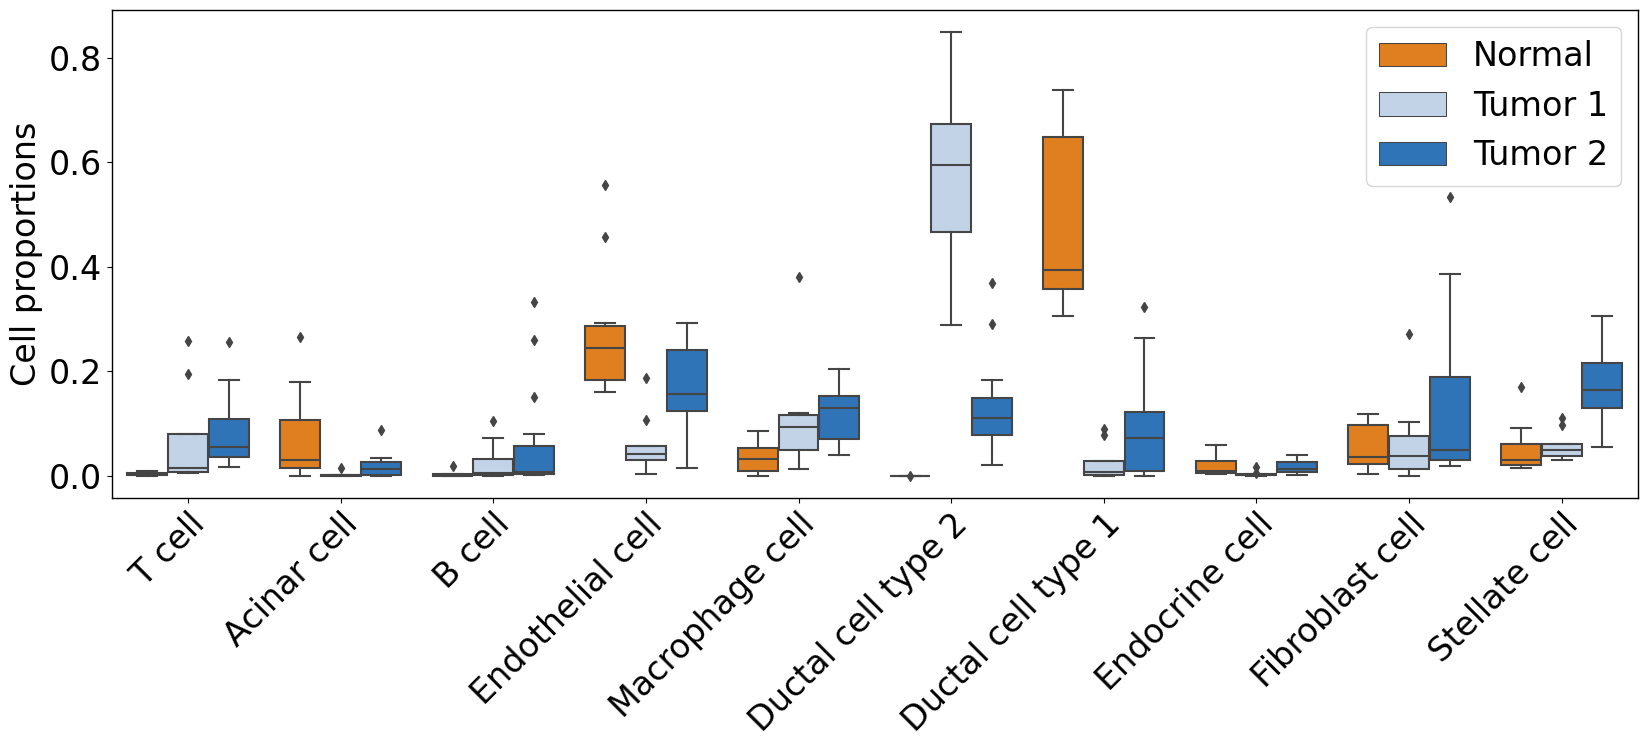

In [43]:
# PDCA
pl.pl.plot_cell_types_distributions(
    proportion_df,
    cell_types = list(proportion_df.columns[0:-2]),
    figsize = (17,8),
    label_order = ['Normal', 'Tumor 1', 'Tumor 2'],
    label_colors = ['#FF7F00', '#BCD2EE', '#1874CD']
    )

# myocard
#pl.pl.plot_cell_types_distributions(
#    proportion_df,
#    cell_types = list(proportion_df.columns[0:-2]),
#    figsize = (17,8),
#    label_order = ['Normal', 'IZ'],
#    label_colors = ['#FF7F00', '#1874CD']
#    )

<div class="alert alert-block alert-info"> 
In the statistical table generated in your results path, all cell types are sorted based on the score and their adjusted p-value.
cell types with positive scores shows the most differences cell types in group 1 compared with group 2 and negative scores shows the other way. 
You can the results in 'Results_PILOT/Diff_Expressions_Results' folder.
</div>

#### Differential expression analysis
<div class="alert alert-block alert-info"> 
At this point for each cell type the plots and results are saved at 'Results_PILOT/Diff_Expressions_Results' folder.
</div>

##### Note:

<div class="alert alert-block alert-info"> 
This step needs the 'limma' package in R, You need to run this function to install it (if you have not already done)!
</div>

##### Ductal cell type 1

<div class="alert alert-block alert-info"> 
In the next step, for specific cell types, we find the Differential genes between two interested patient sub-groups
Based on the fold change threshold, you can determine how much difference you want to see between two interested patients sub-groups. For the tutorial, we already saved the needed input for this function (2000 highly variable genes for each cell type). 
    
- You can run this function for your own data, and it automatically extracts the gene expressions for each cell type ("2000 highly variable genes). In case you want all/more genes, please change the "highly_variable_genes_" or "n_top_genes" parameters.
</div>

In [44]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [45]:
def check_raw(data):
    is_int = np.all(np.equal(np.floor(data), data))
    is_non_negative = np.all(data >= 0)
    return is_int, is_non_negative


# Threshold: minimum percentage of cells containing a gene, e.g. 10%=0.1
def filter_genes(raw_counts, gene_names, threshold):
    min_cells = int(threshold * raw_counts.shape[0])
    detected = np.count_nonzero(raw_counts > 0, axis=0)
    keep_genes = detected >= min_cells
    
    print("Total genes found: ", gene_names.shape)
    print("Total cell count: ", raw_counts.shape[0])
    print(f"Genes must be found in at least {min_cells} cells.")  # Should be 10
    print(f"detected min/max/mean: {detected.min()}/{detected.max()}/{detected.mean():.1f}")
    print(f"keep_genes sum: {keep_genes.sum()}/{len(keep_genes)}")
    
    raw_counts = raw_counts[:, keep_genes]
    gene_names = gene_names[keep_genes]
    return raw_counts, gene_names


def volcano_plot(scores, foldchanges, p_values, cell_type, feature1, feature2, fc_thr = 1, pv_thr = 1,
                 figsize = (20,20), output_path = None,n_p=5,n_n=5,font_size=18, marker='o',
                             color='w',
                             markersize=8,
                             font_weight_legend='normal',
                             size_legend=12,dpi=100
                 
                 
                             ):
   
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from adjustText import adjust_text
    import seaborn as sns

    print("fc: ", fc_thr)
    print("pvalue thresh: ", pv_thr)
    
    df = pd.DataFrame(columns=['log2FoldChange', 'nlog10', 'symbol'])
    df['log2FoldChange'] = foldchanges
    epsilon = np.nextafter(0, 1) 
    df['nlog10'] = -np.log10(p_values.values +  epsilon)
    df['symbol'] = scores.index.values
    #print("printing test df now...")
    #test = df[(df["log2FoldChange"] >= fc_thr) & (df["nlog10"] >= pv_thr)]
    #print(test)
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=["nlog10"], how="all", inplace=True)
    

    selected_labels = df.loc[ (np.abs(df.log2FoldChange) >= fc_thr) & (df['nlog10'] >= pv_thr)]['symbol'].values
    group1_selected_labels = df.loc[ (df.log2FoldChange <= -fc_thr) & (df['nlog10'] >= pv_thr)]['symbol'].values
    pd.DataFrame(group1_selected_labels).to_csv(output_path + "/significant_genes_" + str(cell_type) + "_" + str(feature1) + ".csv")
    
    group2_selected_labels = df.loc[ (df.log2FoldChange >= fc_thr) & (df['nlog10'] >= pv_thr)]['symbol'].values
    pd.DataFrame(group2_selected_labels).to_csv(output_path + "/significant_genes_" + str(cell_type) + "_" + str(feature2) + ".csv")
    
    def map_shape(symbol):
        if symbol in selected_labels:
            return 'important'
        return 'not'
    
    df['color'] = df[['log2FoldChange', 'symbol', 'nlog10']].apply(pl.pl.map_color, fc_thrr = fc_thr, pv_thrr = pv_thr, axis = 1)
    df['shape'] = df.symbol.map(map_shape)
    df['baseMean'] = df.nlog10*10

    
    plt.figure(figsize = figsize, frameon=False, dpi=100)
    plt.style.use('default')
    
    
    #plt.xlim(-xlim, xlim)
    ax = sns.scatterplot(data = df, x = 'log2FoldChange', y = 'nlog10', 
                         hue = 'color', hue_order = ['no', 'very higher','higher', 'mix', 'very lower', 'lower'],
                         palette = ['lightgrey', '#d62a2b', '#D62A2B7A',
                                    'lightgrey', '#1f77b4', '#1F77B47D'],
                         style = 'shape', style_order = ['not', 'important'],
                         markers = ['o', 'o'], 
                         size = 'baseMean', sizes = (40, 800)
                        )

    ax.axhline(pv_thr, zorder = 0, c = 'k', lw = 2, ls = '--')
    ax.axvline(fc_thr, zorder = 0, c = 'k', lw = 2, ls = '--')
    ax.axvline(-fc_thr, zorder = 0, c = 'k', lw = 2, ls = '--')

    texts = []
    filtered_df = df.loc[df['nlog10'] >= pv_thr]
    subset_labels_fold_change_pos = filtered_df.loc[filtered_df['log2FoldChange'] >= fc_thr]
    subset_labels_fold_change_pos = subset_labels_fold_change_pos.sort_values(by='nlog10', ascending=False)
    subset_labels_fold_change_pos = subset_labels_fold_change_pos.head(n_p)['symbol'].values

    subset_labels_fold_change_neg = filtered_df.loc[filtered_df['log2FoldChange'] <= -fc_thr]
    subset_labels_fold_change_neg = subset_labels_fold_change_neg.sort_values(by='nlog10', ascending=False)
    subset_labels_fold_change_neg = subset_labels_fold_change_neg.head(n_n)['symbol'].values
    
    # Combine the subsets of genes
    subset_labels = np.concatenate([subset_labels_fold_change_pos, subset_labels_fold_change_neg])
    for i in range(len(df)):
        if df.iloc[i].symbol in subset_labels:
            if df.iloc[i].nlog10 >= pv_thr and (df.iloc[i].log2FoldChange >= fc_thr):
                texts.append(plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].nlog10, s = df.iloc[i].symbol,
                                     fontsize = font_size, weight = 'bold', family = 'sans-serif'))
            if df.iloc[i].nlog10 >= pv_thr and ( df.iloc[i].log2FoldChange <= -fc_thr):
                texts.append(plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].nlog10, s = df.iloc[i].symbol,
                                     fontsize = font_size, weight = 'bold', family = 'sans-serif'))
    adjust_text(texts)
   # for i in range(len(df)):
    #    if df.iloc[i].symbol in subset_labels:
     #       if df.iloc[i].nlog10 >= pv_thr and (df.iloc[i].log2FoldChange >= fc_thr):
      #          texts.append(plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].nlog10, s = df.iloc[i].symbol,
          #                           fontsize = 16, weight = 'bold', family = 'sans-serif'))
       #     if df.iloc[i].nlog10 >= pv_thr and ( df.iloc[i].log2FoldChange <= -fc_thr):
        #        texts.append(plt.text(x = df.iloc[i].log2FoldChange, y = df.iloc[i].nlog10, s = df.iloc[i].symbol,
         #                            fontsize = 16, weight = 'bold', family = 'sans-serif'))
    #adjust_text(texts)

    custom_lines = [Line2D([0], [0], marker=marker, color=color, markerfacecolor='#d62a2b', markersize=markersize),
                   Line2D([0], [0], marker=marker, color=color, markerfacecolor='#1f77b4', markersize=markersize)]

    plt.legend(custom_lines, ['Higher expressions in ' + feature2, 'Higher expressions in ' + feature1],loc = 1,
               bbox_to_anchor = (1,1.1), frameon = False, prop = {'weight': font_weight_legend, 'size': size_legend})

    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(width = 2)

    plt.title("Expression Score \n "+feature1+" - "+feature2, fontsize = font_size)
    plt.xticks(size = font_size, weight = 'bold')
    plt.yticks(size = font_size, weight = 'bold')
    plt.xlabel("$log_{2}$ (Fold Change)", size = font_size)
    plt.ylabel("-$log_{10}$ (P-value)", size = font_size)

#     plt.savefig(filename, dpi = 100, bbox_inches = 'tight', facecolor = 'white')
    plt.savefig(output_path + "/volcano_" + str(feature1) + "-" + str(feature2) + "_FC.pdf",
                dpi = dpi, bbox_inches = 'tight', facecolor = 'white')
    plt.show()



# PyDeseq2
def compute_diff_expressions2(adata, 
                             cell_type: str = None, 
                             proportions: pd.DataFrame = None,
                             selected_genes: list = None, 
                             font_size:int=18,
                             group1: str = 'Tumor 1',
                             group2: str = 'Tumor 2',
                             fc_thr=0.5, 
                             pval_thr=0.05, 
                             exp_thr=0.1, 
                             sample_col='sampleID',
                             col_cell='cell_types', 
                             shrinkage=False, 
                             number_n=5, 
                             number_p=5, 
                             marker='o', 
                             color='w', 
                             markersize=8, 
                             font_weight_legend='normal', 
                             size_legend=12,
                             figsize=(15,15), 
                             dpi=100, 
                             **kwargs):
    
    path_to_result='Results_PILOT'

    
    # Get gene counts for cell type
    cell_mask = adata.obs[col_cell] == cell_type
    raw_counts = adata.raw[cell_mask].X if adata.raw is not None else adata[cell_mask].X
    gene_names = adata.raw.var_names if adata.raw is not None else adata.var_names
    sample_ids = adata.obs.loc[cell_mask, sample_col]

    # Check for raw counts, filter for genes expressed in at least 10% of cells
    count_matrix = raw_counts.toarray() if hasattr(raw_counts, 'toarray') else raw_counts
    is_int, is_non_negative = check_raw(count_matrix)
    if not is_int or not is_non_negative:
        raise TypeError("Gene counts seem to be normalised, requires raw gene counts instead.")   
    
    
    count_matrix, gene_names = filter_genes(count_matrix, gene_names, threshold=exp_thr)
    
    pseudobulk = (pd.DataFrame(count_matrix.T, index=gene_names, columns=sample_ids)
                  .groupby(level=0, axis=1).sum().T)
    
    # Free up RAM
    del count_matrix, raw_counts 
    
    relevant_samples = proportions[proportions['Predicted_Labels'].isin([group1, group2])]['sampleID']
    pseudobulk = pseudobulk.loc[pseudobulk.index.intersection(relevant_samples)].fillna(0).astype(int)
    metadata = proportions.loc[pseudobulk.index, 'Predicted_Labels'].to_frame()
    
    # Filter for selected genes
    if selected_genes is not None:
        selected_genes = list(set(selected_genes) & set(pseudobulk.columns))
        pseudobulk = pseudobulk[selected_genes]
    
    # Perform dispersion and log fold-change (LFC) estimation
    dds = DeseqDataSet(counts=pseudobulk, metadata=metadata, design_factors='Predicted_Labels')
    dds.deseq2()

    # Statistical Analysis: p-value computation using Wald test
    stat = DeseqStats(dds, contrast=['Predicted_Labels', group2, group1])  # Normal vs Tumor 1
    stat.summary()
    # LFC shrinkage with apeGLM
    if shrinkage:
        stat.lfc_shrink(coeff=f'Predicted_Labels[T.{group2}]')
    
    # Save to csv
    path_to_result = path_to_result + f'Diff_Expressions_Results/{cell_type}/'
    os.makedirs(path_to_result, exist_ok=True)
    stat.results_df.to_csv(path_to_result + "diff_expressions_stats_" + cell_type + ".csv")

    # Volcano Plot for viualisation
    pv_thr = -np.log10(pval_thr)  
    volcano_plot(
        pseudobulk.T,  
        stat.results_df['log2FoldChange'], 
        stat.results_df['padj'],
        cell_type, group1, group2, fc_thr, pv_thr,  
        figsize=figsize, output_path=path_to_result,
        n_p=number_p, n_n=number_n, font_size=font_size,
        marker=marker, color=color, markersize=markersize,
        font_weight_legend=font_weight_legend, size_legend=size_legend, dpi=dpi
    )
    
    return stat


In [47]:
cell_type = 'Ductal cell type 2'

Total genes found:  (23365,)
Total cell count:  11315
Genes must be found in at least 1131 cells.
detected min/max/mean: 0/11315/1651.9
keep_genes sum: 9242/23365


Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.66 seconds.

Fitting dispersion trend curve...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 0.83 seconds.

Fitting LFCs...
... done in 0.49 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 73 outlier genes.

Fitting dispersions...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Running Wald tests...
... done in 0.58 seconds.



Log2 fold change & Wald test p-value: Predicted_Labels Tumor 2 vs Tumor 1
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
PDK1        57.863346       -0.880148  0.333999 -2.635183  0.008409  0.234432
KRT18     6099.572729       -0.214625  0.268682 -0.798808  0.424402  0.877429
PPP1R16A   314.487484       -0.750505  0.282006 -2.661312  0.007784  0.225962
IL6R        42.521831       -0.156747  0.247065 -0.634436  0.525796  0.911572
QPRT        56.754389       -0.743211  0.747260 -0.994581  0.319940  0.839785
...               ...             ...       ...       ...       ...       ...
KANSL3      59.905847        0.138707  0.192349  0.721120  0.470836  0.891342
HSPA13      45.790956        0.561881  0.239848  2.342651  0.019147  0.344279
SOCS1       55.955076        0.715076  0.312952  2.284937  0.022317  0.365199
CREG1      237.035855       -0.116027  0.182148 -0.636994  0.524129  0.910162
FBXO7      193.473584        0.136932  0.178231  0.768287  0.442316 

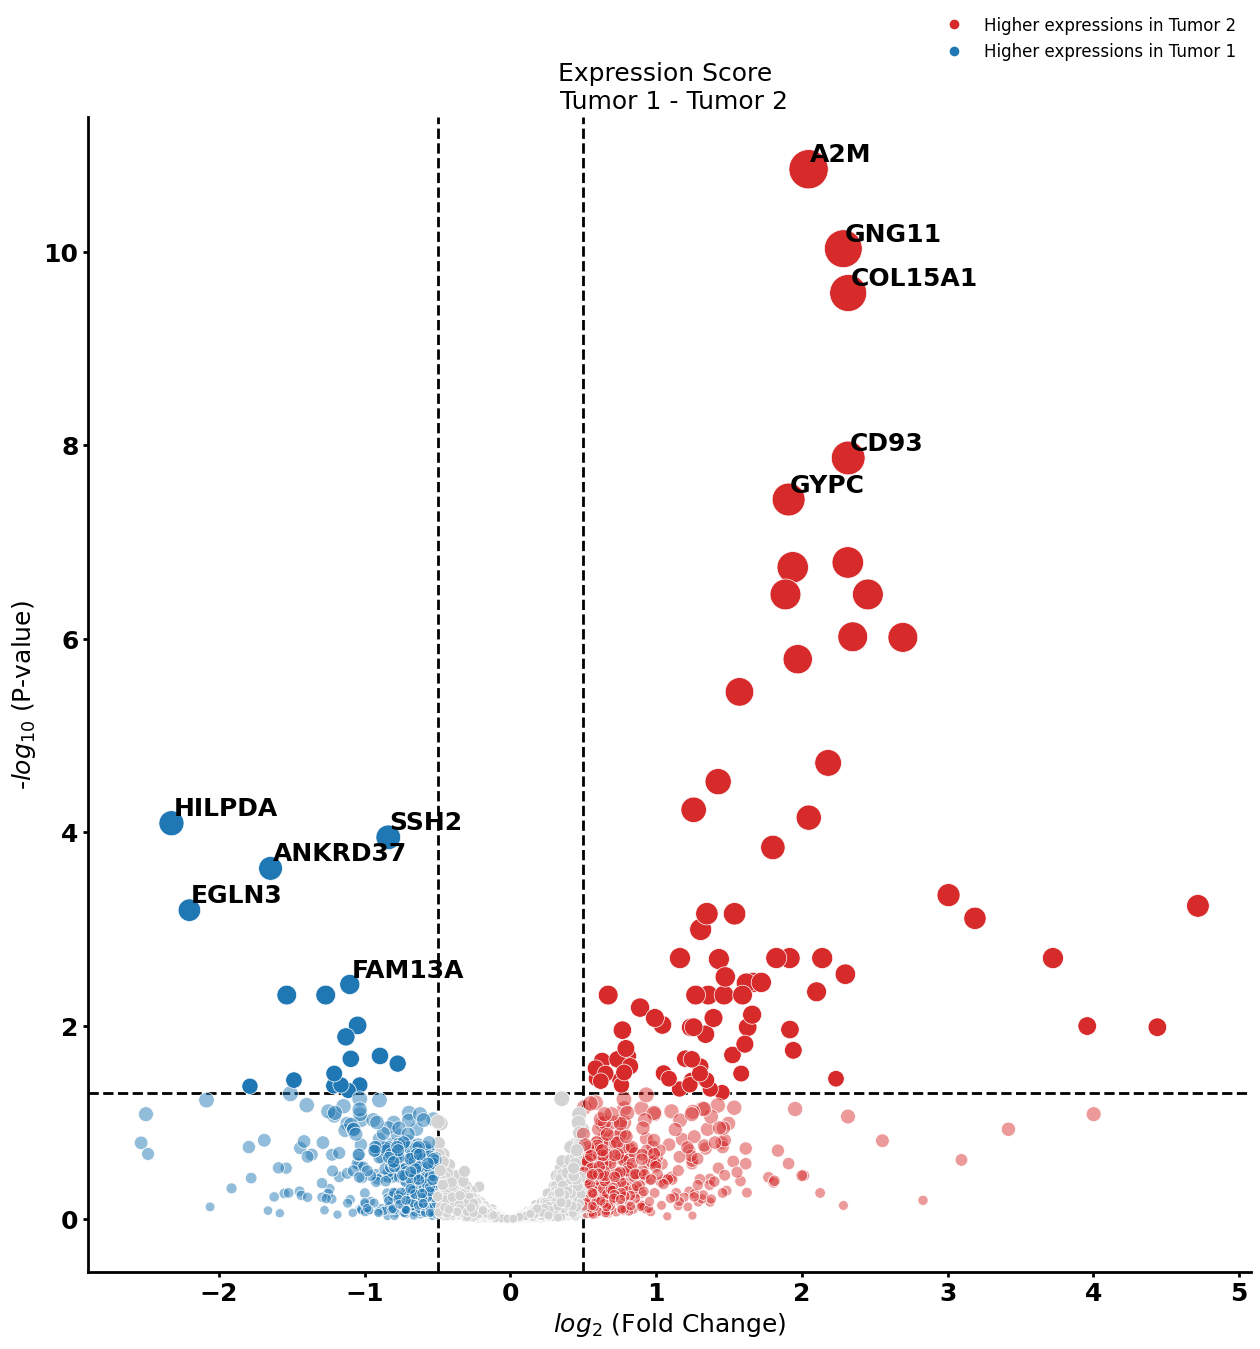

In [51]:
# create deseq object, perform dispersion and log fold-change (LFC) estimation.
stat = compute_diff_expressions2(
    adata, 
    cell_type=cell_type,
    proportions=proportion_df,
    group1='Tumor 1',
    group2='Tumor 2', 
    col_cell=sample_info['clusters_col'],
    exp_thr=0.1,
    sample_col=sample_info['sample_col'],
    shrinkage=False
)

###### Gene Ontology analysis

<div class="alert alert-block alert-info">  Based on the adjusted p-value and fold change threshold, we select genes that are highly differentiated in each patient sub-groups and specify their annotation using the <a href="https://biit.cs.ut.ee/gprofiler/gost">gProfiler</a>
    
</div>

In [50]:
adata

AnnData object with n_obs × n_vars = 57530 × 23365
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'peng_cluster', 'RNA_snn_res.0.8', 'seurat_clusters.res=1', 'r2', 'note', 'pathologic_diagnoses', 'Gender', 'CA199', 'Procedure', 'Maximum_Diameter_mm', 'Staging', 'vascular_invasion', 'Age', 'Diabetes', 'Location', 'TNM_Classification', 'perineural_invasion', 'peripancreatic_infiltarion', 'RNA_snn_res.1', 'RNA_snn_res.0.1', 'seurat_clusters.res=0.1', 'RNA_snn_res.0.2', 'seurat_clusters.res=0.2', 'RNA_snn_res.0.3', 'seurat_clusters.res=0.3', 'RNA_snn_res.0.4', 'seurat_clusters.res=0.4', 'RNA_snn_res.0.5', 'seurat_clusters.res=0.5', 'RNA_snn_res.0.6', 'seurat_clusters.res=0.6', 'RNA_snn_res.0.7', 'seurat_clusters.res=0.7', 'seurat_clusters.res=0.8', 'RNA_snn_res.0.9', 'seurat_clusters.res=0.9', 'Cluster_res0.9_anno', 'Cluster_res0.9_anno_combined', 'accAnnot', 'accSample', 'accLabel', 'accLabel1'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance

In [55]:
group_genes = pd.read_csv("/home/charlottewolf/Documents/Arbeit/UKA_Arbeit/Projects/PILOT/Tutorial/Results_PILOTDiff_Expressions_Results/Ductal cell type 2/significant_genes_Ductal cell type 2_Tumor 2.csv")

In [55]:
def gene_annotation_cell_type_subgroup(data: pd.DataFrame = None,
                                       symbol: str = 'gene',
                                       sig_col: str = 'significant_gene',
                                       cell_type: str = None,
                                       group: str = None,
                                       sources: str = None,
                                       num_gos: int = 10,
                                       fig_h: int = 6,
                                       fig_w: int = 4,
                                       font_size: int = 14,
                                       max_length:int = 50,
                                       path_to_results: str = None,
                                       my_pal = None
                                     ):
    """
    Plot to show the most relative GO terms for specifc cell-type of determind patient sub-group

    Parameters
    ----------
    data : pd.DataFrame
        DESCRIPTION. The default is None.
    symbol : str, optional
        DESCRIPTION. The default is 'gene'.
    sig_col : str, optional
        DESCRIPTION. The default is 'significant_gene'.
    cell_type : str
        DESCRIPTION. The default is None.
    group : str
        DESCRIPTION. The default is None.
    sources : str, optional
        DESCRIPTION. The default is None.
    num_gos : int, optional
        DESCRIPTION. The default is 10.
    fig_h : int, optional
        DESCRIPTION. The default is 6.
    fig_w : int, optional
        DESCRIPTION. The default is 4.
    font_size : int, optional
        DESCRIPTION. The default is 14.
    max_length : int, optional
        DESCRIPTION. The default is 50.
    path_to_results : str, optional
        DESCRIPTION. The default is None.
    my_pal : TYPE, optional
        DESCRIPTION. The default is None.

    Returns
    -------
    None.

    """

#     path_to_results = 'Results_PILOT'

    color = my_pal[group]

#     group_genes = pd.read_csv(path_to_results + \
#                               "/significant_genes_" + cell_type + "_" + group + ".csv")

    group_genes = data.loc[data[sig_col] == group, symbol].values
    gp = GProfiler(return_dataframe = True)
    if list(group_genes):
        gprofiler_results = gp.profile(organism = 'hsapiens',
                                       query = list(group_genes),
                                       no_evidences = False,
                                       sources = sources)
    else:
        return "Genes list is empty!"
    
    if(gprofiler_results.shape[0] == 0):
        return "Not enough information!"
    elif(gprofiler_results.shape[0] < num_gos):
        num_gos = gprofiler_results.shape[0]

    all_gprofiler_results = gprofiler_results.copy()
    # display(all_gprofiler_results.head())
       
    # print(len(list(group_genes['symbol'].values)))
    # selected_gps = gprofiler_results.loc[0:num_gos,['name', 'p_value']]
    selected_gps = gprofiler_results.head(num_gos)[['name', 'p_value']]
    
    selected_gps['nlog10'] = -np.log10(selected_gps['p_value'].values)

    for i in selected_gps.index:
        split_name = "\n".join(tw.wrap(selected_gps.loc[i, 'name'], max_length))
        selected_gps.loc[i, 'name'] = split_name
    
    figsize = (fig_h, fig_w)

    plt.figure(figsize = figsize, dpi = 100)
    plt.style.use('default')
    sns.scatterplot(data = selected_gps, x = "nlog10", y = "name", s = 300, color = color)

    plt.title('GO enrichment in ' + cell_type + ' associated with ' + group + \
              '\n (number of genes: ' + str(len(list(group_genes))) + ")", fontsize = font_size + 2)

    plt.xticks(size = font_size)
    plt.yticks(size = font_size)

    plt.ylabel("GO Terms", size = font_size)
    plt.xlabel("-$log_{10}$ (P-value)", size = font_size)
    
    save_path = path_to_results + '/'
    if not os.path.exists(save_path):
            os.makedirs(save_path)
#     plt.savefig(save_path + group + ".pdf", bbox_inches = 'tight',
#                 facecolor = 'white', transparent = False)
    plt.show()
    
    all_gprofiler_results.to_csv(save_path + group + ".csv")
    
def get_sig_genes(data, symbol, foldchange, p_value, cell_type,
                 feature1, feature2,
                 low_fc_thr = 1, high_fc_thr = 1, pv_thr = 1):
    df = pd.DataFrame(columns=['log2FoldChange', 'nlog10', 'symbol'])
    df['log2FoldChange'] = data[foldchange]
    df['nlog10'] = -np.log10(data[p_value].values)
    df['symbol'] = data[symbol].values
    
    df.replace([np.inf, -np.inf], np.nan, inplace = True)
    df.dropna(subset = ["nlog10"], how = "all", inplace = True)
    
    data['significant_gene'] = ""
    group1_selected_labels = df.loc[ (df.log2FoldChange <= -low_fc_thr) & (df['nlog10'] >= pv_thr), 'symbol'].values
    data.loc[data[symbol].isin(group1_selected_labels), 'significant_gene'] = feature1
    
    group2_selected_labels = df.loc[ (df.log2FoldChange >= high_fc_thr) & (df['nlog10'] >= pv_thr), 'symbol'].values
    data.loc[data[symbol].isin(group2_selected_labels), 'significant_gene'] = feature2

    return data

def gene_annotation_cell_type_subgroup2(cell_type: str = None,
                                   group: str = None,
                                   source: str = None,
                                   num_gos: int = 15,
                                   figsize=(12,12),
                                   font_size: int = 24,
                                   bbox_inches: str = 'tight',
                                   facecolor: str = 'white',
                                   transparent: bool = False,
                                   organism: str = 'hsapiens',
                                   dpi: int = 100,
                                   s: int = 200,
                                   color: str = 'tab:blue'):
    """
    Perform Gene Ontology (GO) enrichment analysis and create a scatterplot of enriched terms.

    Parameters:
    ----------
    cell_type : str, optional
        Specify cell type name to check its differential expression genes. The default is None.
    group : str, optional
        Name of patients sub-group of interest. The default is None.
    source : str, optional
        Specify the source of GO terms. The default is None.
    num_gos: int, optional
        Number of GO terms to plot. Default is 5.
    figsize: tuple, optional
        figsize. Default is (12,12).
    font_size: int, optional
        Font size for labels. Default is 24.
    bbox_inches: str, optional
        Bounding box for saving the plot. Default is 'tight'.
    facecolor: str, optional
        Background color of the figure. Default is 'white'.
    transparent: bool, optional
        Set to True for a transparent figure. Default is False.
    organism: str, optional
        The organism for GO analysis. Default is 'hsapiens'.
    dpi: int, optional
        Dots per inch for the saved plot image. Default is 100.
    s: int, optional
        Marker size for the scatterplot. Default is 200.
    color: str, optional
        Color of the scatterplot markers. Default is 'tab:blue'.

    Returns:
    --------
    None
        Saves the scatterplot of enriched GO terms as a PDF file.
    """

    path_to_results='Results_PILOT'
    group_genes = pd.read_csv(path_to_results +'Diff_Expressions_Results/'+cell_type+"/significant_genes_"+cell_type+"_"+group+".csv",
                               index_col=0)
    
    
    from gprofiler import GProfiler
    from matplotlib import pyplot as plt
    import seaborn as sns


    gp = GProfiler(return_dataframe=True)
    if list(group_genes['0'].values):
        gprofiler_results = gp.profile(organism = organism,
                                       query = list(group_genes['0'].values))
    else:
        return "Genes list is empty!"
    
    
    if(gprofiler_results.shape[0] == 0):
        return "Not enough information!"

    
    if(gprofiler_results.shape[0] < num_gos):
        num_gos = gprofiler_results.shape[0]
    
    if source: 
        gprofiler_results = gprofiler_results[gprofiler_results['source']==source]
       
    
  
    selected_gps = gprofiler_results.head(num_gos)[['name', 'p_value']]
    
    selected_gps['nlog10'] = -np.log10(selected_gps['p_value'].values)

    plt.figure(figsize = figsize, dpi = dpi)
    plt.style.use('default')
    sns.scatterplot(data = selected_gps, x= "nlog10", y= "name", s = s, color = color)

    plt.title('GO enrichment in ' + cell_type + ' associated with ' + group, fontsize = font_size)

    plt.xticks(size = font_size)
    plt.yticks(size = font_size)

    plt.ylabel("GO Terms", size = font_size)
    plt.xlabel("-$log_{10}$ (P-value)", size = font_size)
    
    if not os.path.exists(path_to_results+'/Diff_Expressions_Results/'+cell_type+'/GO_analysis/'):
            os.makedirs(path_to_results+'/Diff_Expressions_Results/'+cell_type+'/GO_analysis/')
    path_to_results=path_to_results+'/Diff_Expressions_Results/'+cell_type+'/GO_analysis/'
    plt.savefig(path_to_results+ group + ".pdf", bbox_inches = bbox_inches, facecolor=facecolor, transparent=transparent)
    gprofiler_results.to_csv(path_to_results+group+'_'+cell_type+"_all_gprofiler_results.csv")

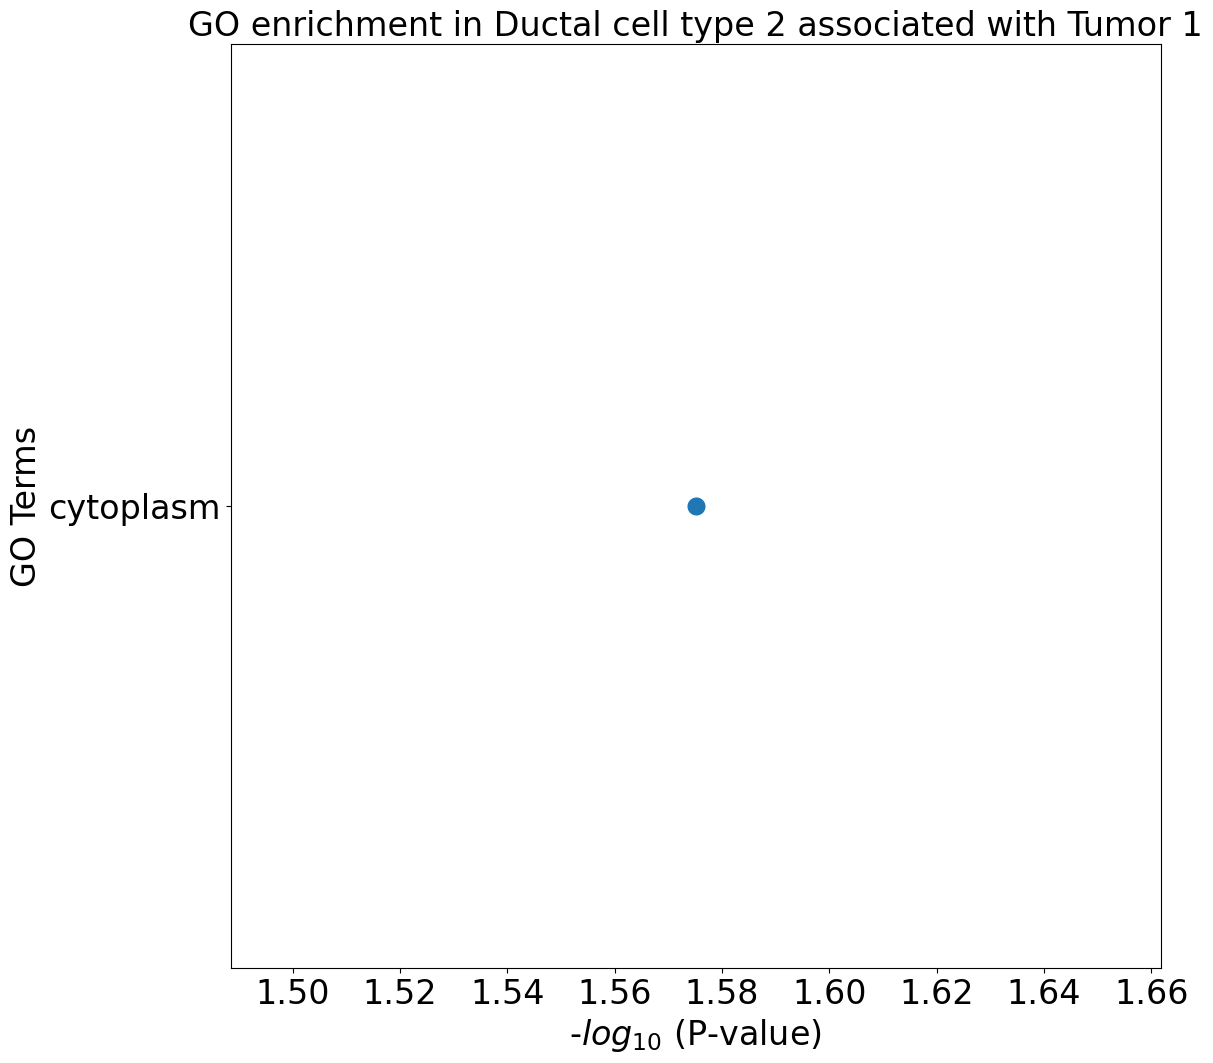

In [62]:
cell_type = "Ductal cell type 2"
my_pal = {
    "Normal": '#FF7F00', 
    "Tumor 1": '#BCD2EE', 
    "Tumor 2": '#1874CD'
}
gene_annotation_cell_type_subgroup2(
    cell_type = cell_type, 
    group = 'Tumor 1',
    num_gos = 10
    )


In [70]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 2',
    num_gos = 10
    )

TypeError: 'NoneType' object is not subscriptable

##### Stellate cell

Total genes found:  (23365,)
Total cell count:  5907
Genes must be found in at least 590 cells.
detected min/max/mean: 0/5907/530.1
keep_genes sum: 5828/23365
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.45 seconds.

Fitting dispersion trend curve...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.53 seconds.

Fitting LFCs...
... done in 0.54 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 6 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.33 seconds.



Log2 fold change & Wald test p-value: Predicted_Labels Tumor 2 vs Tumor 1
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
KRT18     172.874367       -0.795556  0.188544 -4.219484  0.000024  0.005708
PPP1R16A   22.662447       -0.315059  0.222582 -1.415473  0.156930  0.578880
DTX3       38.141065        0.103312  0.170660  0.605367  0.544935  0.857782
BCAM      168.926502        0.077234  0.306331  0.252126  0.800944  0.955989
HPRT1      63.429174       -0.351028  0.141483 -2.481059  0.013099  0.204740
...              ...             ...       ...       ...       ...       ...
DNAJC3     69.568770        0.000685  0.149652  0.004579  0.996346  0.999168
KLF3       24.592297       -0.119924  0.176500 -0.679458  0.496848  0.828743
HSPA13     23.357071        0.198791  0.198137  1.003305  0.315714  0.713071
CREG1      49.360206        0.303576  0.177119  1.713971  0.086534  0.461123
FBXO7      50.825346       -0.028507  0.127537 -0.223520  0.823131  0.961582

[

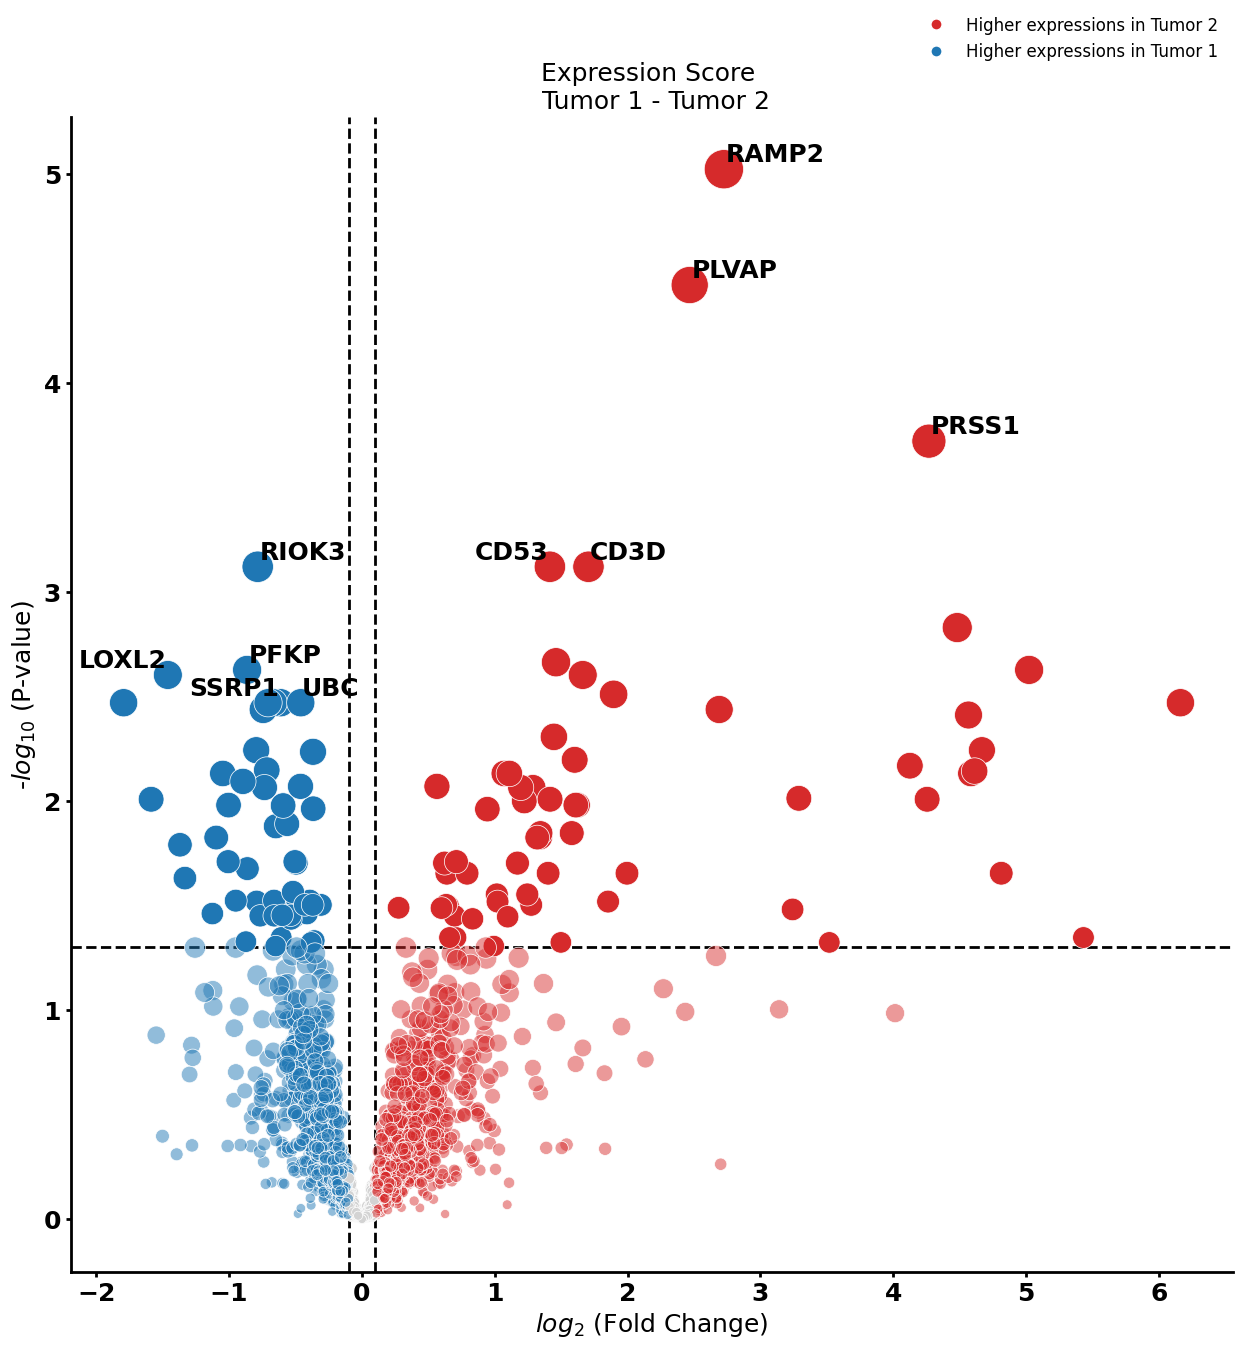

In [66]:
cell_type = "Stellate cell" 
compute_diff_expressions2(
    adata,
    cell_type,
    proportion_df,
    fc_thr = 0.1,
    pval_thr = 0.05,
    group1 = 'Tumor 1',
    group2 = 'Tumor 2',
    sample_col = sample_info['sample_col'],
    col_cell = sample_info['clusters_col']
    )

###### Gene Ontology analysis

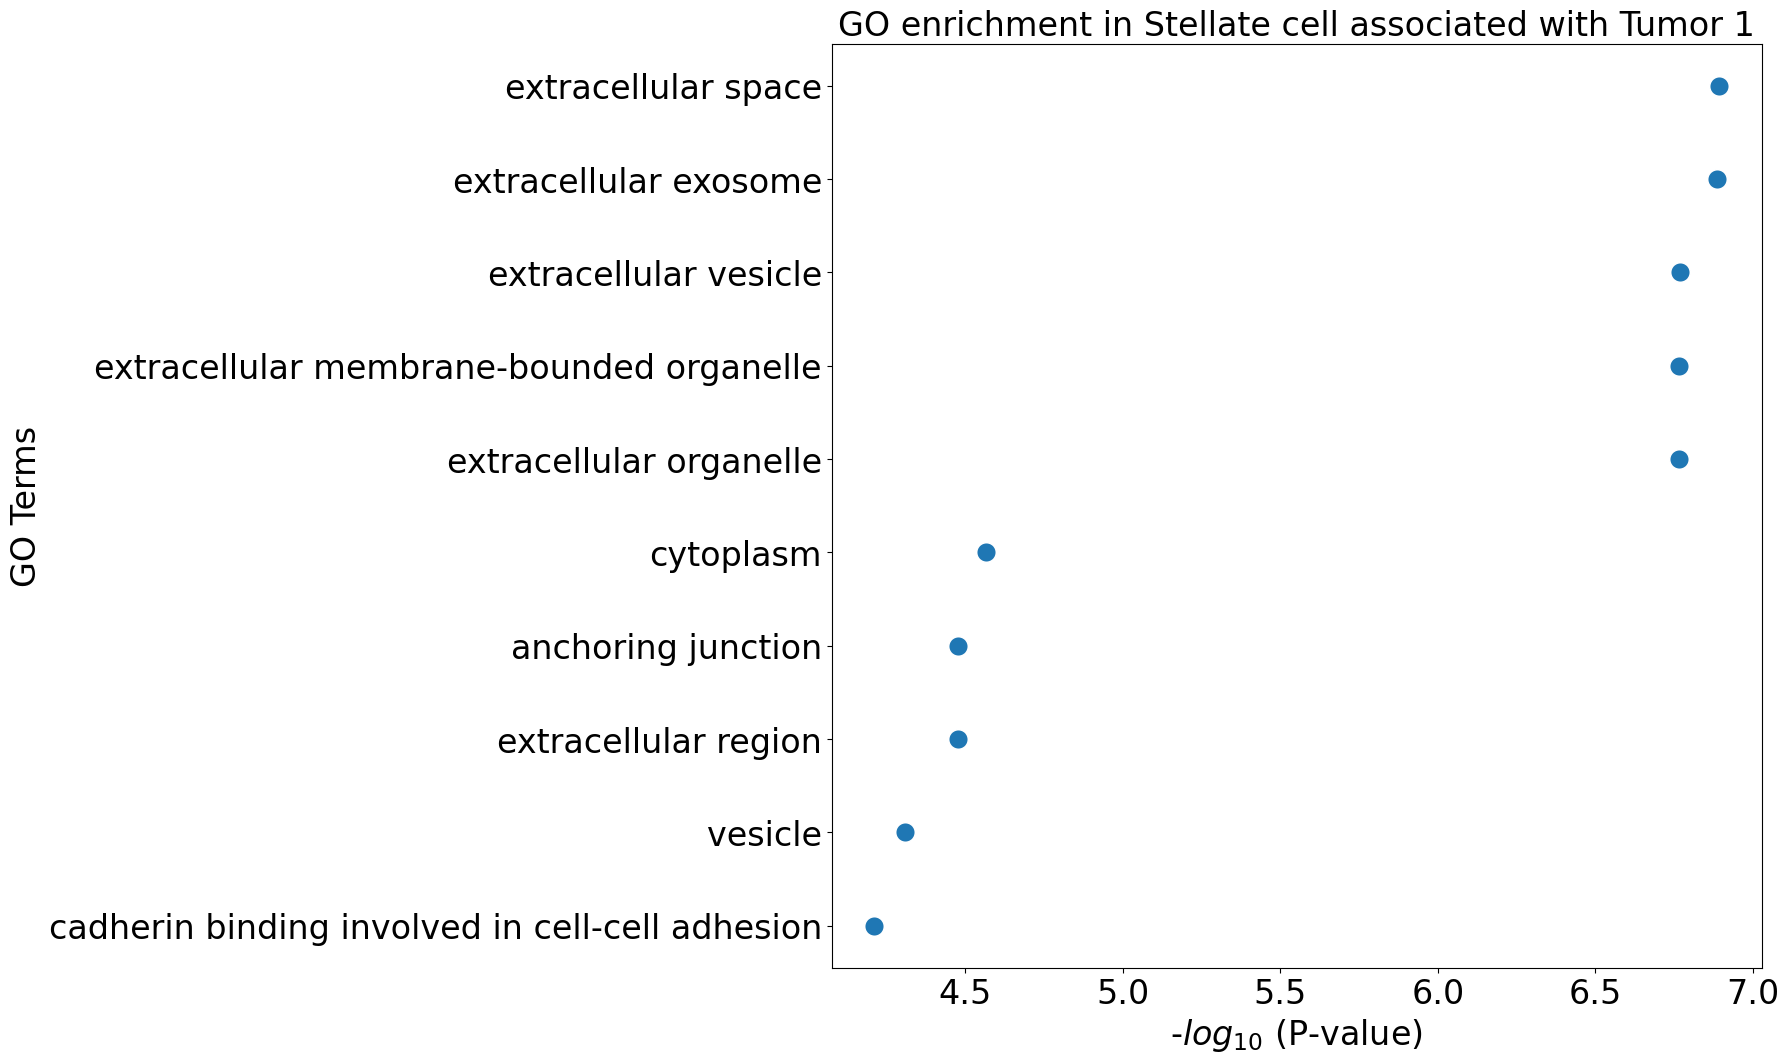

In [67]:
gene_annotation_cell_type_subgroup2(
    cell_type = cell_type, 
    group = 'Tumor 1',
    num_gos = 10
    )

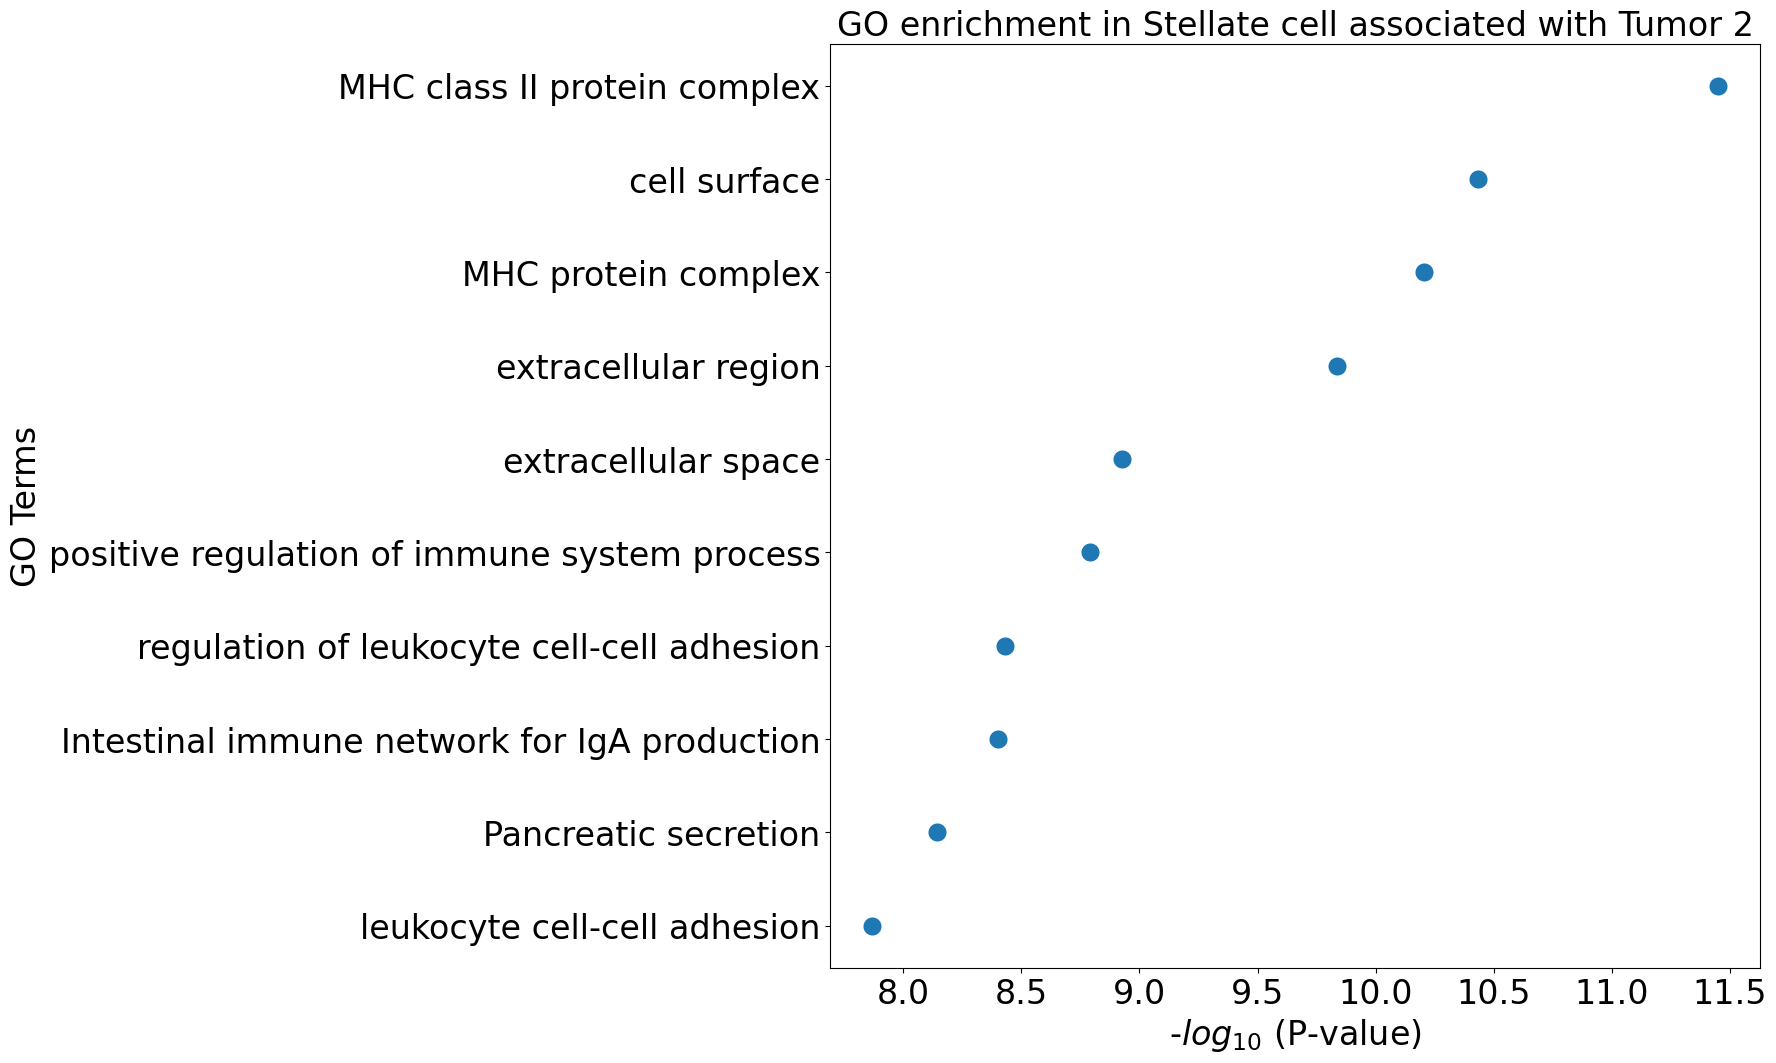

In [68]:
gene_annotation_cell_type_subgroup2(
    cell_type = cell_type,
    group = 'Tumor 2',
    num_gos = 10
    )

##### Ductal cell type 2

run limma lmFit
run limma eBayes


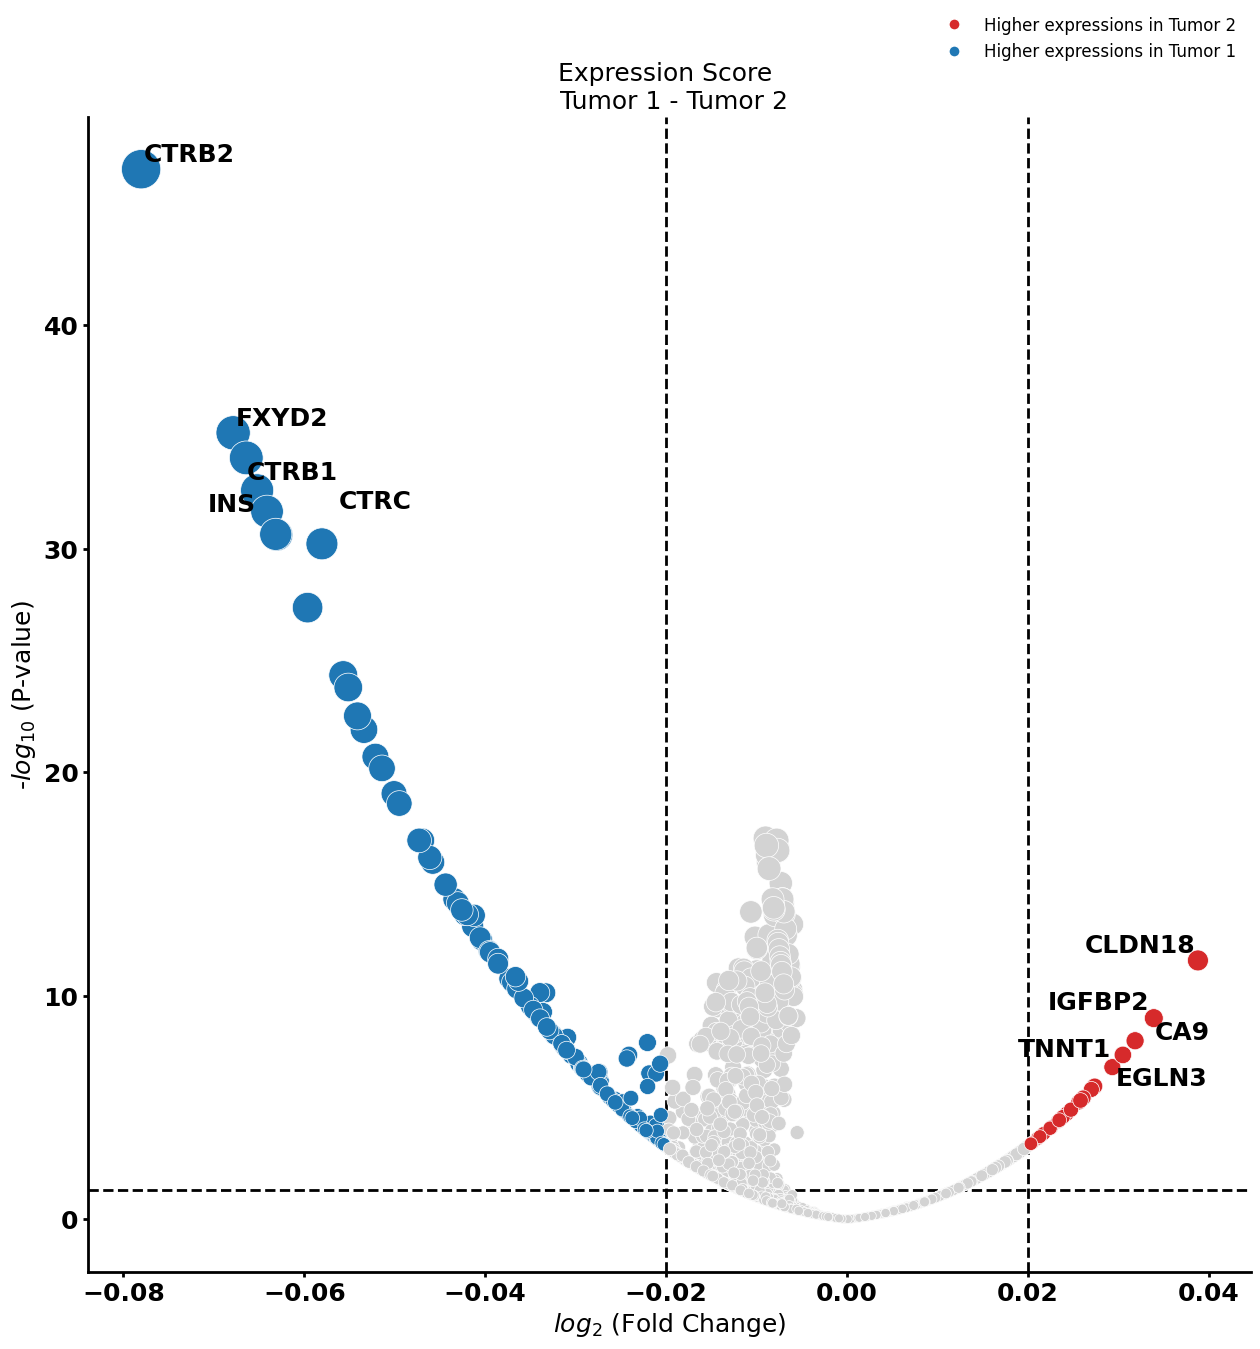

In [19]:
cell_type = "Ductal cell type 2" 
pl.tl.compute_diff_expressions(
    adata,
    cell_type, 
    proportion_df,
    fc_thr = 0.020,
    pval_thr = 0.05,
    group1 = 'Tumor 1',
    group2 = 'Tumor 2',
    sample_col = 'sampleID',
    col_cell = 'cell_types',
    )

###### Gene Ontology analysis

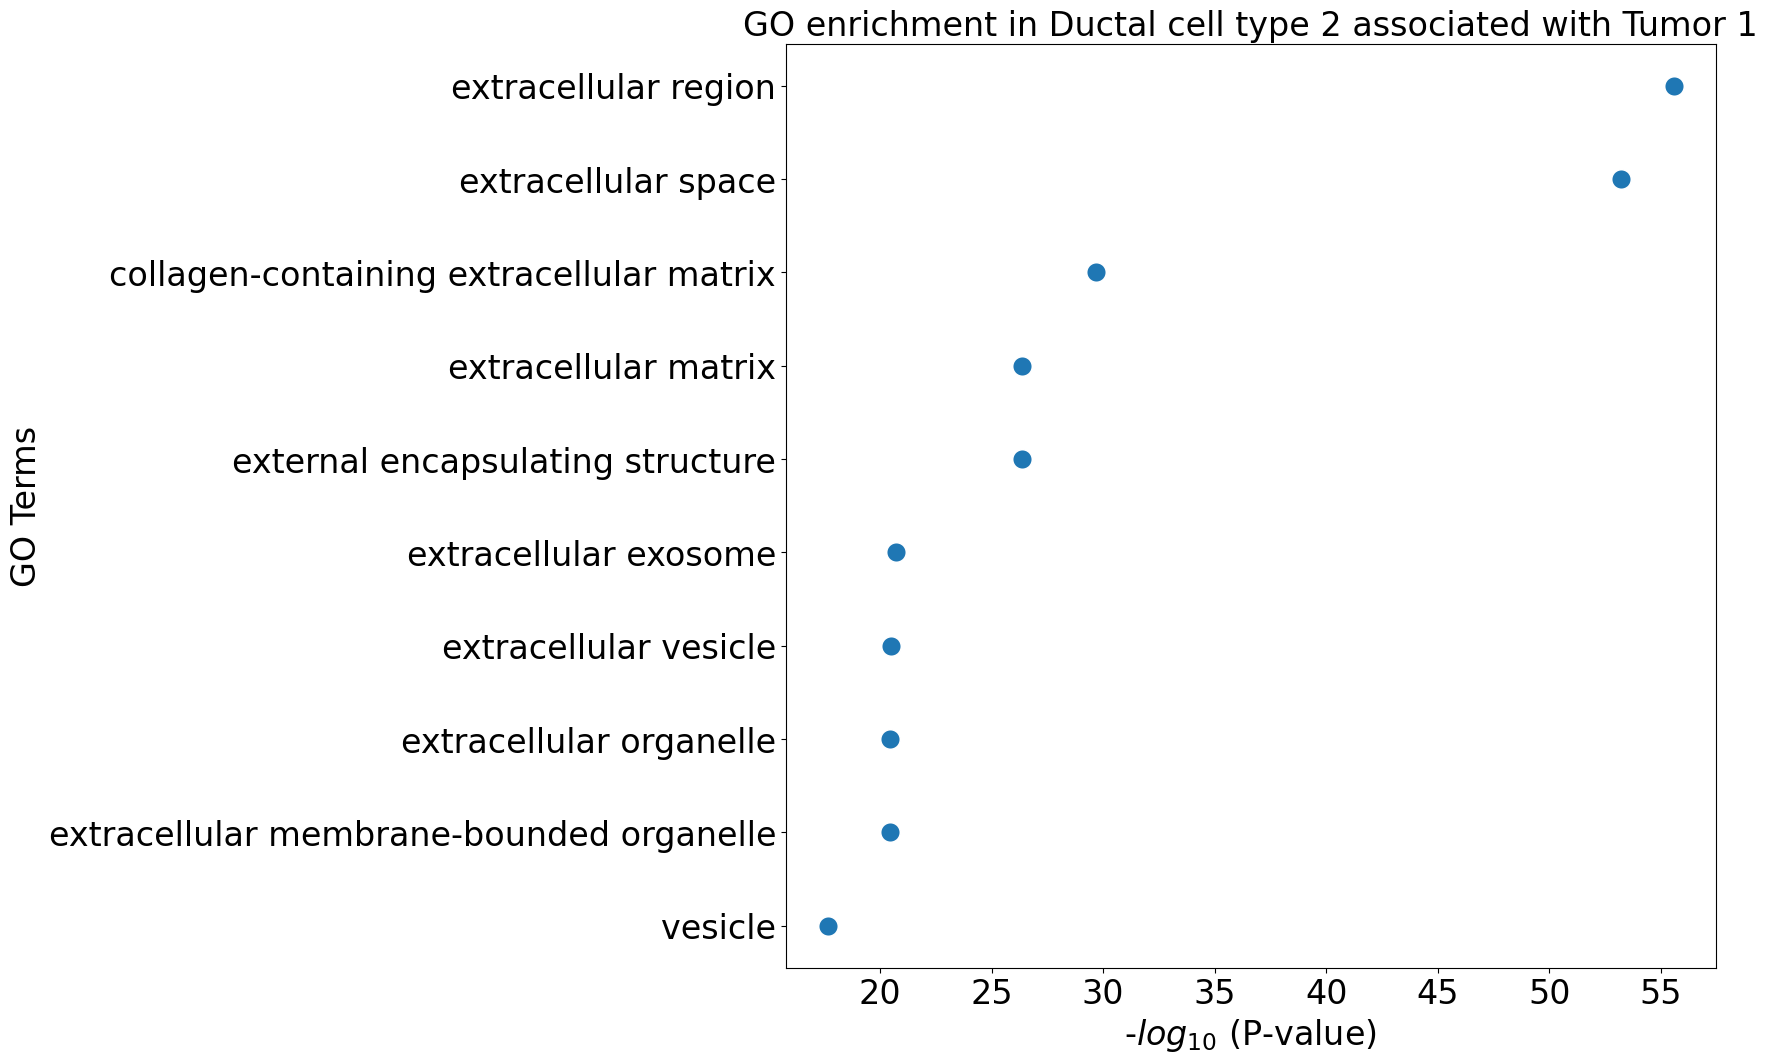

In [20]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type,
    group = 'Tumor 1',
    num_gos = 10
    )

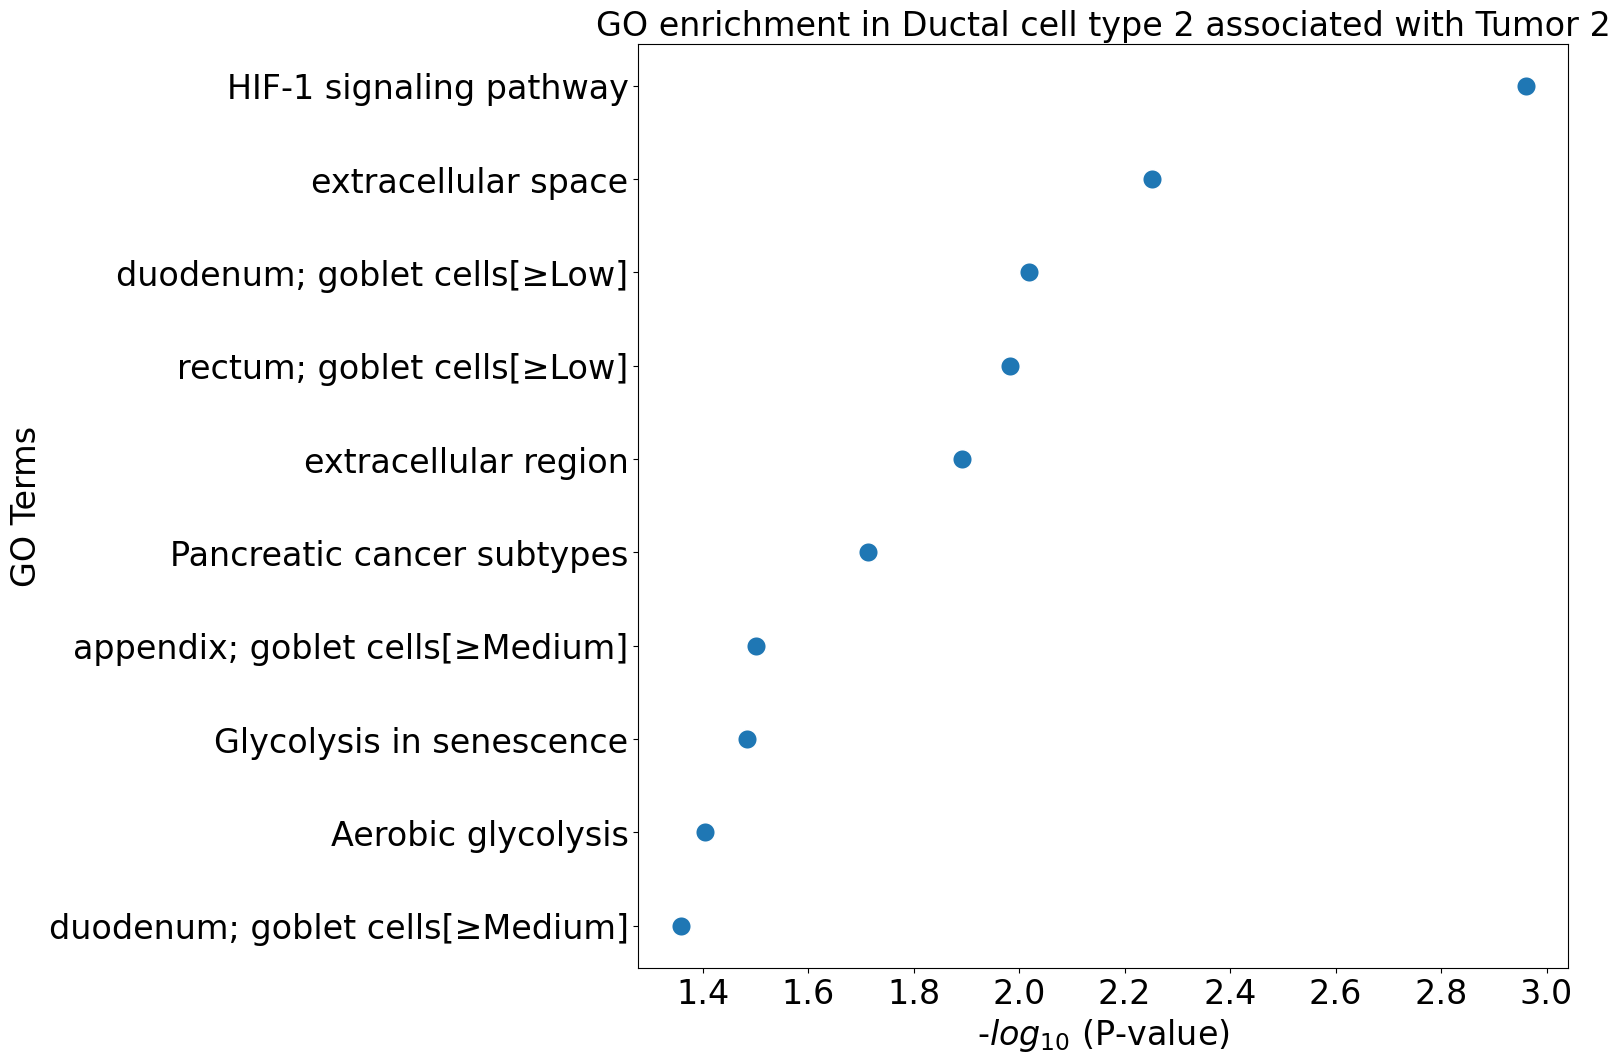

In [21]:
pl.pl.gene_annotation_cell_type_subgroup(
    cell_type = cell_type, 
    group = 'Tumor 2',
    num_gos = 10
    )

#### Pseudobulk differential expression analysis
<div class="alert alert-block alert-info">In some situations, We are interested in the genes are expressed different at the sample level without considering the variation across the cells. We define pseudo-bulk samples as summing counts for all cells with the same combination of label and sample. We use the DESeq2 tool to perform pseudo-bulk differential expression analysis on a specific cell type sub-patient group</a>
</div>

Plot cells frequency for each sample... 


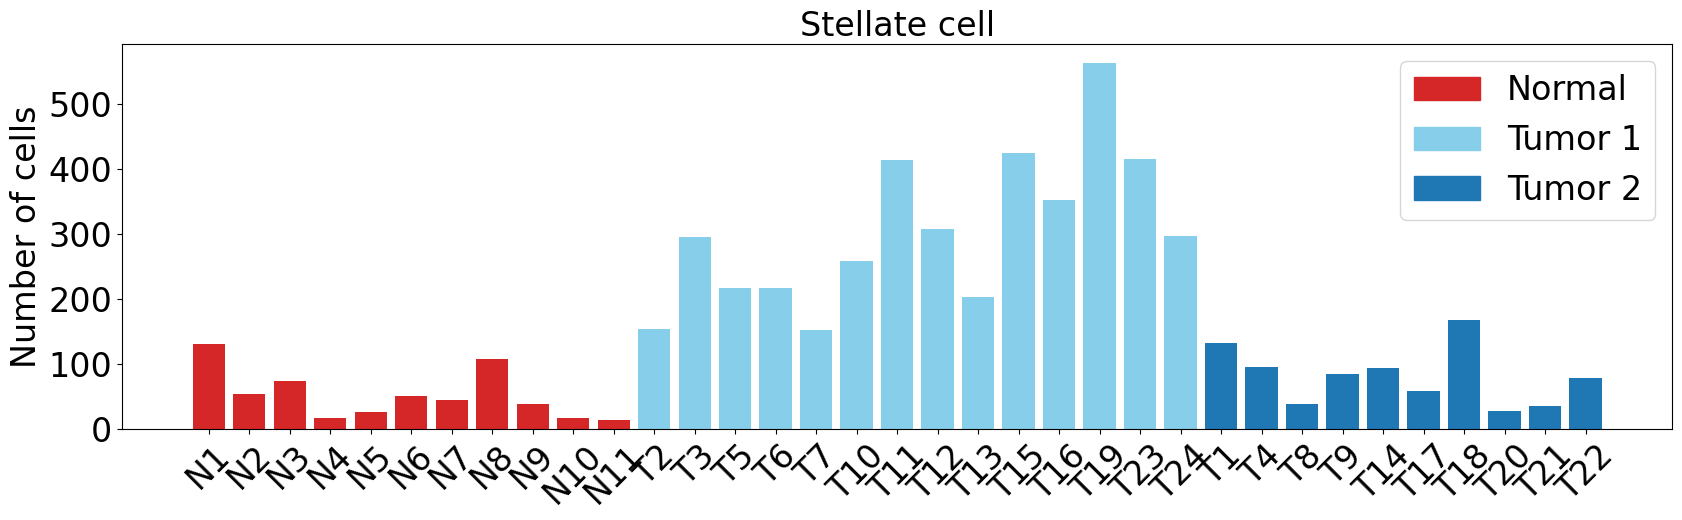

Aggregating the counts and metadata to the sample level...
Use the median of ratios method for count normalization from DESeq2
Use regularized log transform (rlog) of the normalized counts from DESeq2
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::l

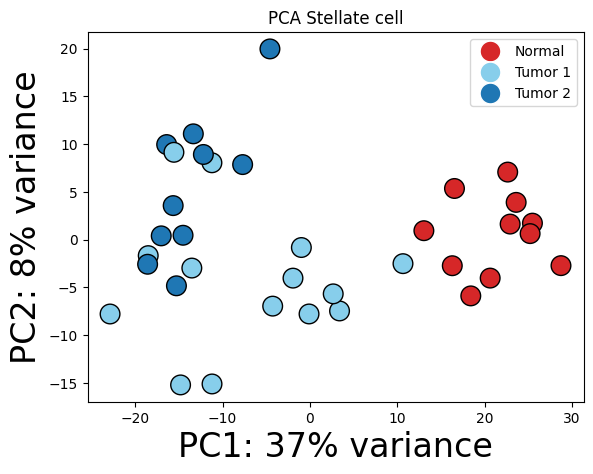

Performing the DE analysis... 
[1] "stage_Tumor.1_vs_Normal"
Plot volcano plot for Tumor 1 vs Normal


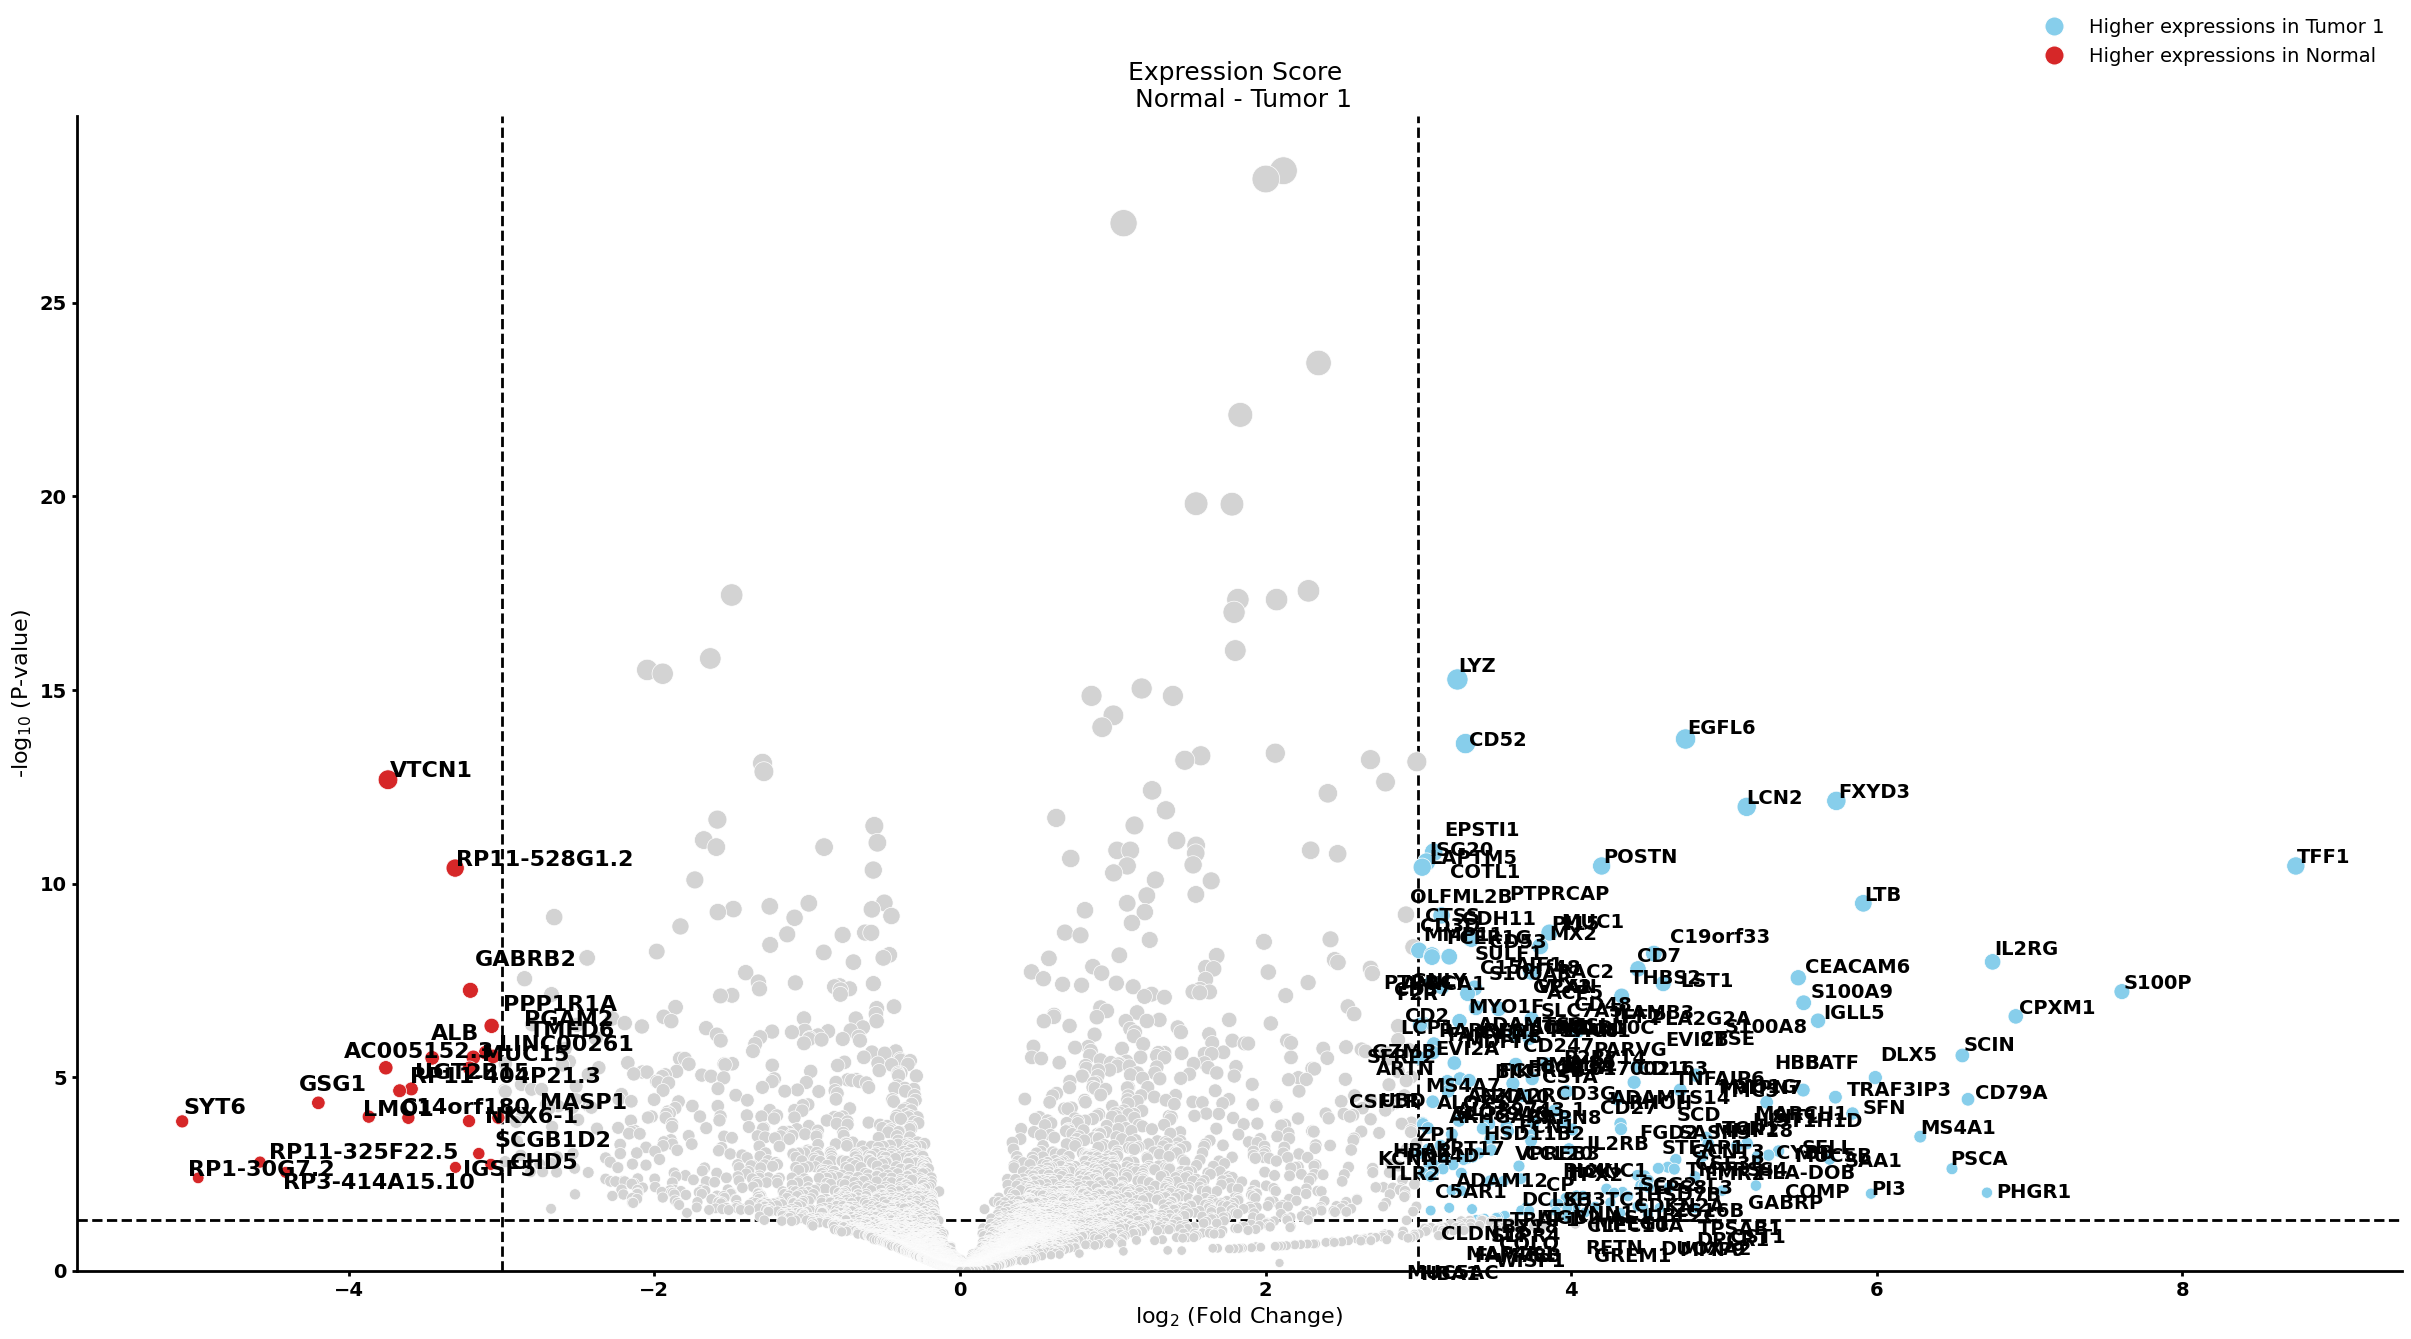

Plot GO analysis for Tumor 1 vs Normal


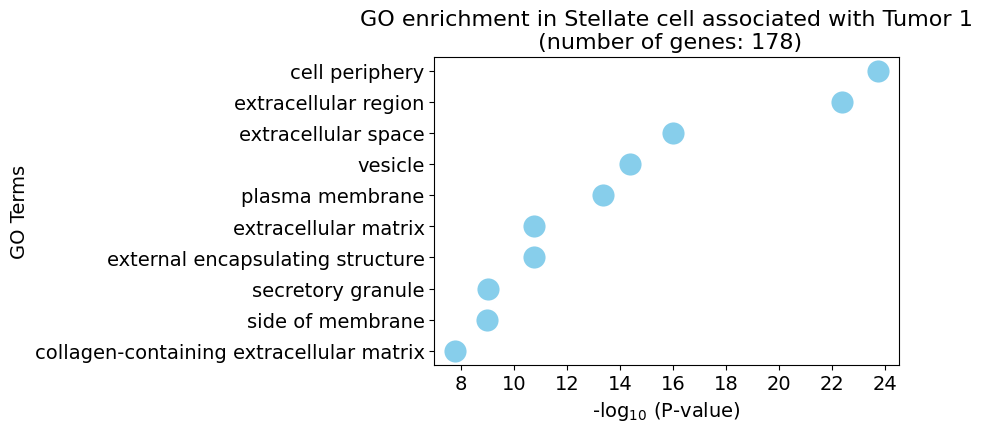

[1] "stage_Tumor.2_vs_Normal"
Plot volcano plot for Tumor 2 vs Normal


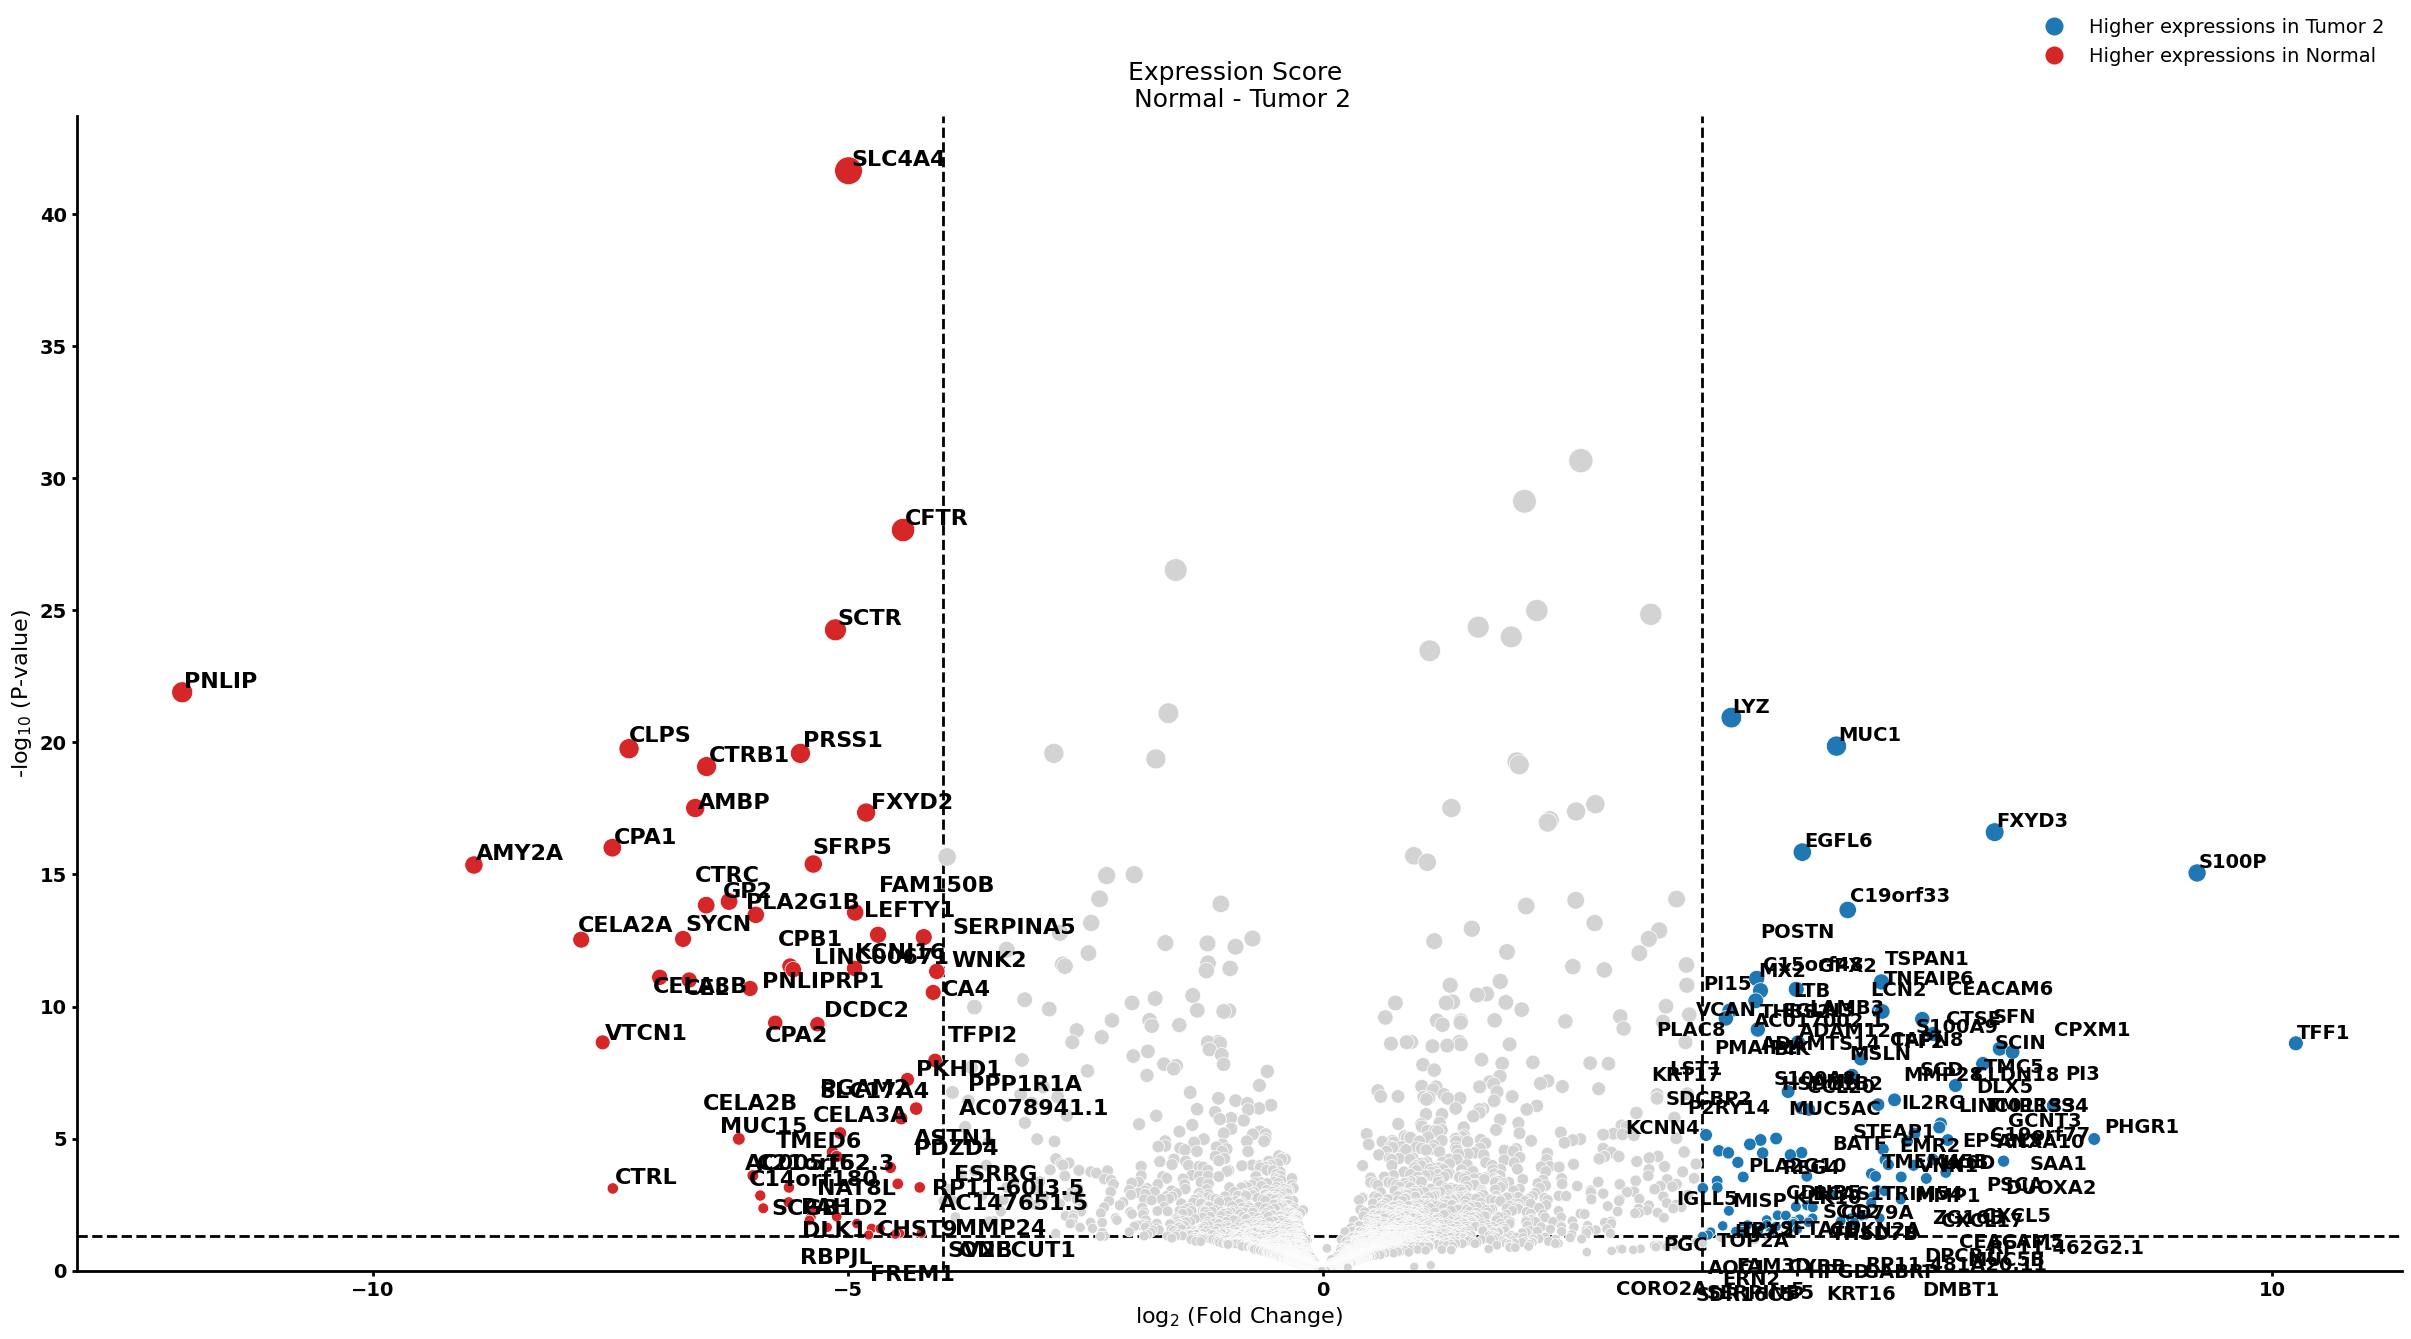

Plot GO analysis for Tumor 2 vs Normal


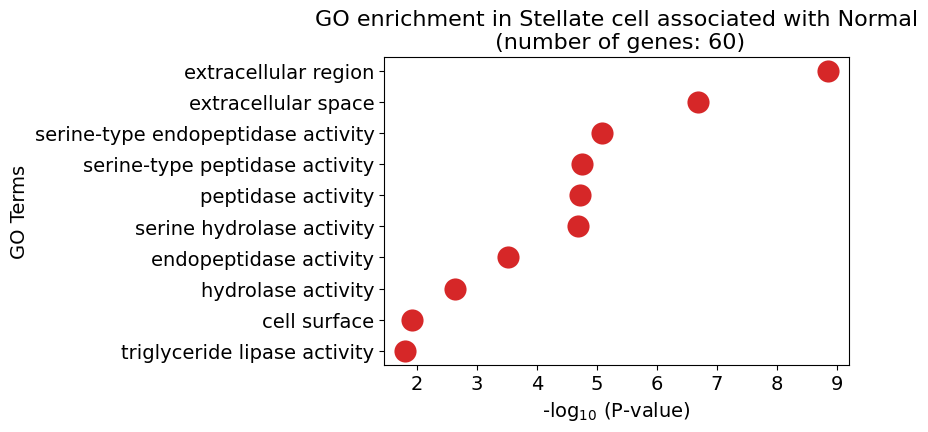

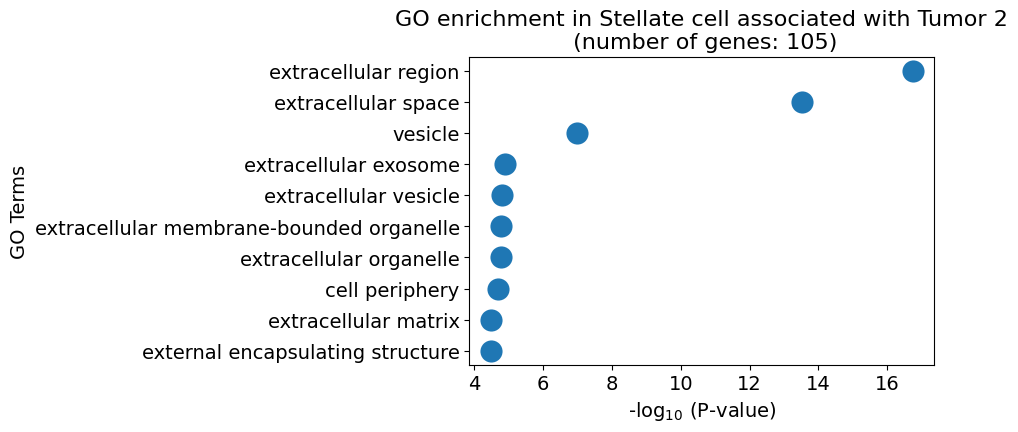

[1] "stage_Tumor.2_vs_Tumor.1"
Plot volcano plot for Tumor 2 vs Tumor 1


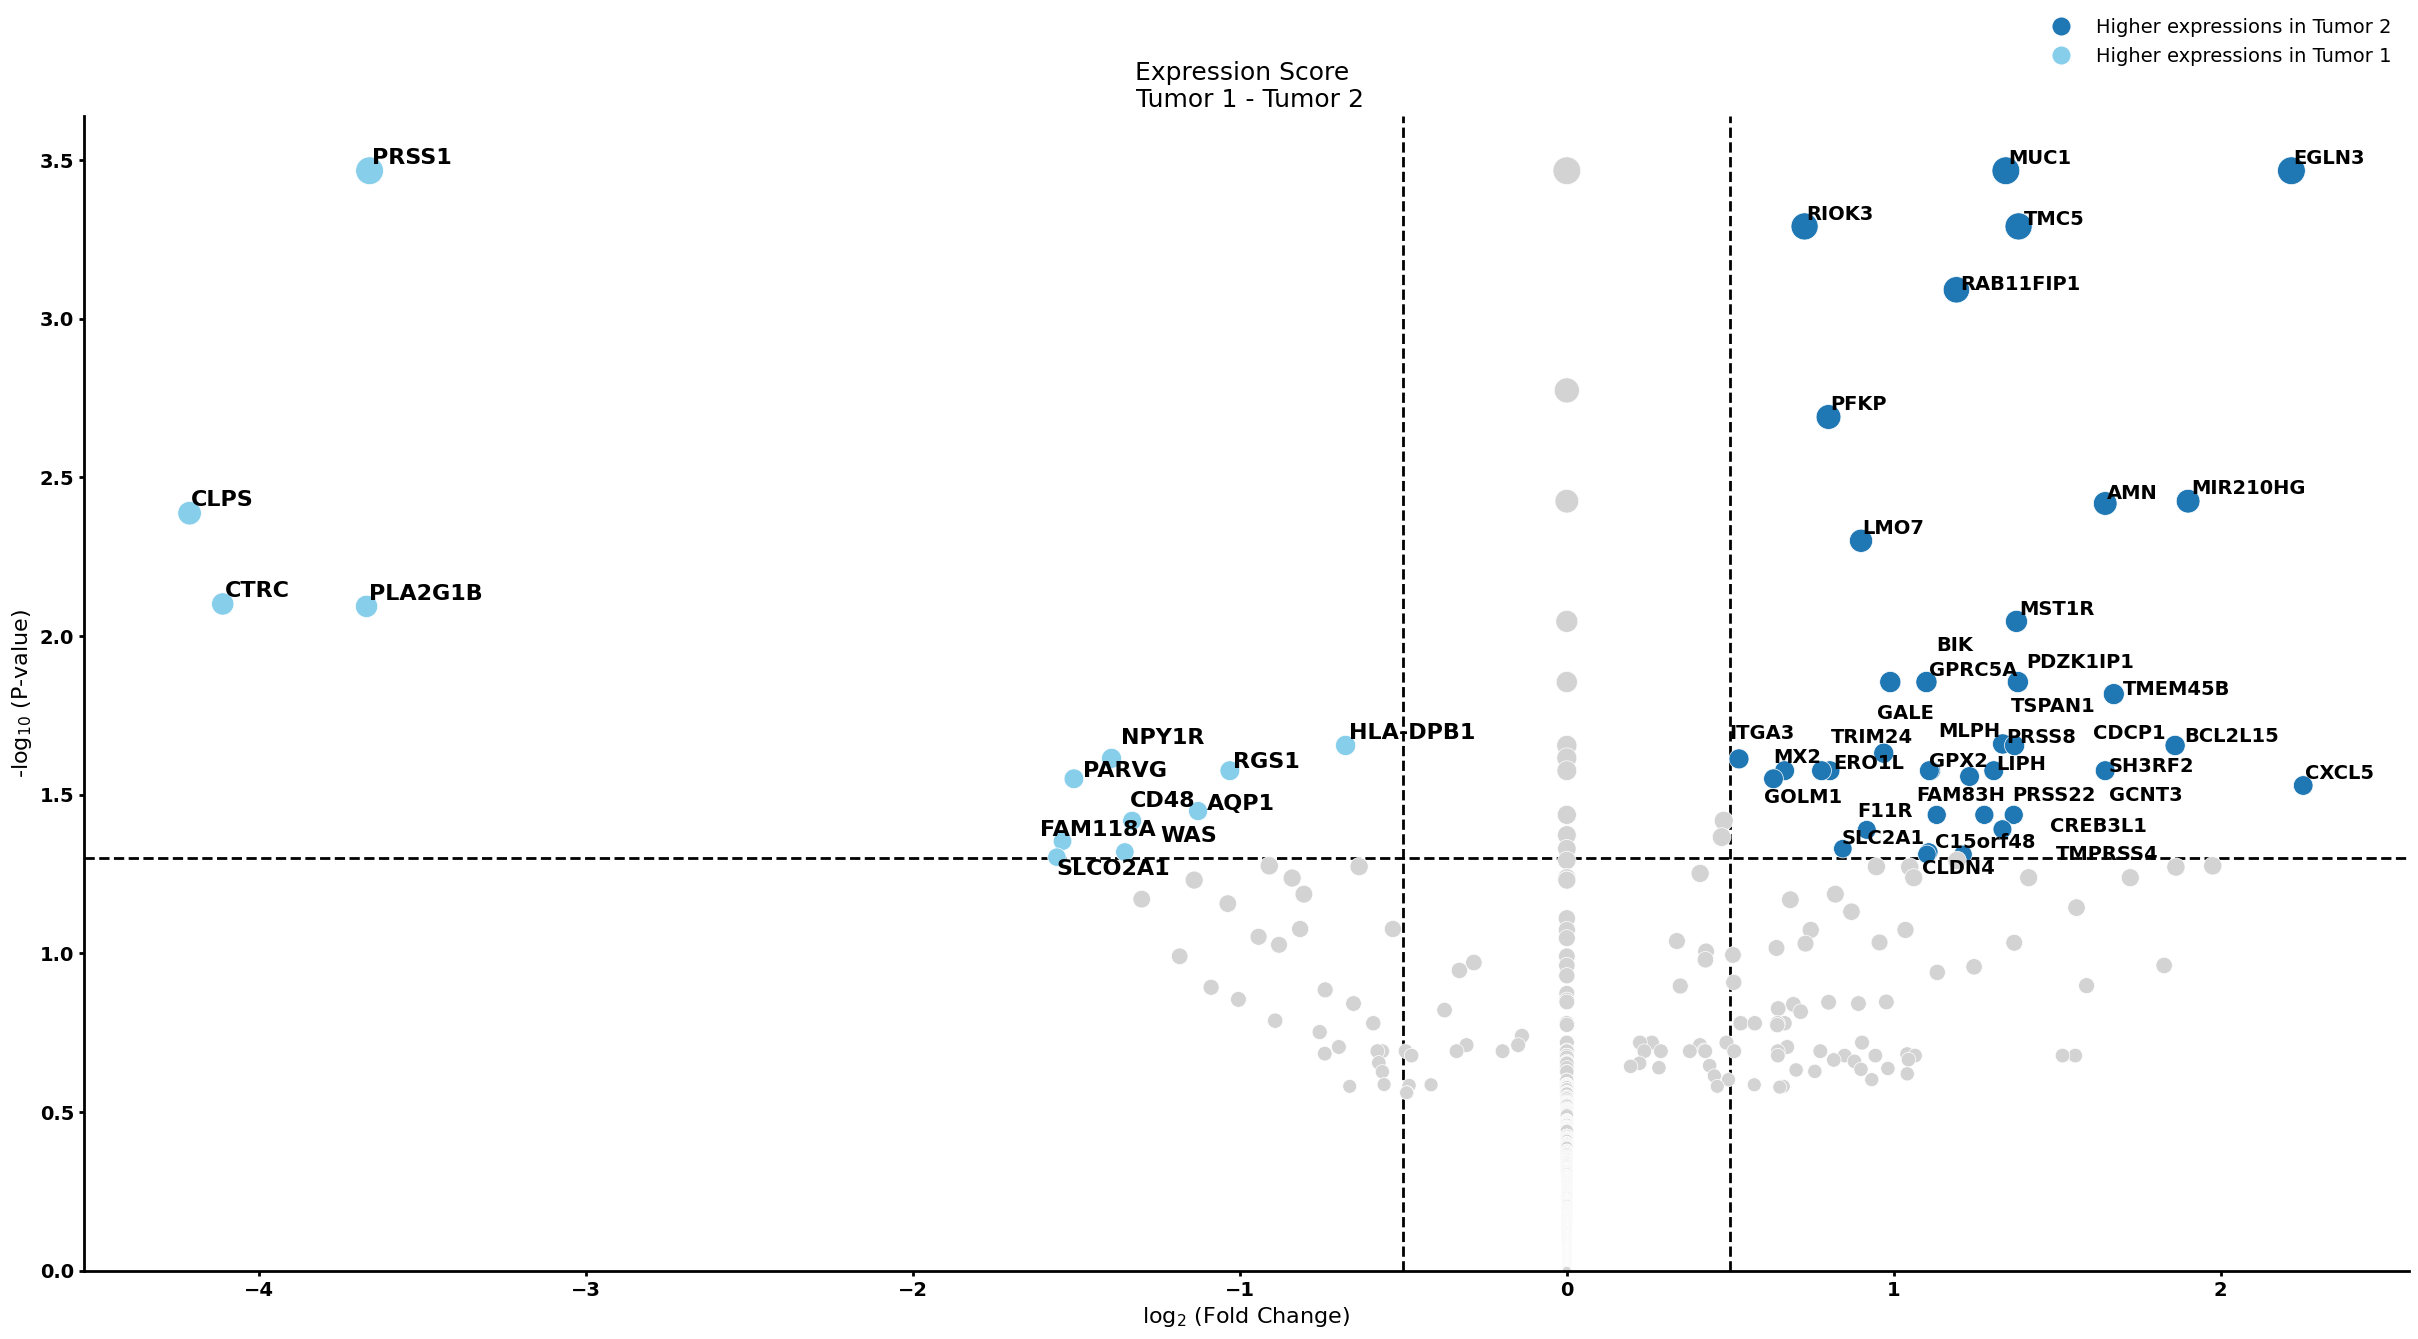

Plot GO analysis for Tumor 2 vs Tumor 1


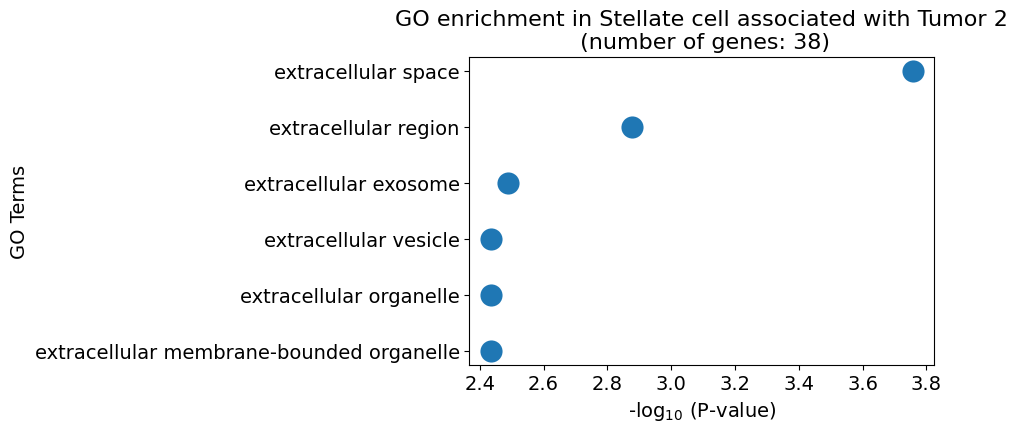

In [15]:
pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Stellate cell', fc_thr = [3.0, 4.0, 0.5])

Plot cells frequency for each sample... 


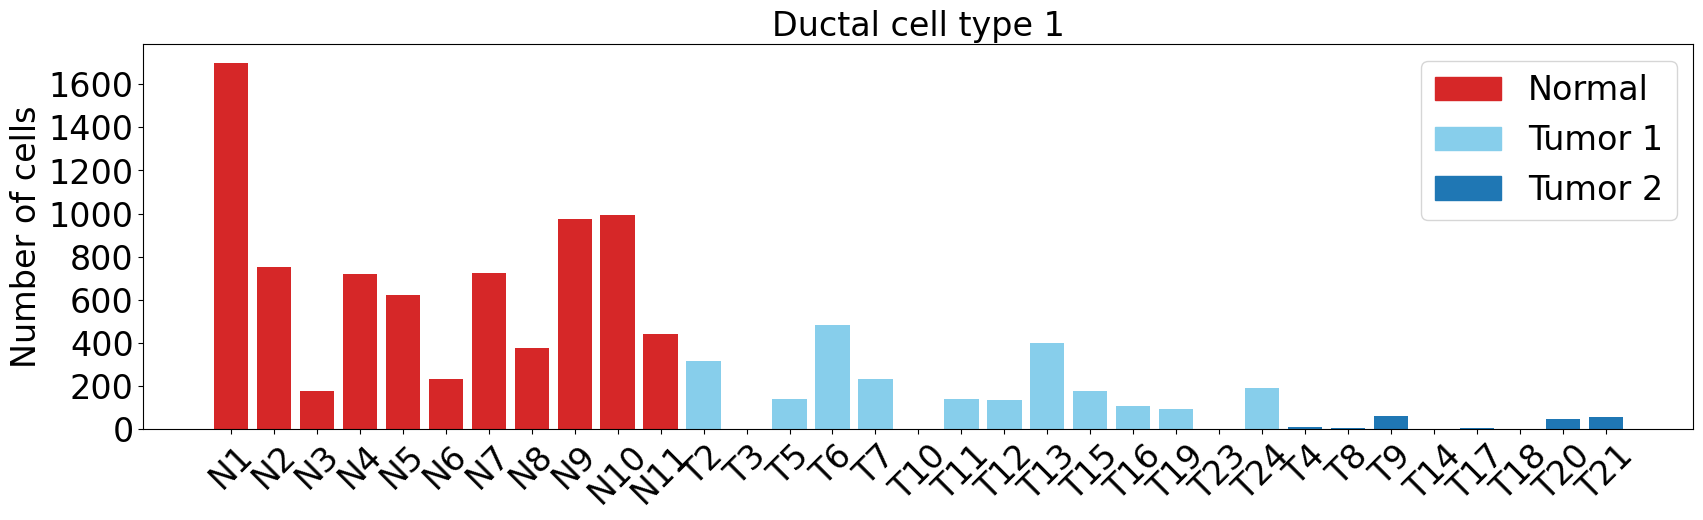

Plot the first two principal components... 


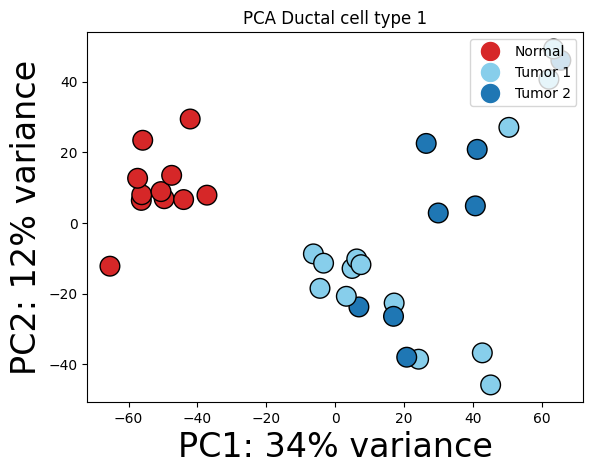

Performing the DE analysis... 
Plot volcano plot for Tumor 1 vs Normal


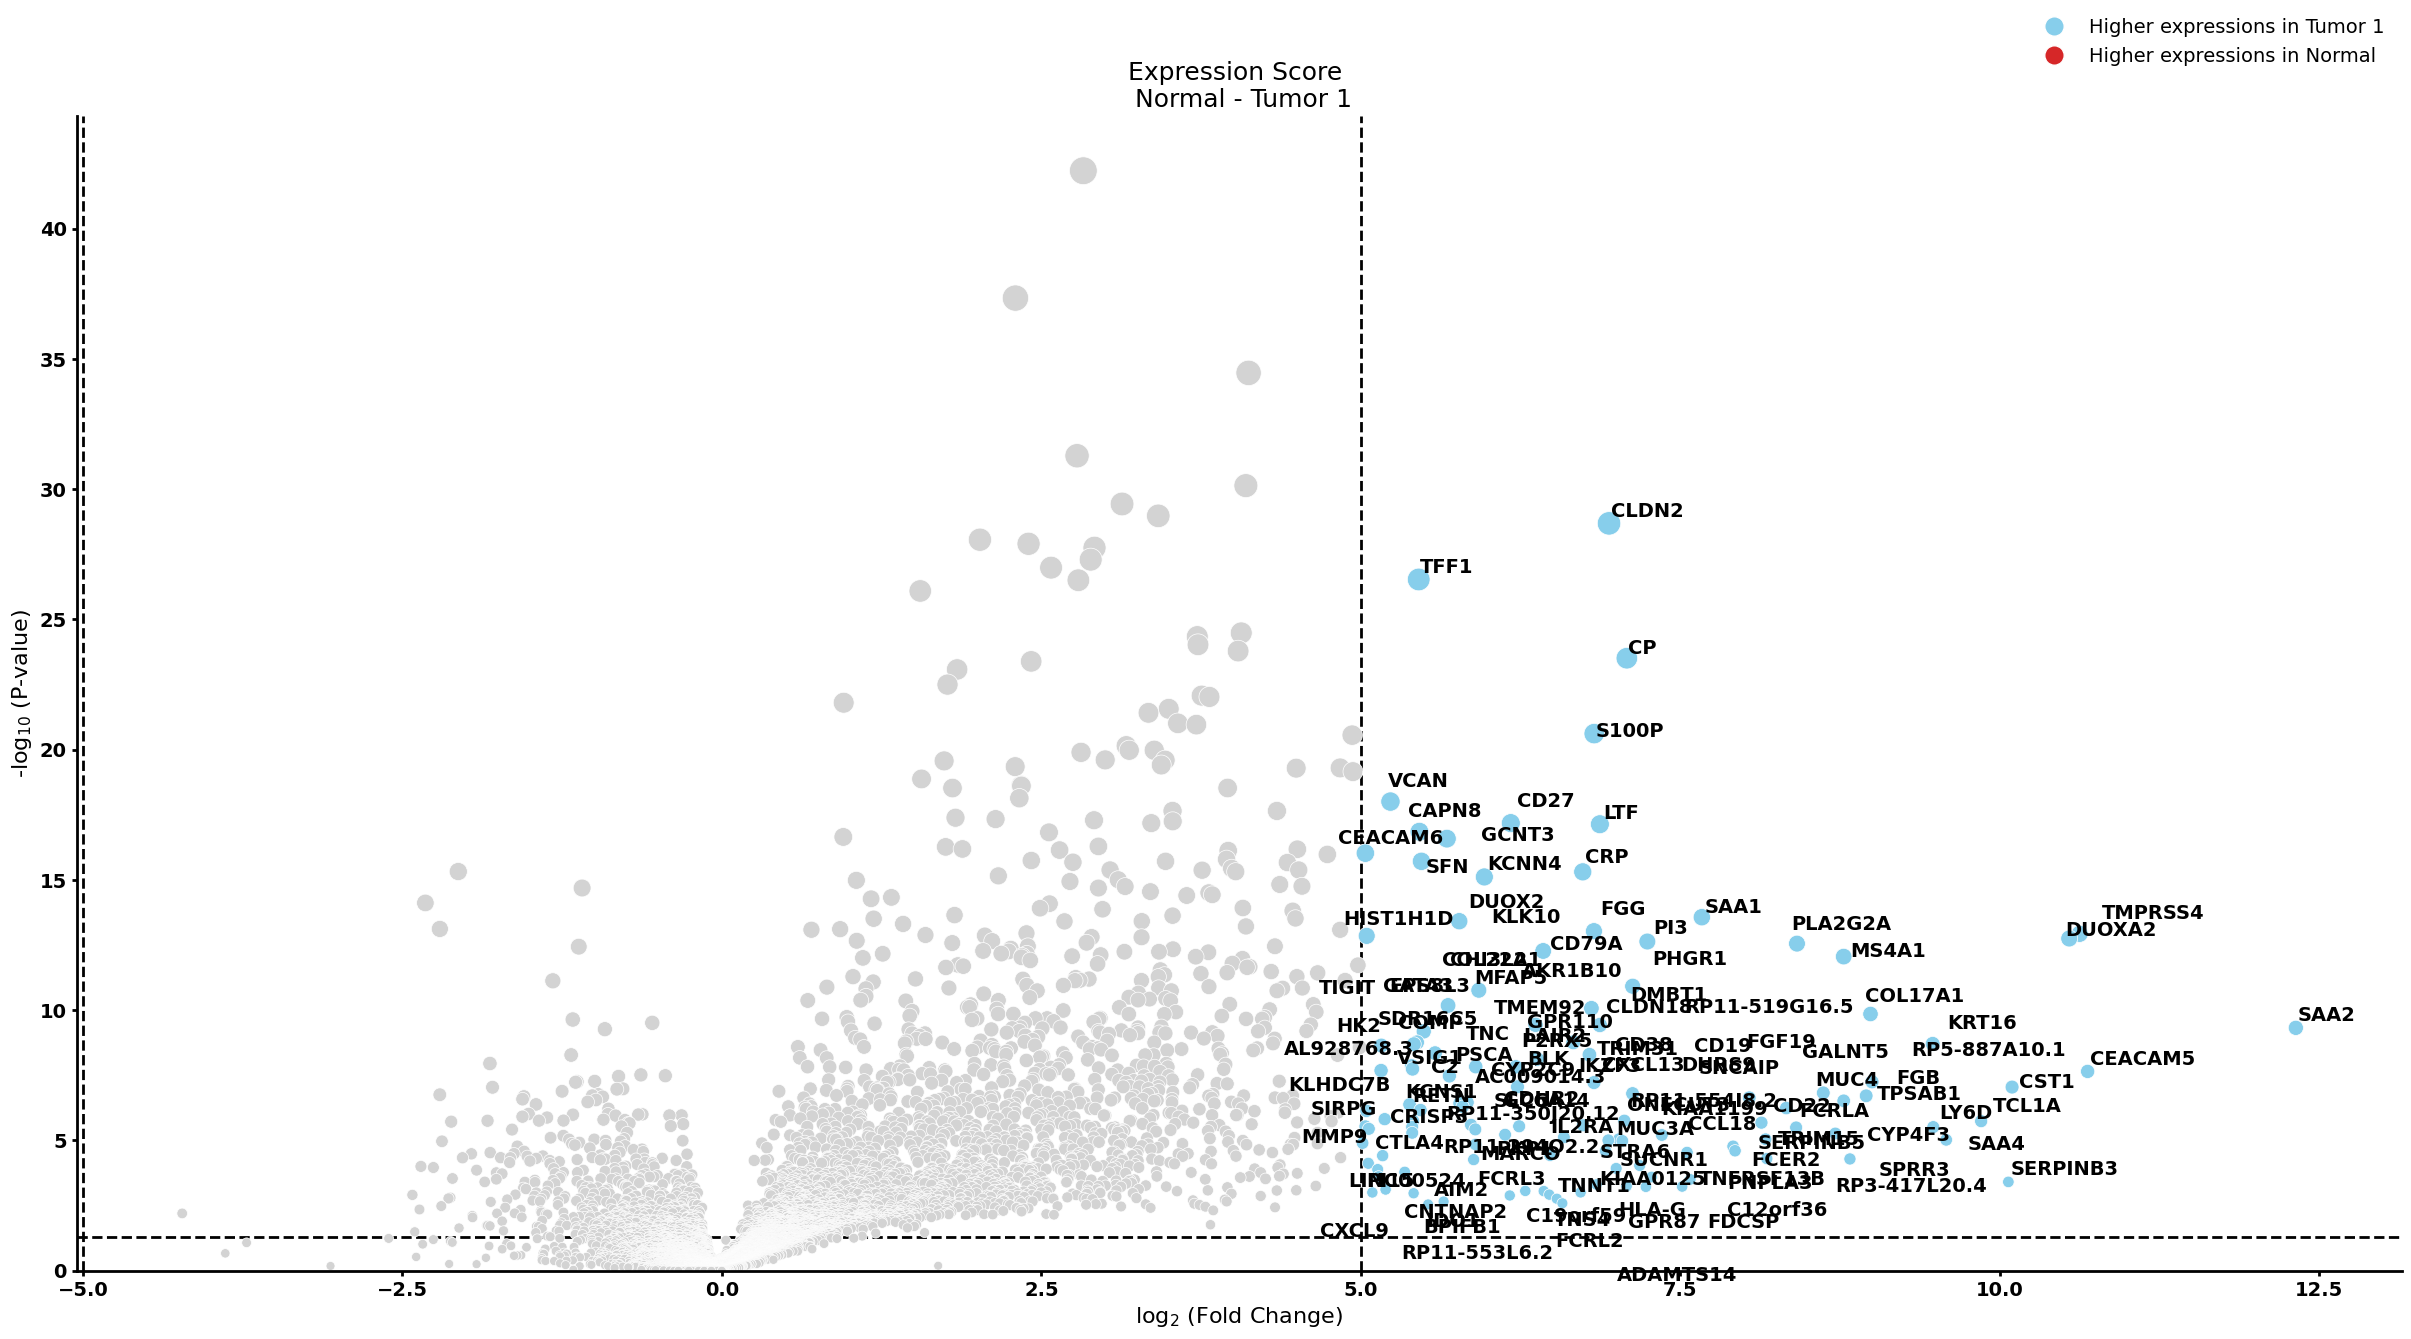

Plot GO analysis for Tumor 1 vs Normal


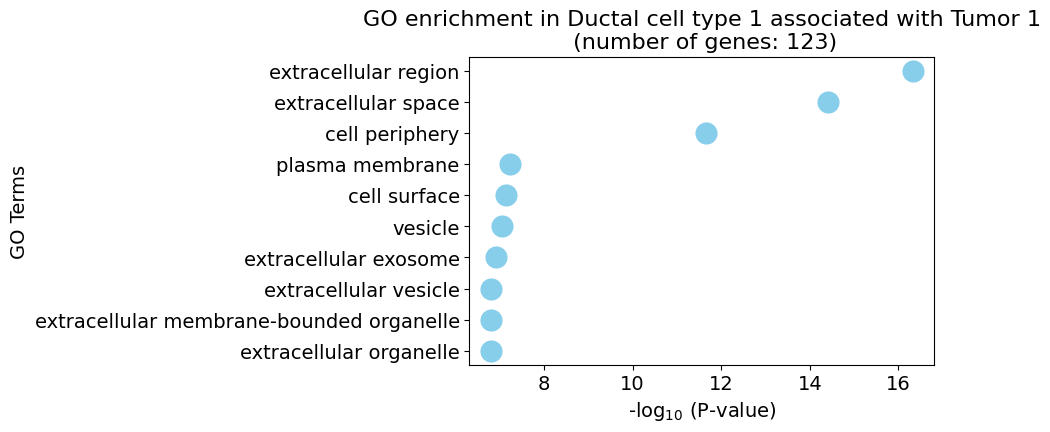

Plot volcano plot for Tumor 2 vs Normal


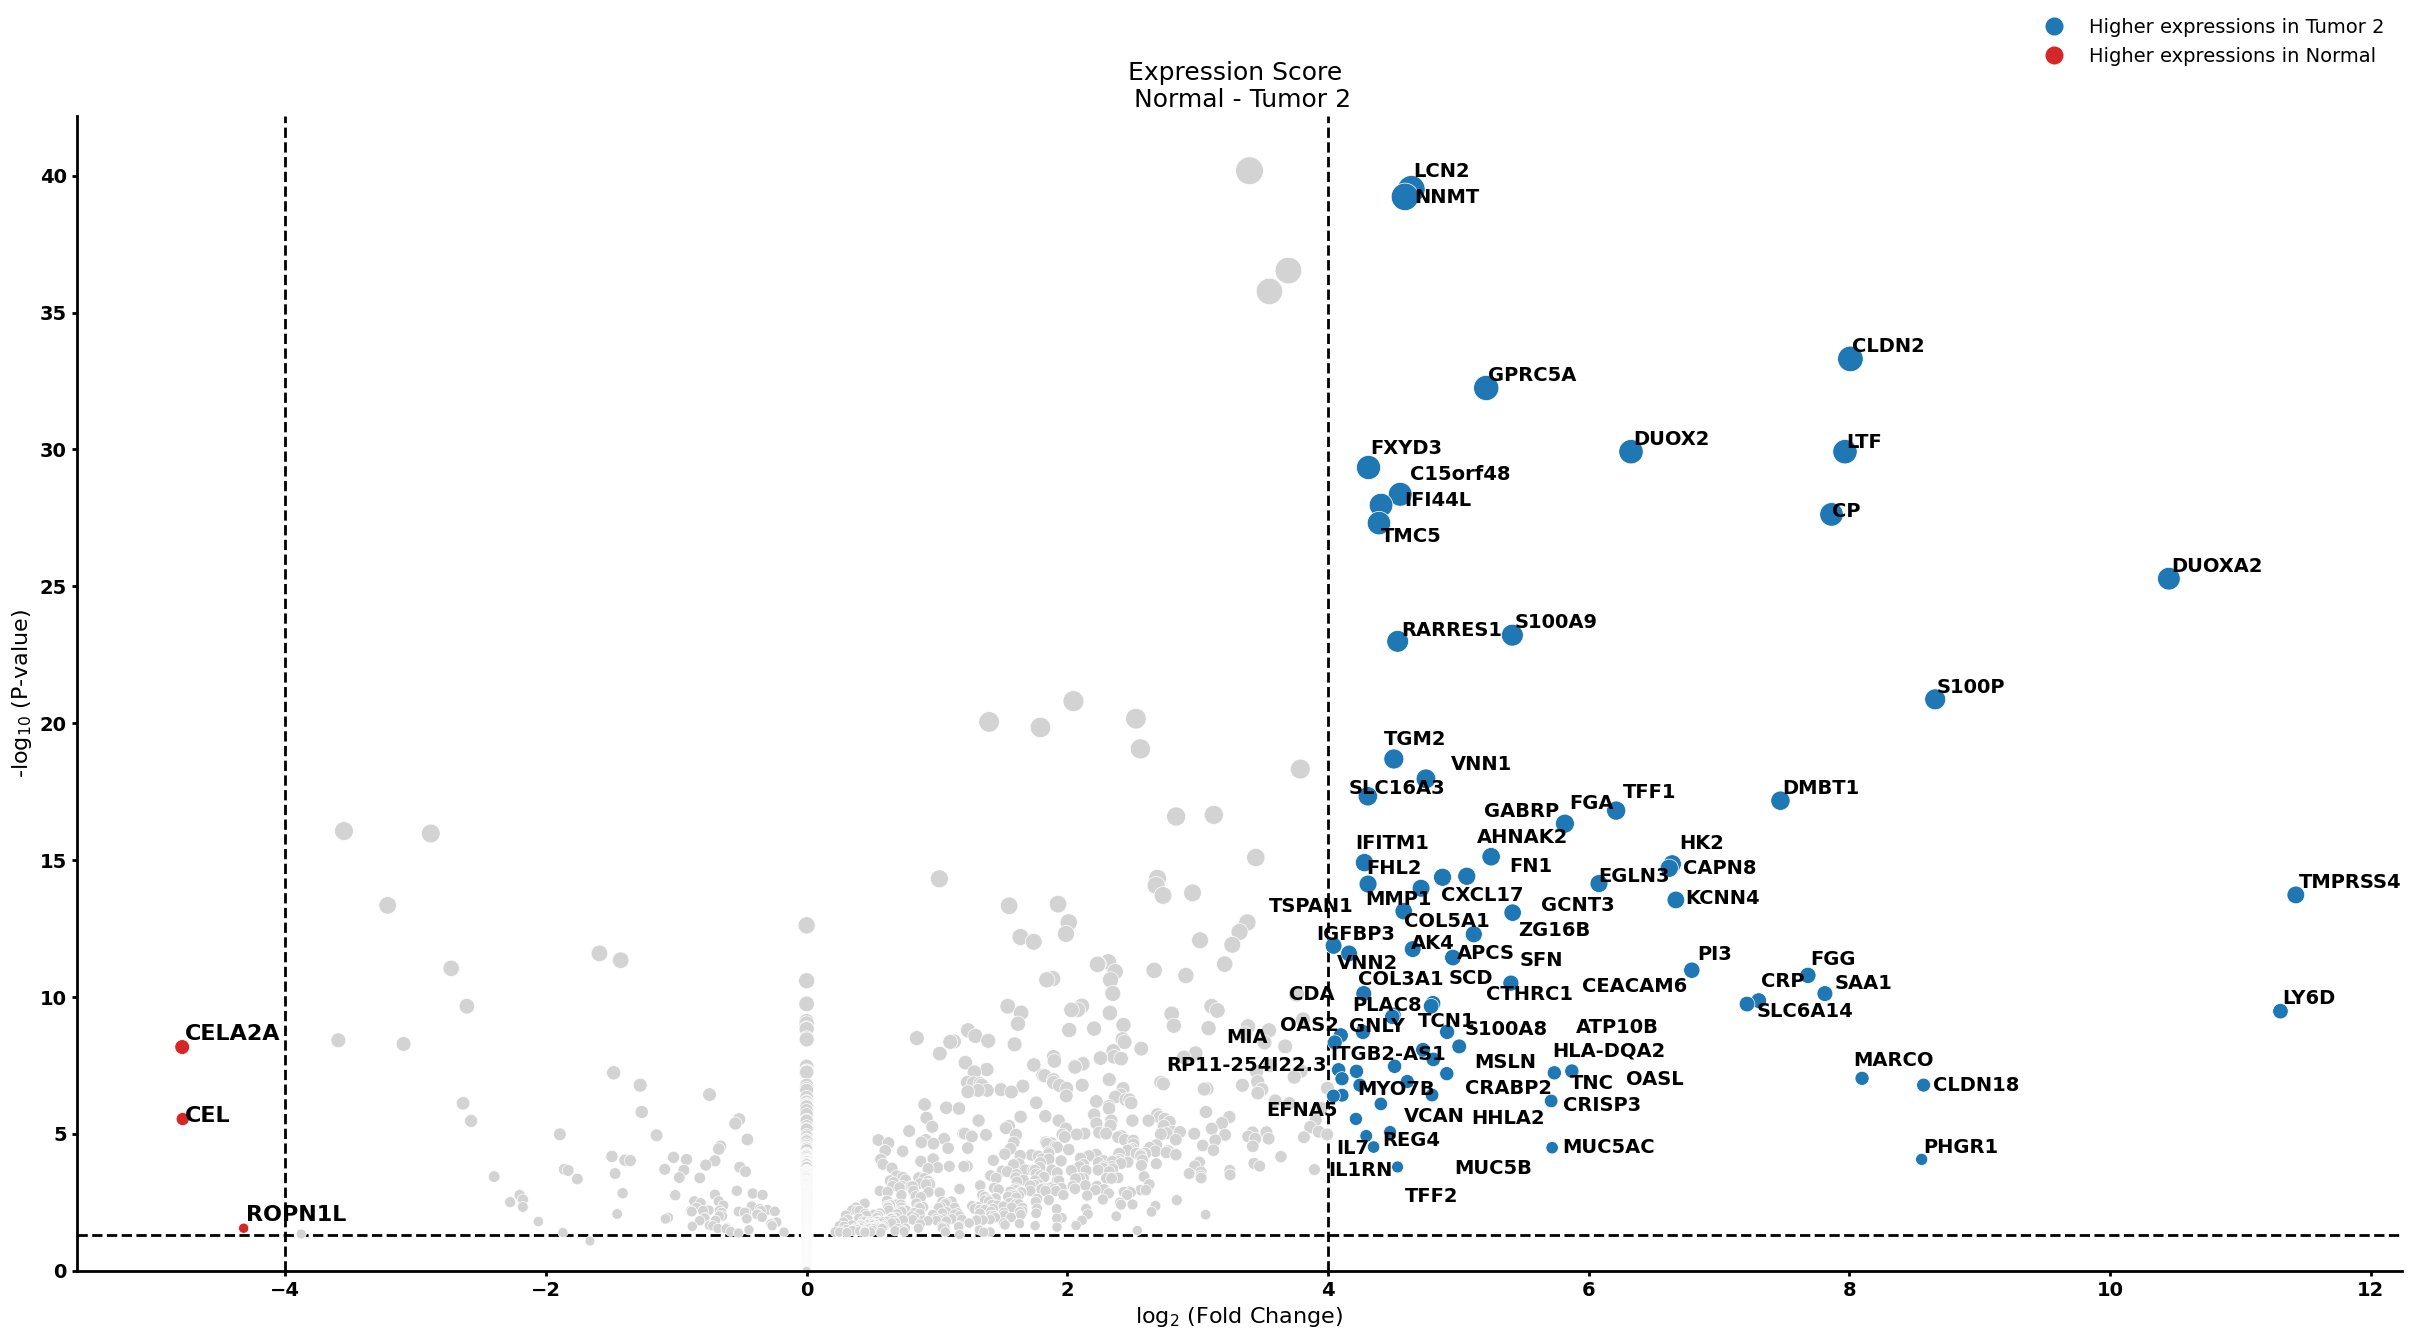

Plot GO analysis for Tumor 2 vs Normal


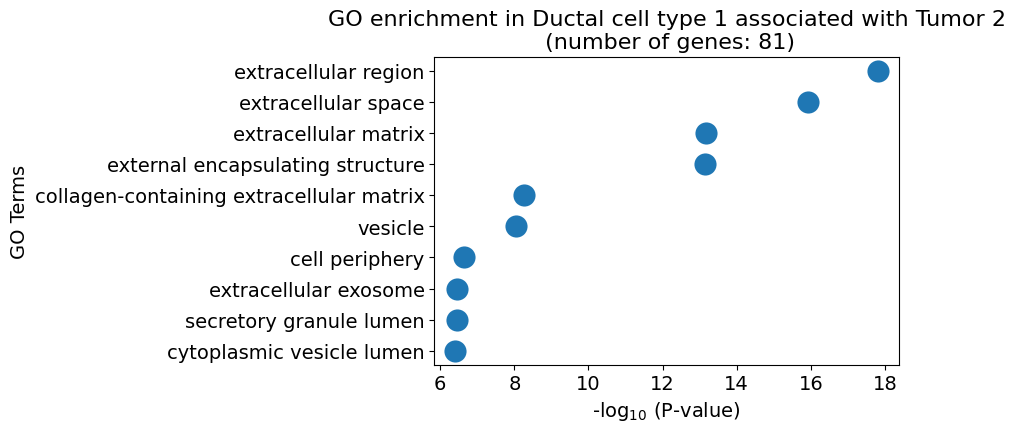

Plot volcano plot for Tumor 2 vs Tumor 1


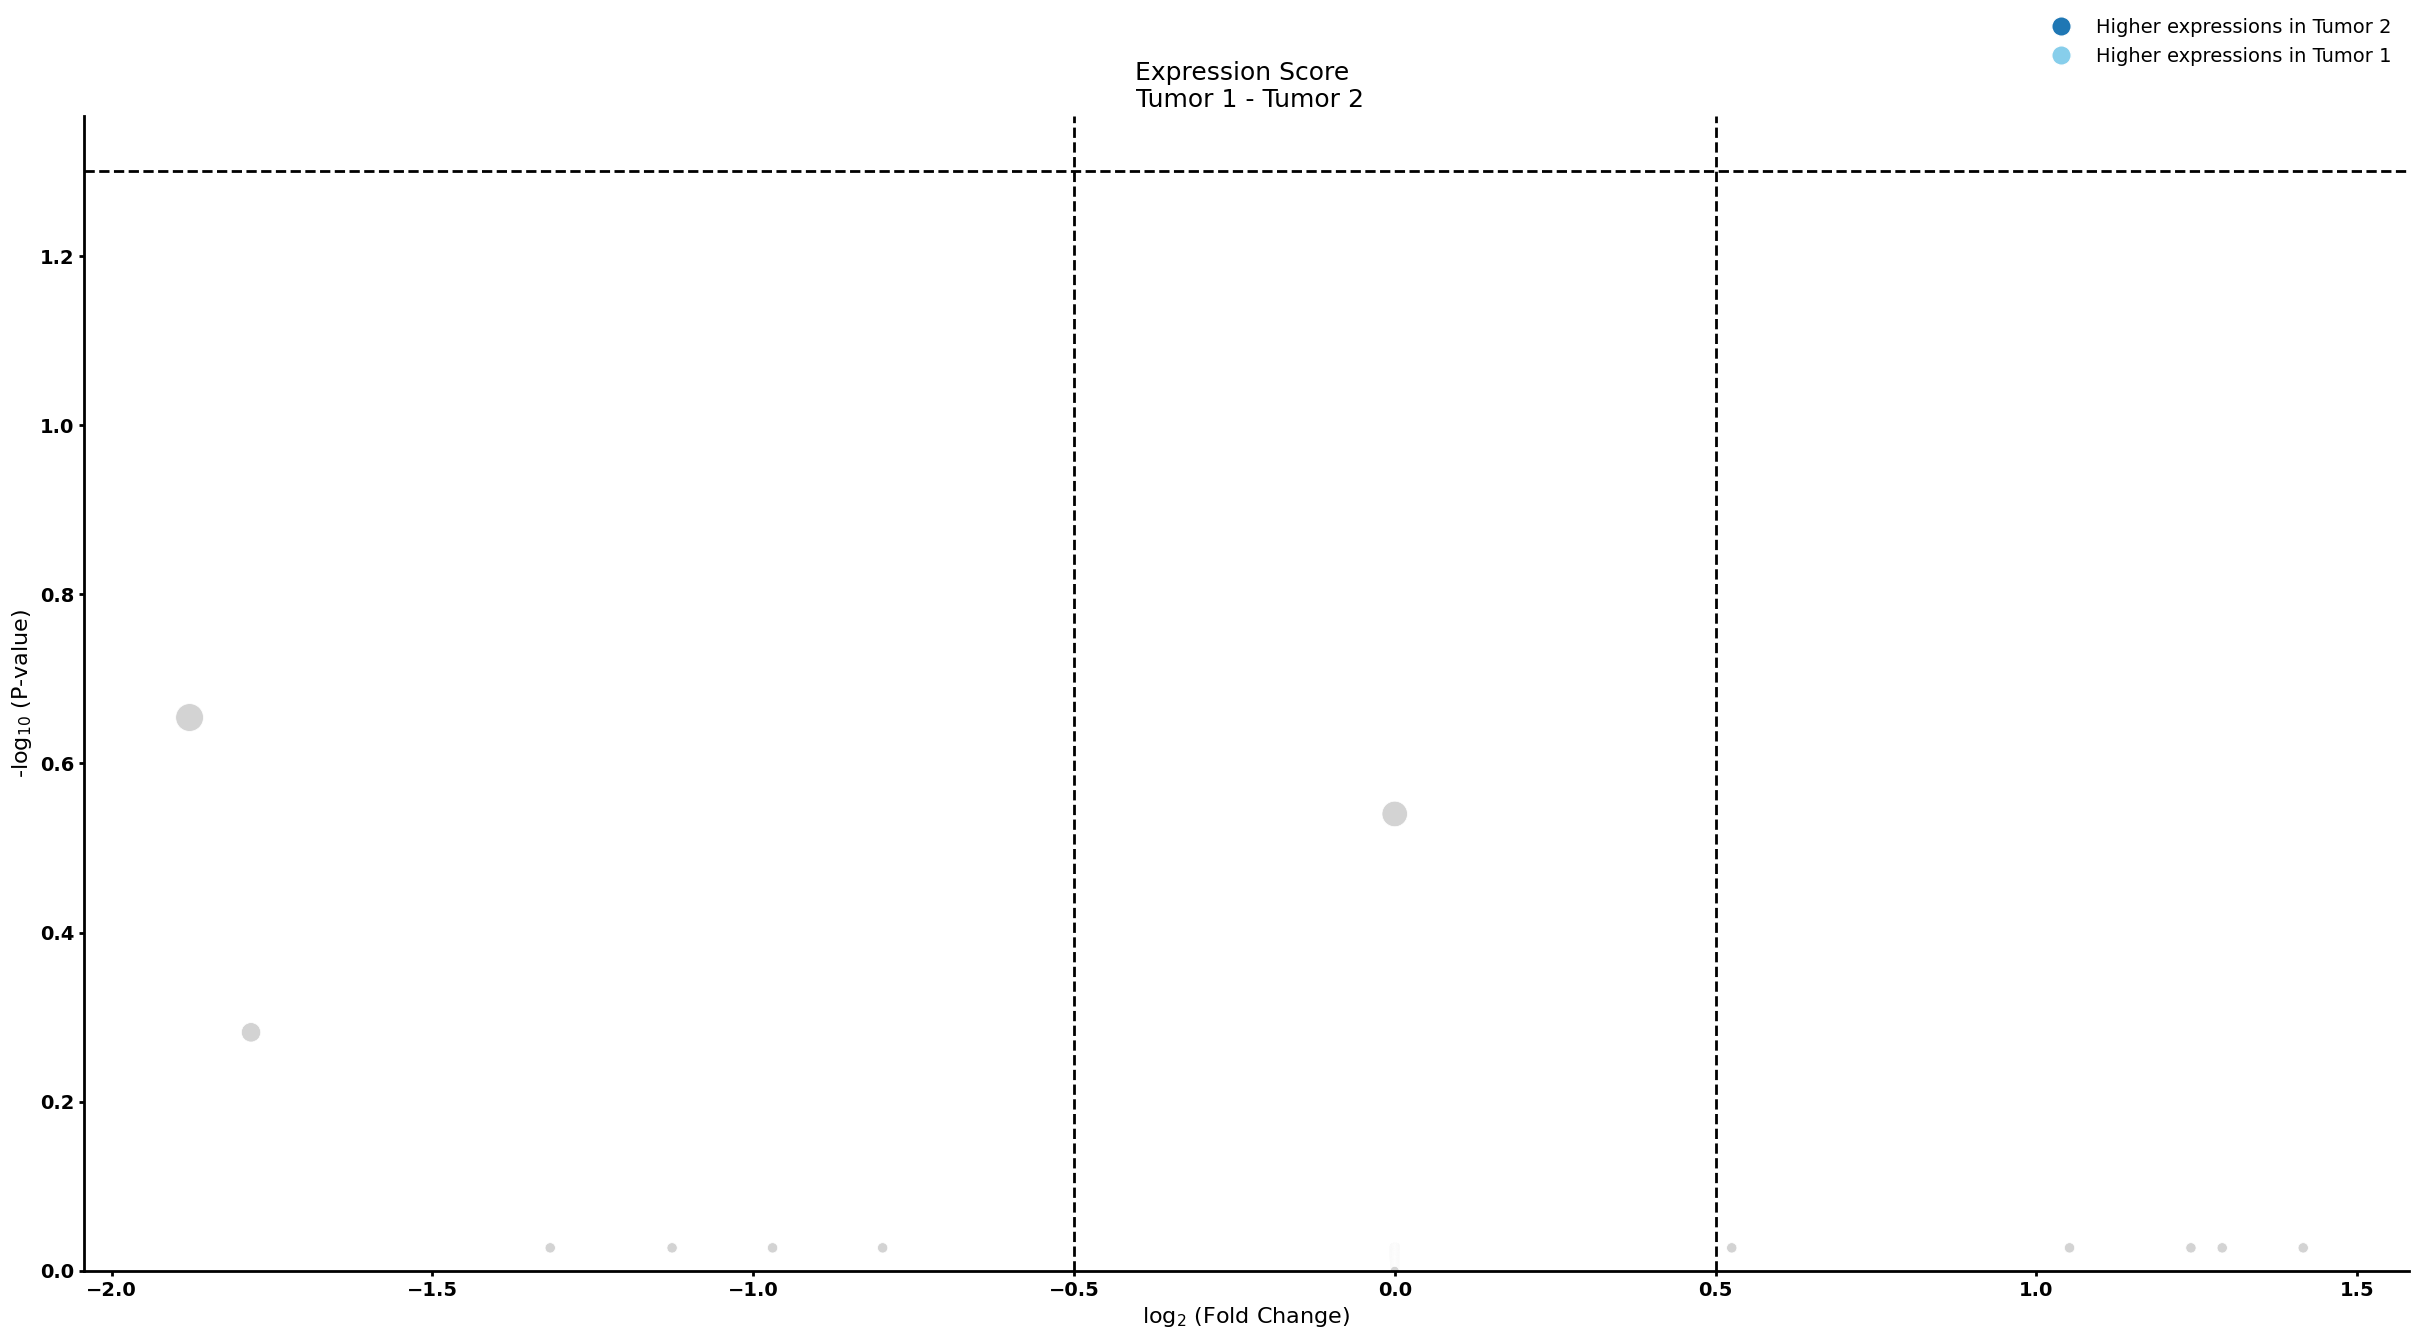

Plot GO analysis for Tumor 2 vs Tumor 1


In [12]:
pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Ductal cell type 1', fc_thr = [5.0, 4.0, 0.5])

Plot cells frequency for each sample... 


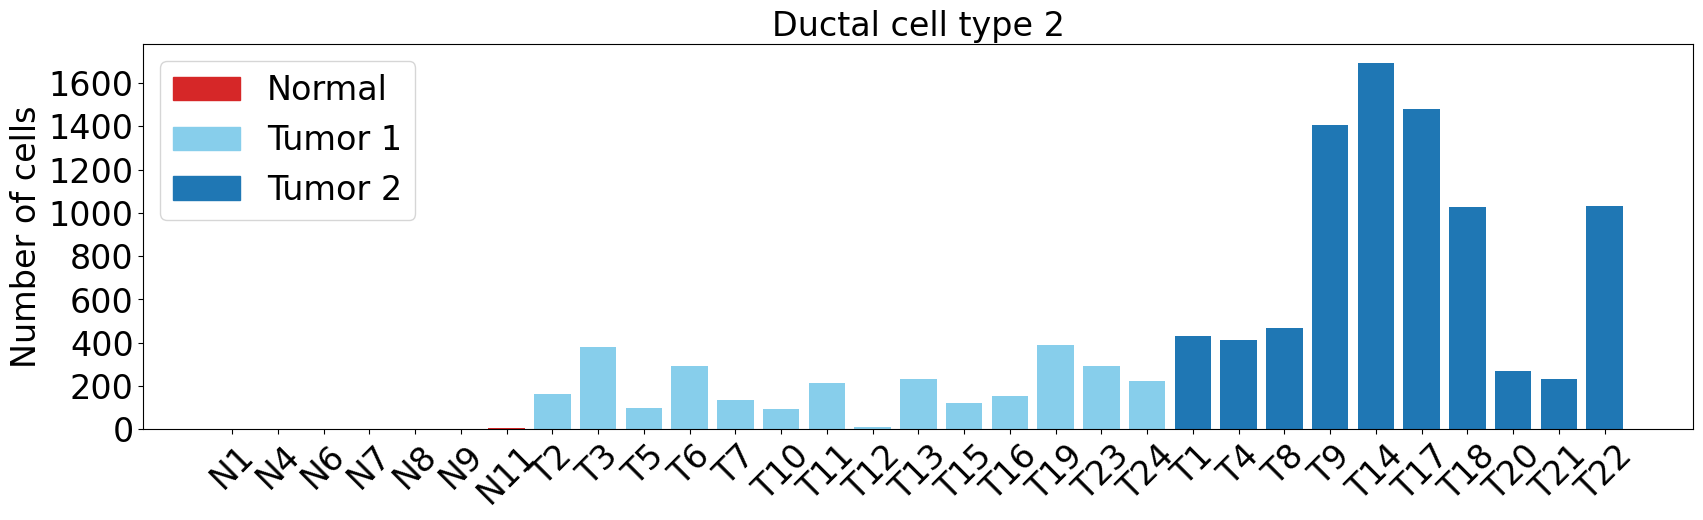

Plot the first two principal components... 


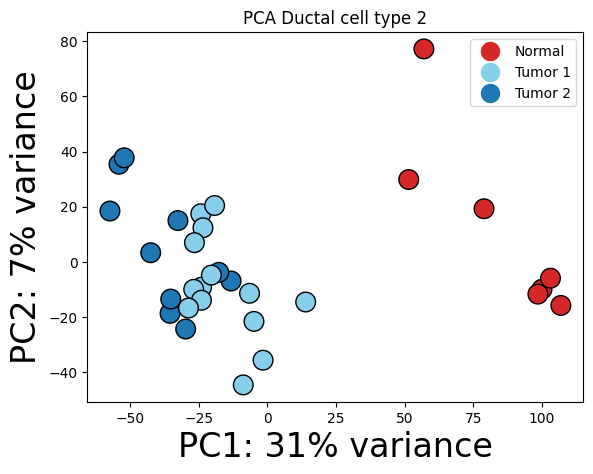

Performing the DE analysis... 
Plot volcano plot for Tumor 1 vs Normal


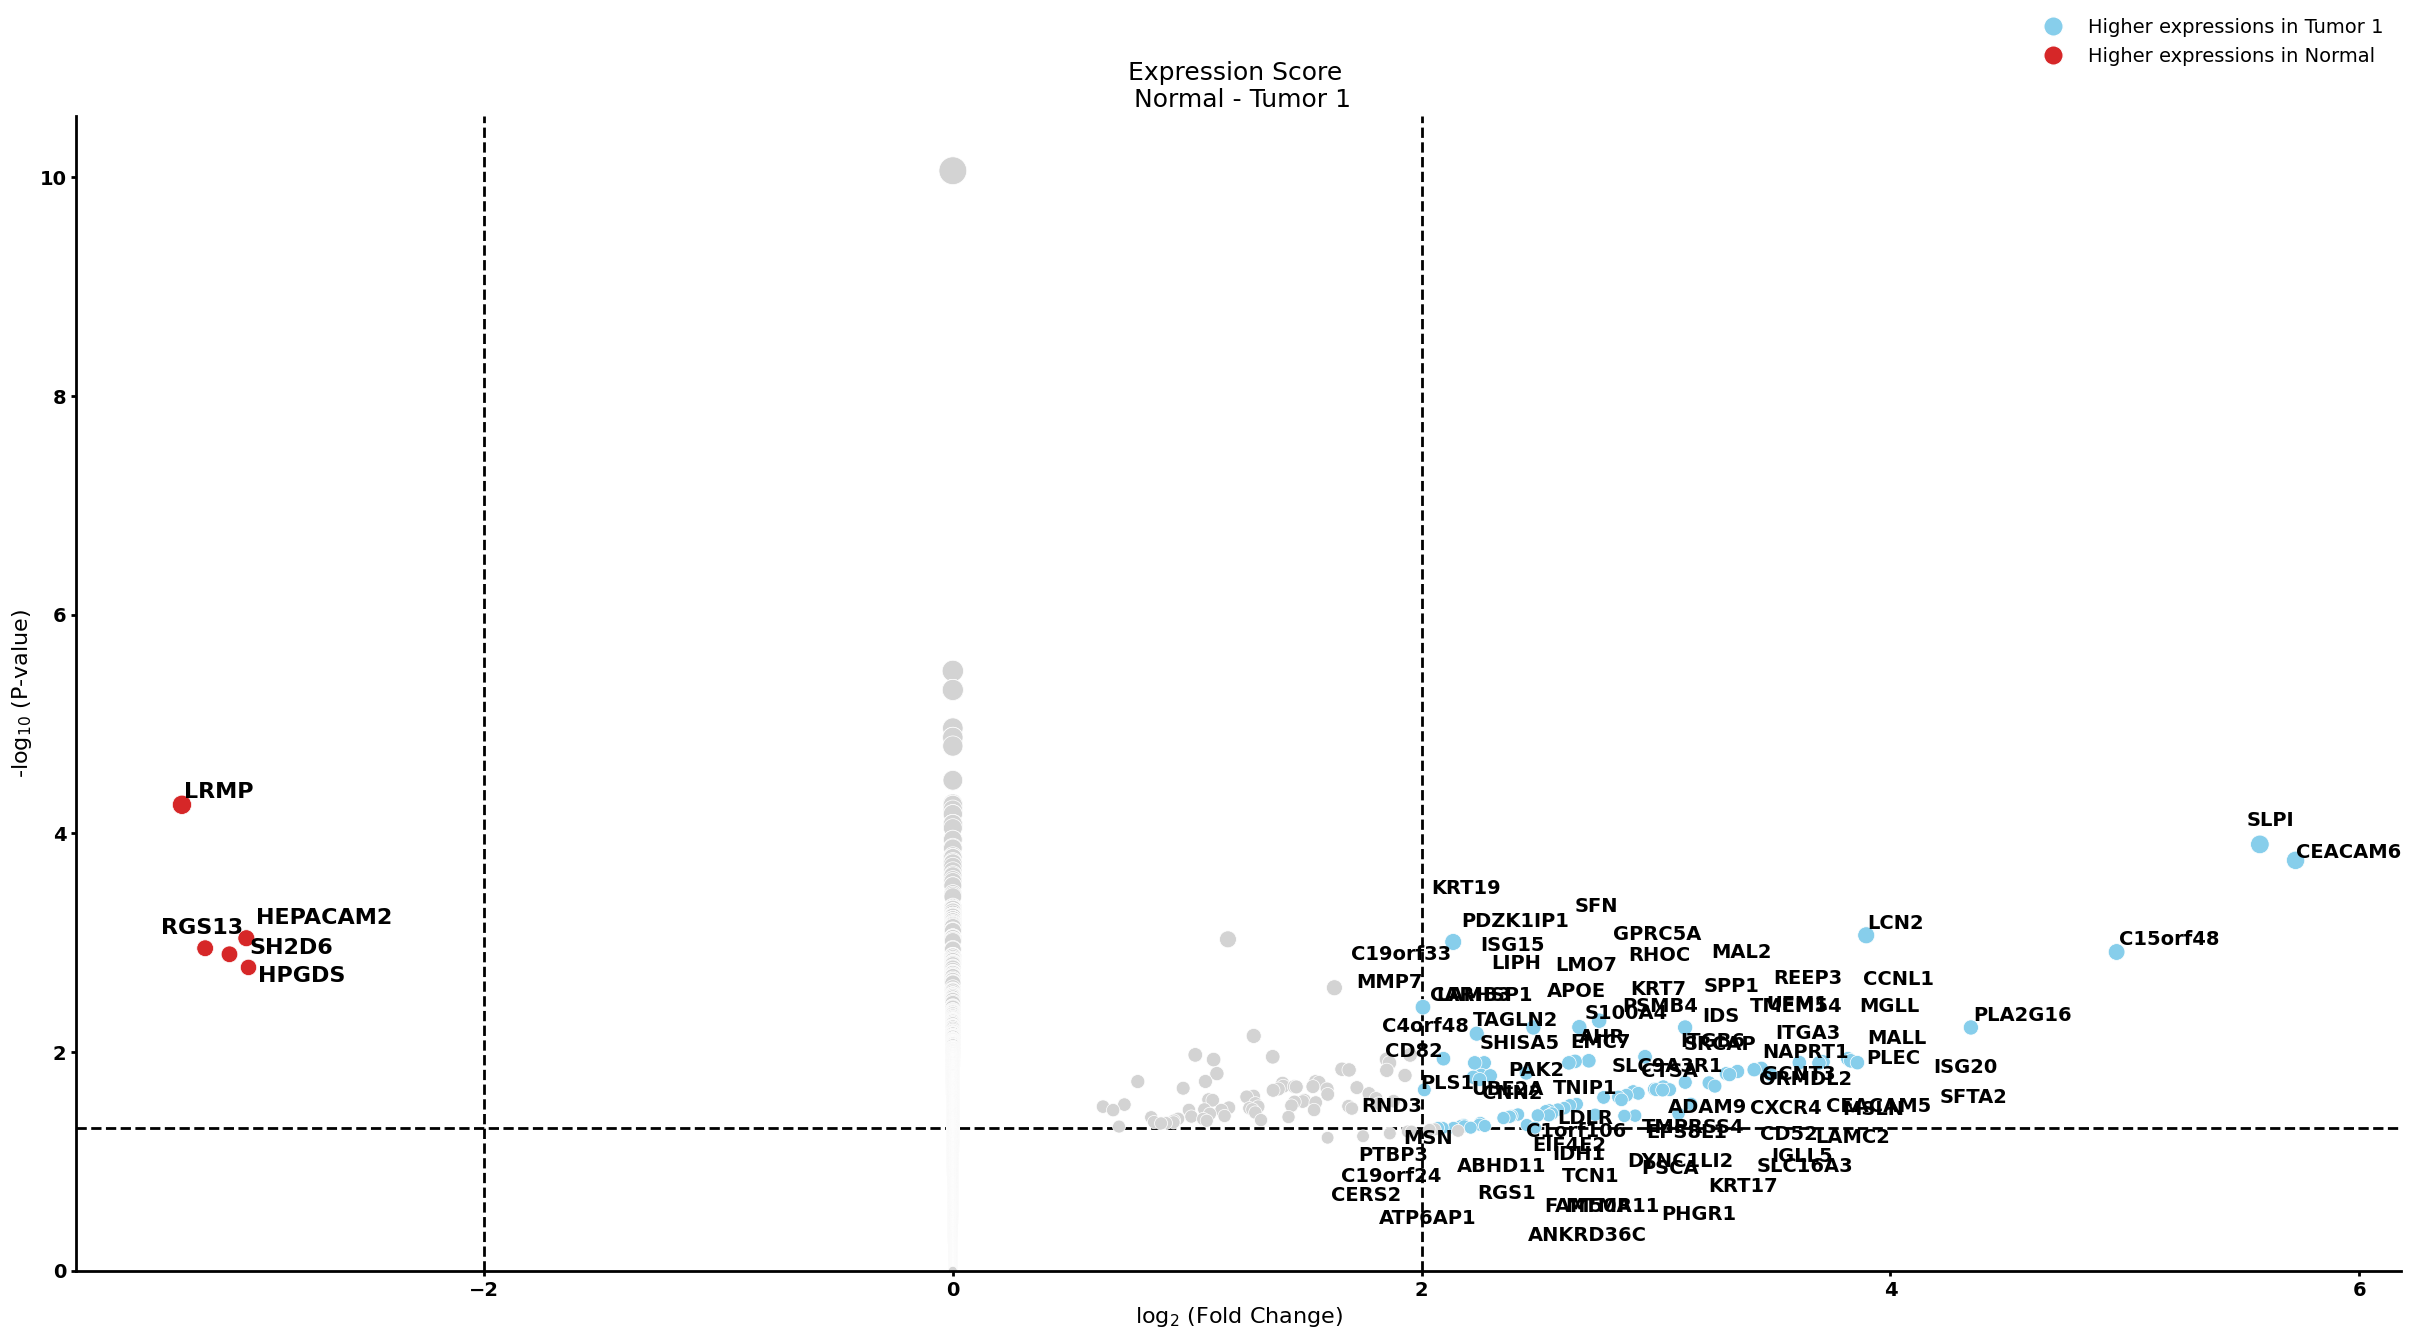

Plot GO analysis for Tumor 1 vs Normal


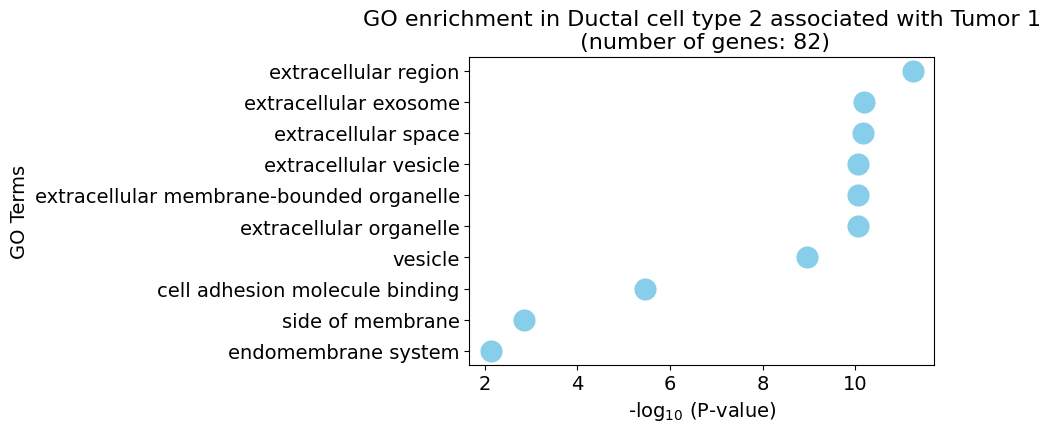

Plot volcano plot for Tumor 2 vs Normal


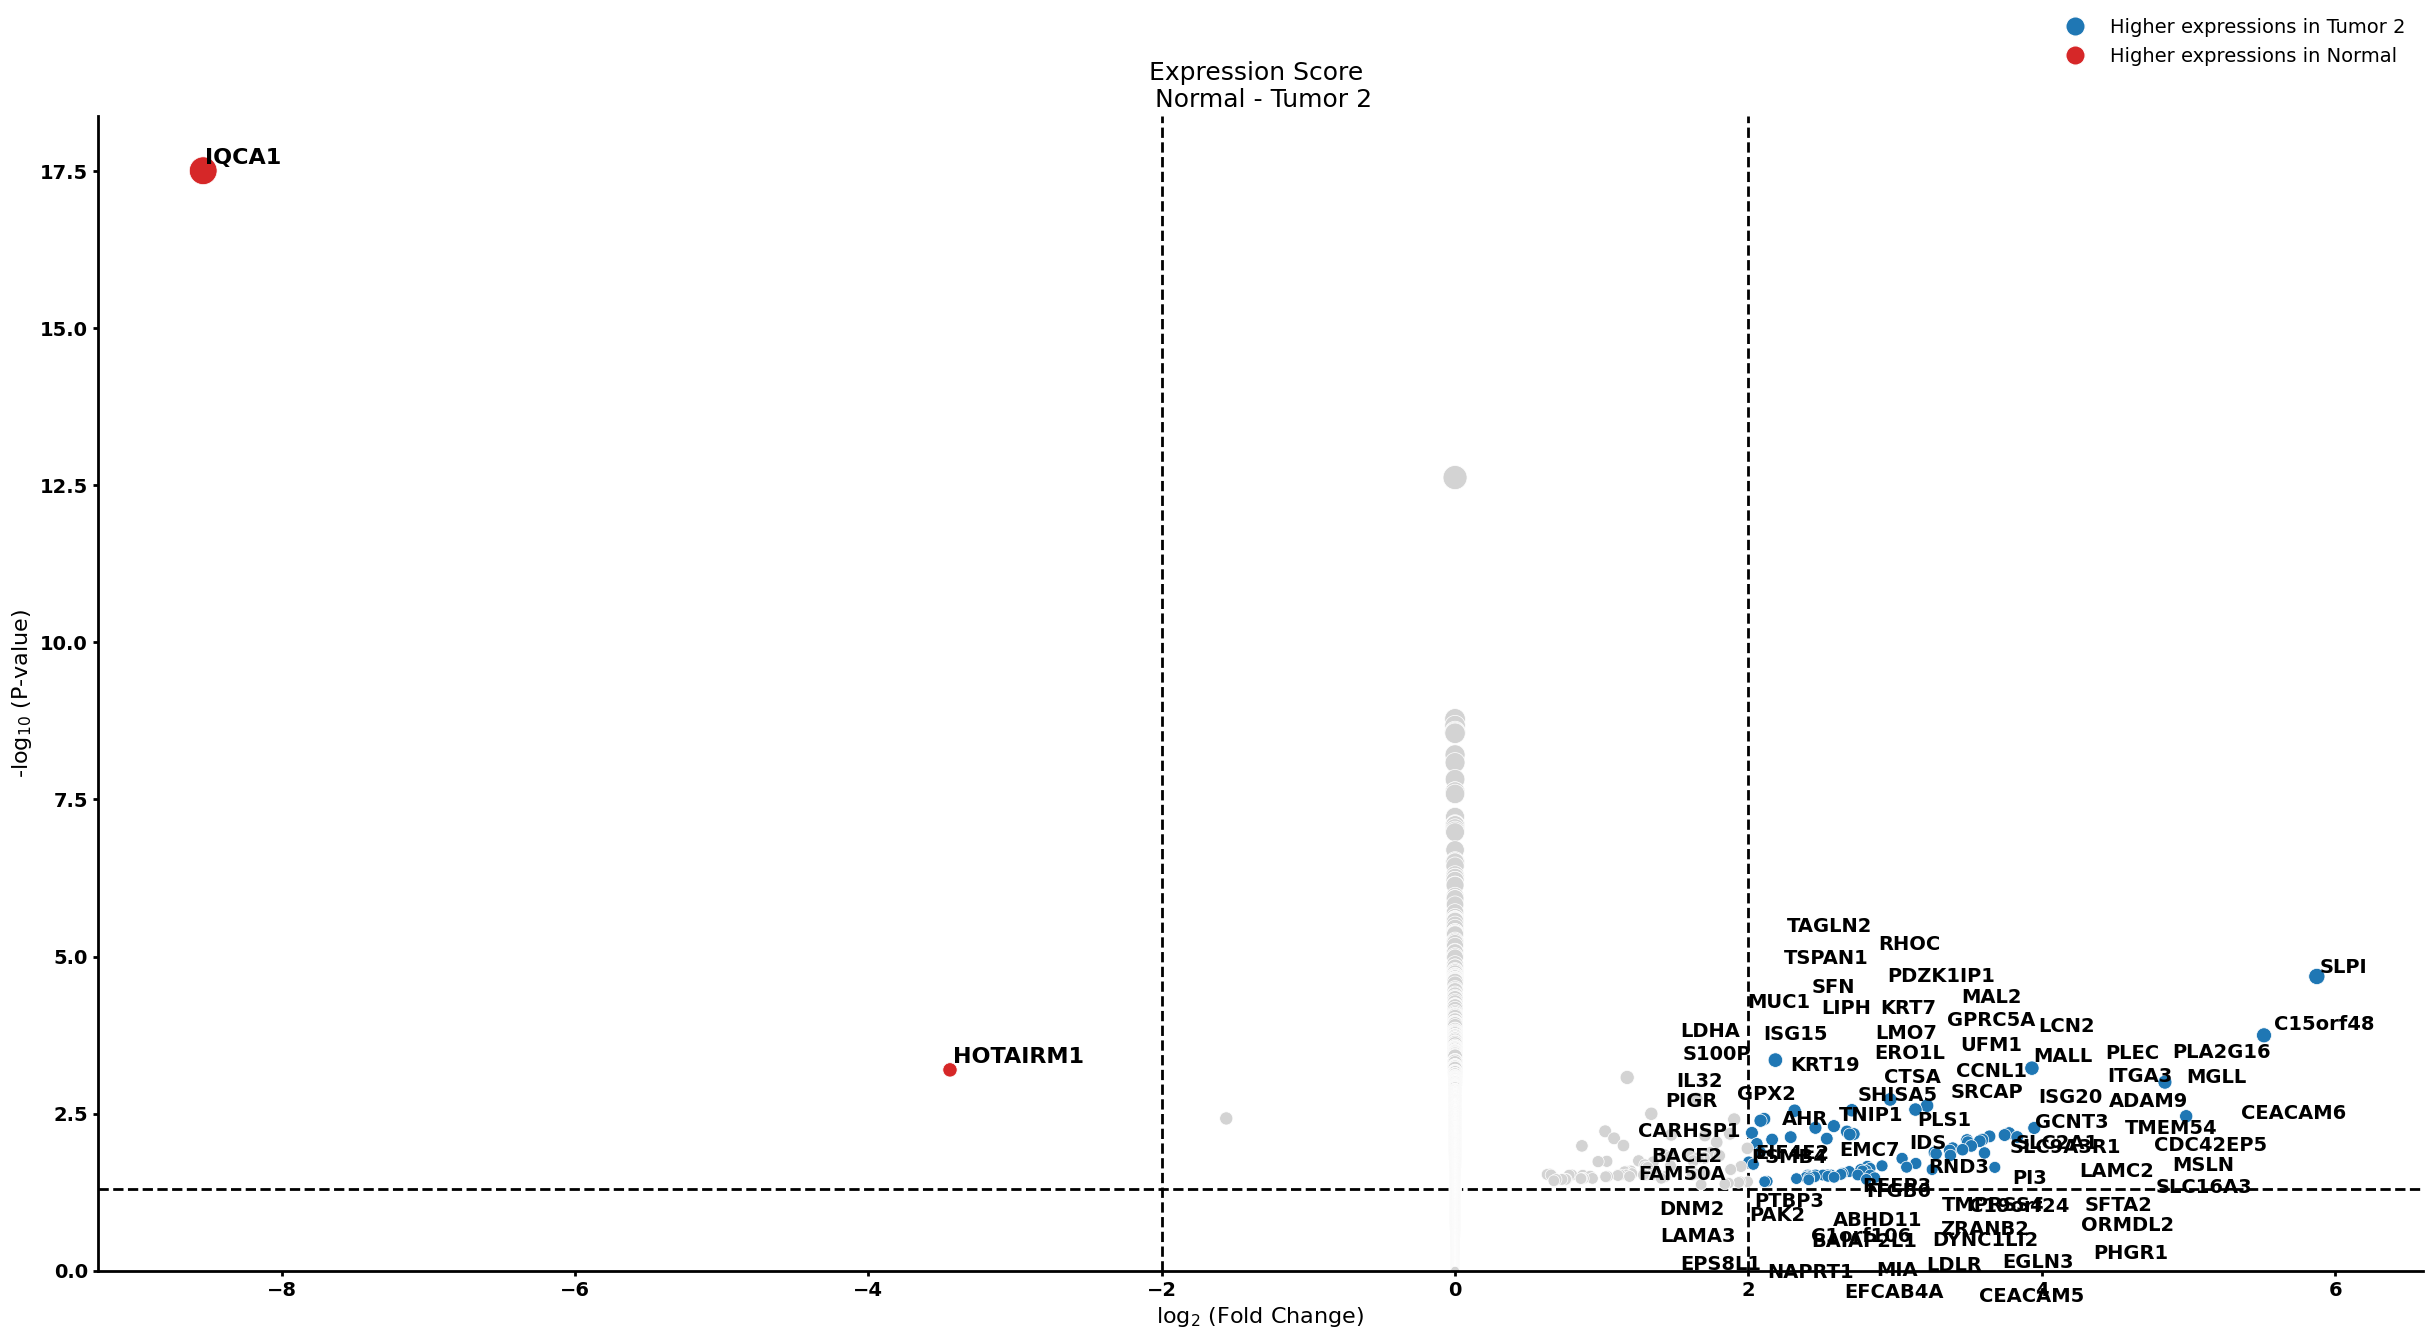

Plot GO analysis for Tumor 2 vs Normal


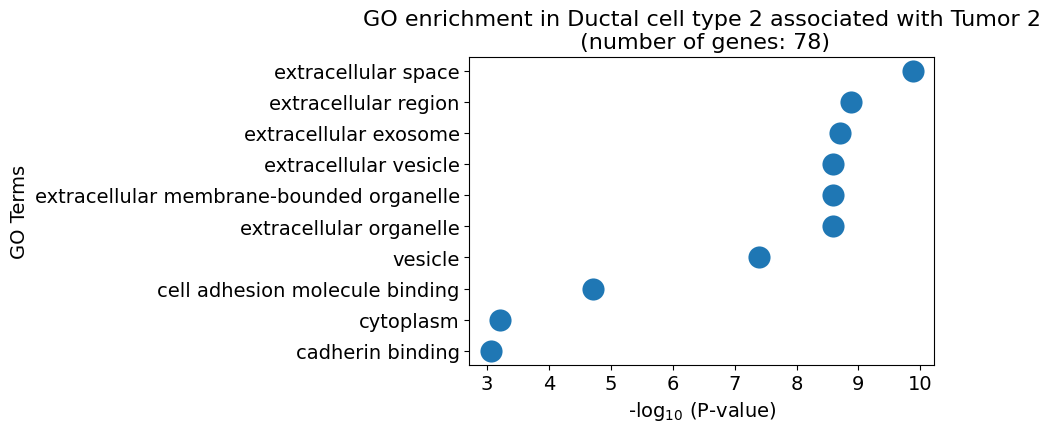

Plot volcano plot for Tumor 2 vs Tumor 1


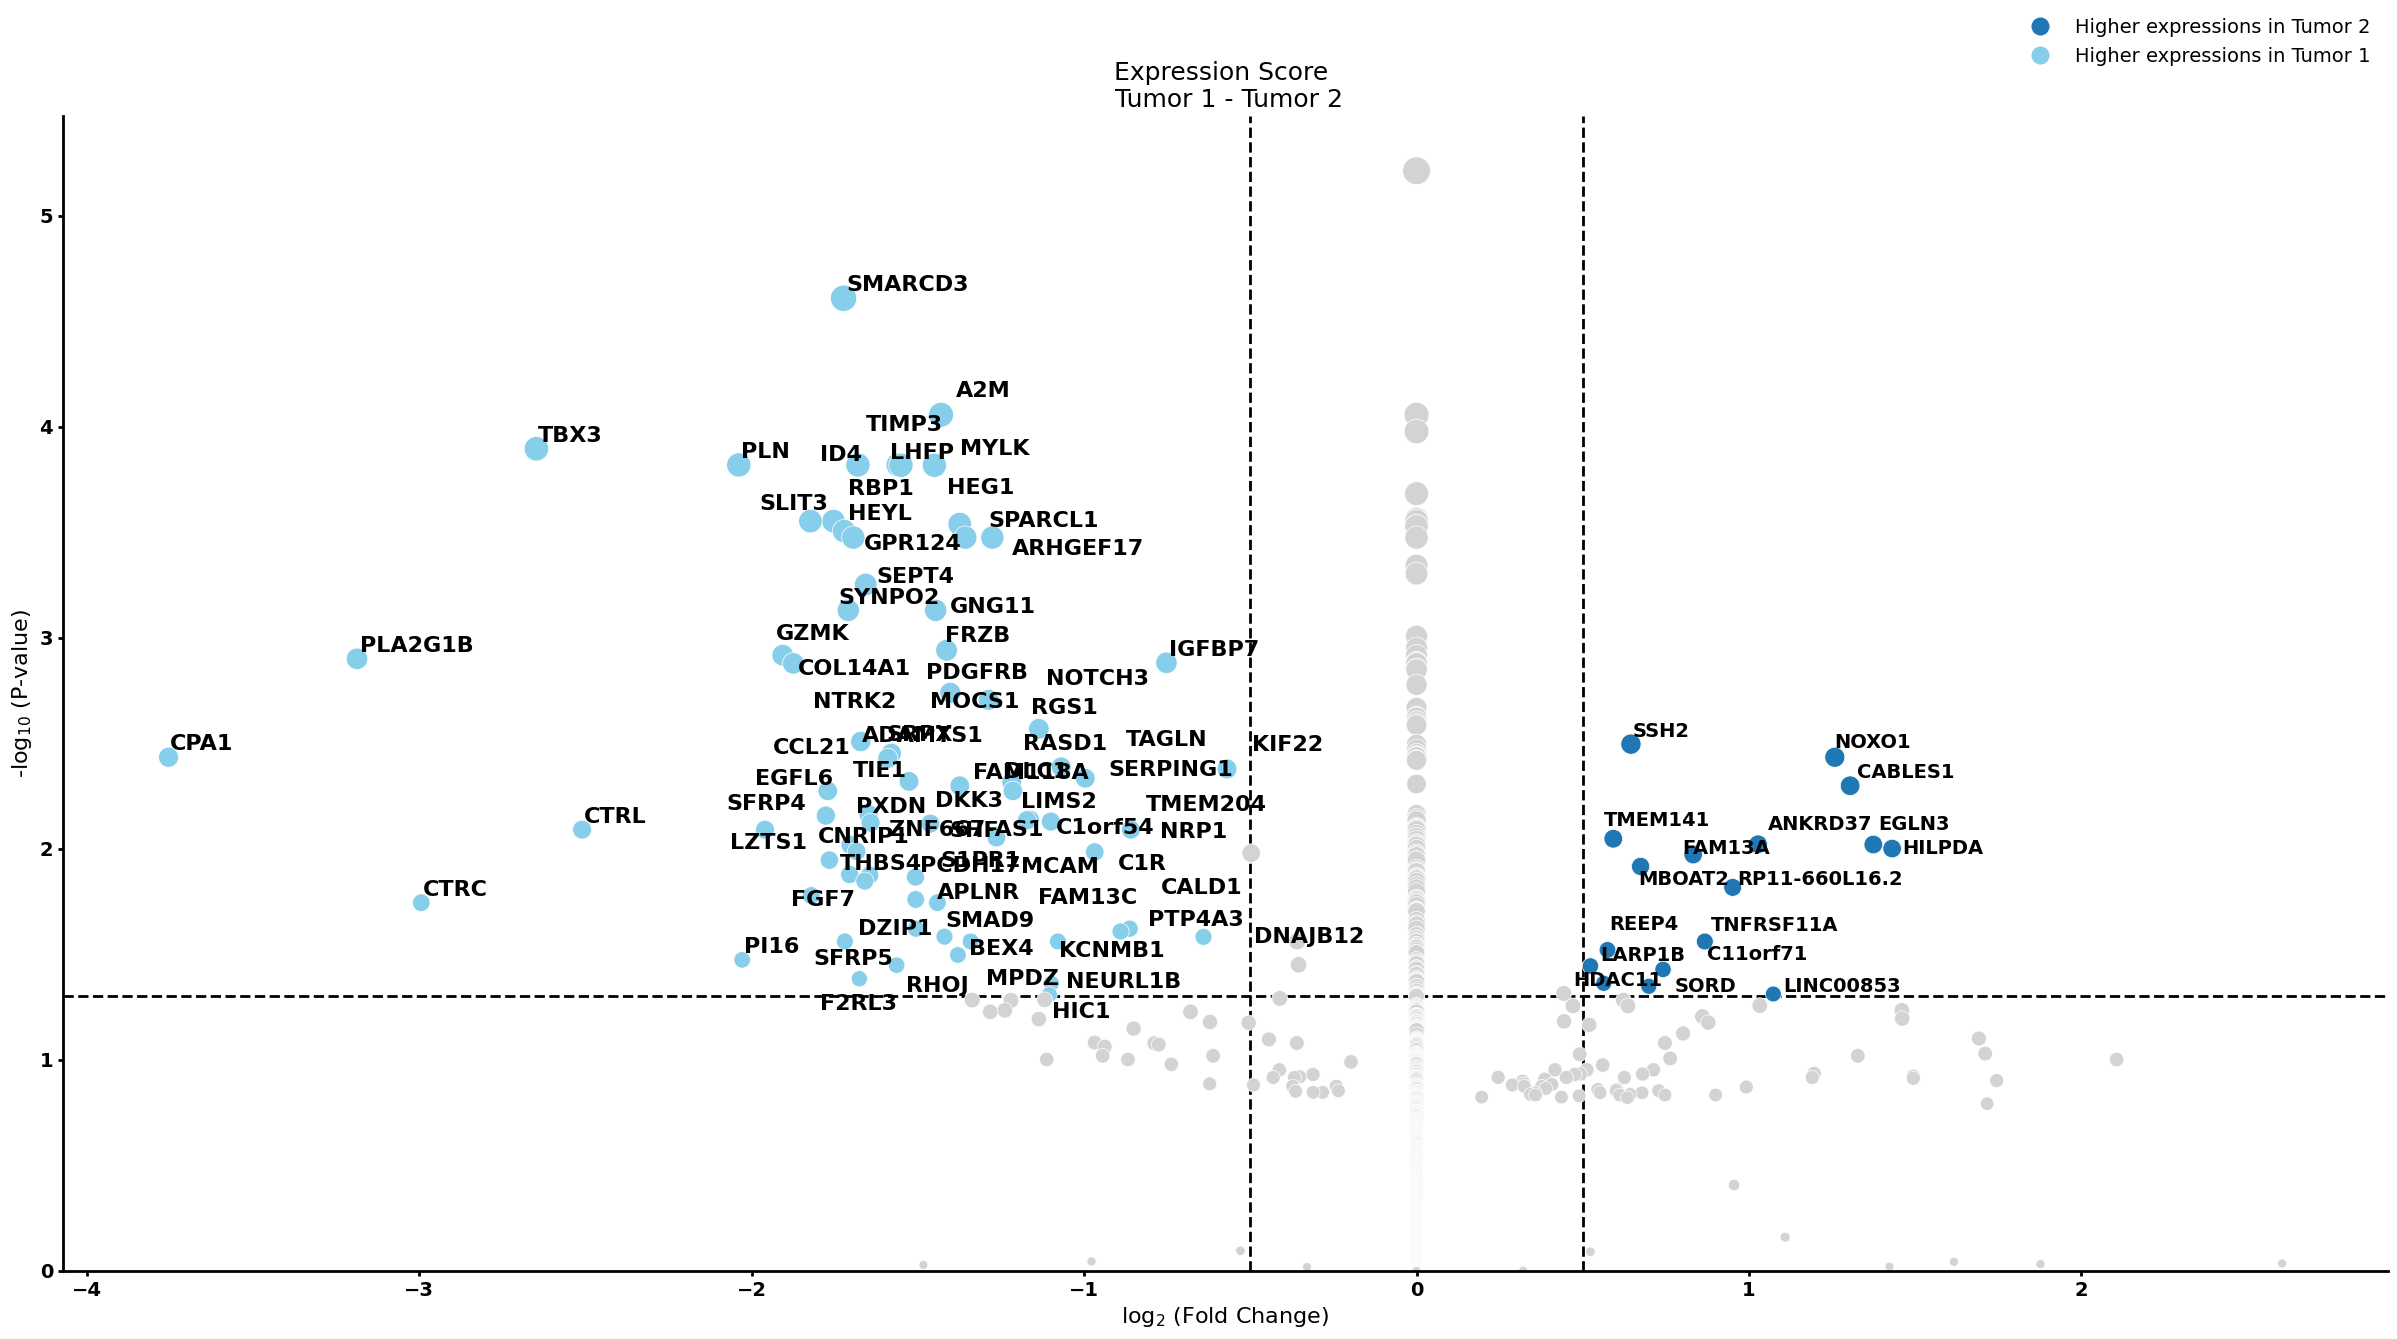

Plot GO analysis for Tumor 2 vs Tumor 1


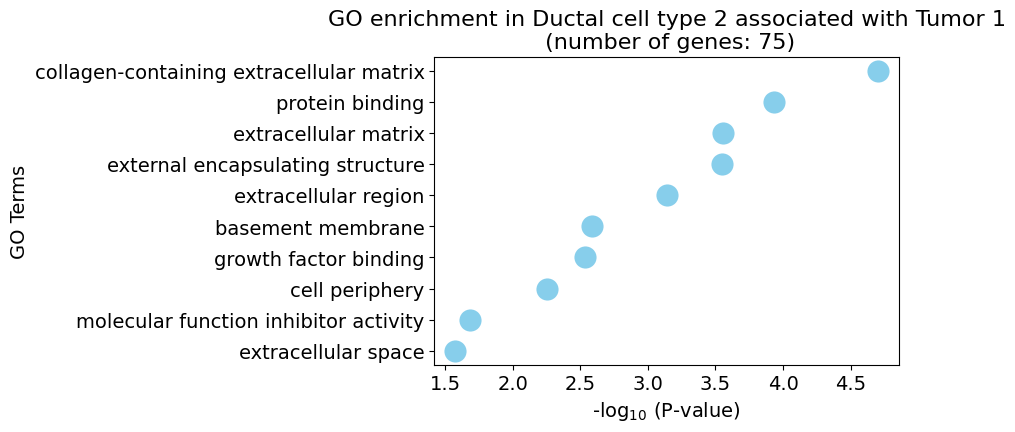

In [13]:
pl.pl.get_pseudobulk_DE(adata, proportion_df, cell_type = 'Ductal cell type 2', fc_thr = [2.0, 2.0, 0.5])